In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import mat73
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from GLM_regression import *
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

C:\Users\Msfin\AppData\Local\Temp\ipykernel_23084\3859726068.py:195: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


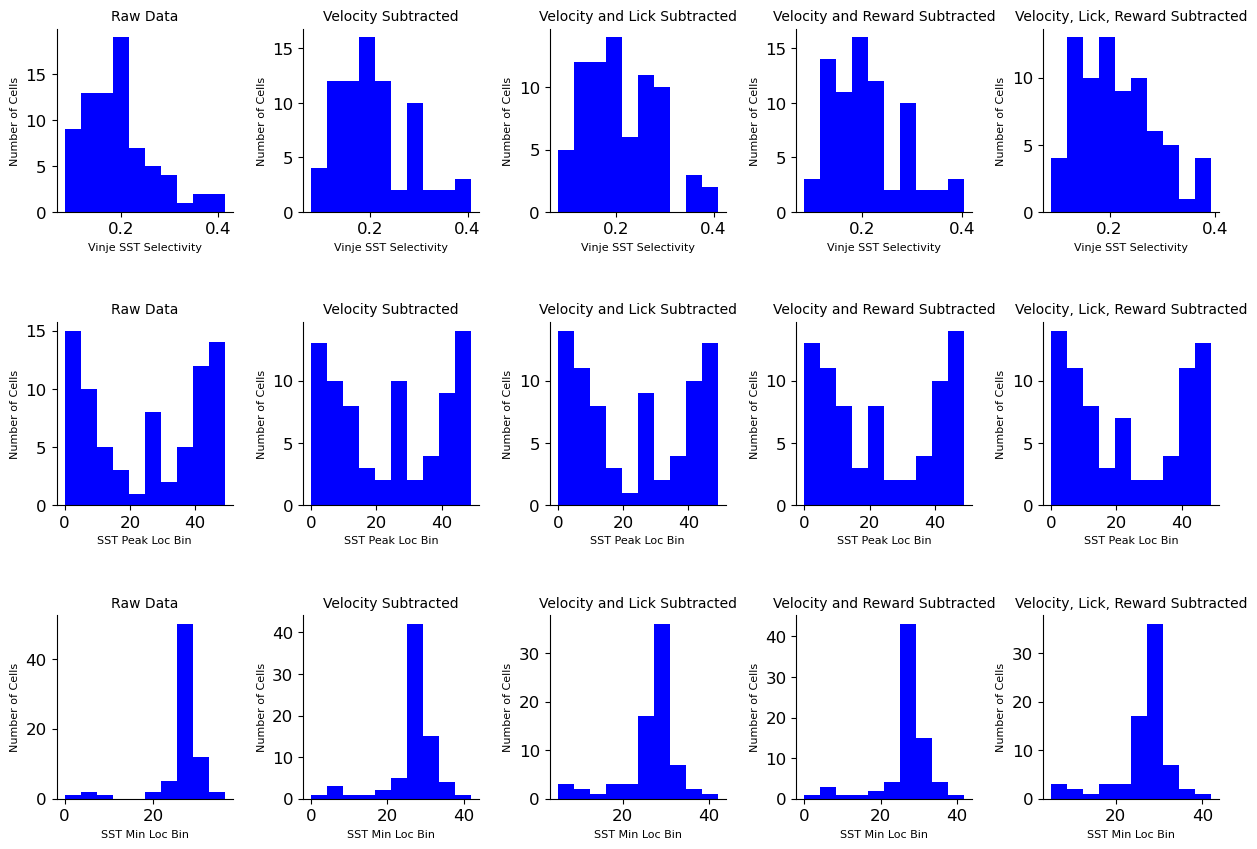

In [3]:
datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "SSTindivsomata_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

#variable_list ['Activity'=0, 'Licks'=1, 'Reward_loc'=2, 'Velocity'=3, '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']

variables_to_remove = ["Velocity"]

avg_residuals, GLM_params, residual_activity_velocity_SST = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_SST_velocity, argmin_list_SST_velocity, selectivity_SST_velocity = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
                                                       

# selectivity_list_SST_velocity = []

# for cell in avg_residuals_SST_velocity:
#     selectivity_list_SST_velocity.append(Vinje2000(cell, norm='min_max'))

    
    
    
variables_to_remove = ["Velocity", "Licks"]


avg_residuals, GLM_params, residual_activity_vl_SST = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_SST_vl, argmin_list_SST_vl, selectivity_SST_vl = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
          



# avg_residuals_SST_vl, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# #normalized_SST_residuals_vl = normalize(avg_residuals_SST_vl, 'min_max')                                                        


# selectivity_list_SST_vl = []

# for cell in avg_residuals_SST_vl:
#     selectivity_list_SST_vl.append(Vinje2000(cell, norm='min_max'))
    
    

    
variables_to_remove = ["Velocity", "Reward_loc"]

# avg_residuals_SST_vr, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# # normalized_SST_residuals_vr = normalize(avg_residuals_SST, 'min_max')                                                        


# selectivity_list_SST_vr = []

# for cell in avg_residuals_SST_vr:
#     selectivity_list_SST_vr.append(Vinje2000(cell, norm='min_max'))



avg_residuals, GLM_params, residual_activity_vr_SST = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_SST_vr, argmin_list_SST_vr, selectivity_SST_vr = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
  
    
    
variables_to_remove = ["Velocity", "Reward_loc", "Licks"]

# avg_residuals_SST_vr, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# # normalized_SST_residuals_vr = normalize(avg_residuals_SST, 'min_max')                                                        


# selectivity_list_SST_vr = []

# for cell in avg_residuals_SST_vr:
#     selectivity_list_SST_vr.append(Vinje2000(cell, norm='min_max'))



avg_residuals, GLM_params, residual_activity_vrl_SST = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_SST_vrl, argmin_list_SST_vrl, selectivity_SST_vrl = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
  
    
    
    
Argmax_list_raw_SST = []
Argmin_list_raw_SST = []
selectivity_list_SST_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        neuron_activity_trial_averaged = np.mean(neuron_activity, axis=1)
        selectivity_list_SST_raw.append(neuron_activity_trial_averaged)

        
        
SST_raw_selectivity = []

selectivity_matrix_SST_raw = np.vstack(selectivity_list_SST_raw)

for cell in selectivity_matrix_SST_raw:
    SST_raw_selectivity.append(Vinje2000(cell, norm='min_max'))
    Argmax_list_raw_SST.append(np.argmax(cell))
    Argmin_list_raw_SST.append(np.argmin(cell))

    
    
   
fig, axs = plt.subplots(3,5, figsize=(15, 10))

fig.subplots_adjust(wspace=0.4, hspace=0.6)

axs[0, 0].hist(SST_raw_selectivity, bins=10, color='blue')
axs[0, 0].set_title("Raw Data", fontsize=10)
axs[0, 0].set_ylabel("Number of Cells", fontsize=8)
axs[0, 0].set_xlabel("Vinje SST Selectivity", fontsize=8)

axs[0, 1].hist(selectivity_SST_velocity, bins=10, color='blue')
axs[0, 1].set_title("Velocity Subtracted", fontsize=10)
axs[0, 1].set_ylabel("Number of Cells", fontsize=8)
axs[0, 1].set_xlabel("Vinje SST Selectivity", fontsize=8)

axs[0, 2].hist(selectivity_SST_vl, bins=10, color='blue')
axs[0, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[0, 2].set_ylabel("Number of Cells", fontsize=8)
axs[0, 2].set_xlabel("Vinje SST Selectivity", fontsize=8)

axs[0, 3].hist(selectivity_SST_vr, bins=10, color='blue')
axs[0, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[0, 3].set_ylabel("Number of Cells", fontsize=8)
axs[0, 3].set_xlabel("Vinje SST Selectivity", fontsize=8)

axs[0, 4].hist(selectivity_SST_vrl, bins=10, color='blue')
axs[0, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[0, 4].set_ylabel("Number of Cells", fontsize=8)
axs[0, 4].set_xlabel("Vinje SST Selectivity", fontsize=8)

axs[1, 0].hist(Argmax_list_raw_SST, bins=10, color='blue')
axs[1, 0].set_title("Raw Data", fontsize=10)
axs[1, 0].set_ylabel("Number of Cells", fontsize=8)
axs[1, 0].set_xlabel("SST Peak Loc Bin", fontsize=8)

axs[1, 1].hist(argmax_list_SST_velocity, bins=10, color='blue')
axs[1, 1].set_title("Velocity Subtracted", fontsize=10)
axs[1, 1].set_ylabel("Number of Cells", fontsize=8)
axs[1, 1].set_xlabel("SST Peak Loc Bin", fontsize=8)

axs[1, 2].hist(argmax_list_SST_vl, bins=10, color='blue')
axs[1, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[1, 2].set_ylabel("Number of Cells", fontsize=8)
axs[1, 2].set_xlabel("SST Peak Loc Bin", fontsize=8)

axs[1, 3].hist(argmax_list_SST_vr, bins=10, color='blue')
axs[1, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[1, 3].set_ylabel("Number of Cells", fontsize=8)
axs[1, 3].set_xlabel("SST Peak Loc Bin", fontsize=8)


axs[1, 4].hist(argmax_list_SST_vrl, bins=10, color='blue')
axs[1, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[1, 4].set_ylabel("Number of Cells", fontsize=8)
axs[1, 4].set_xlabel("SST Peak Loc Bin", fontsize=8)


axs[2, 0].hist(Argmin_list_raw_SST, bins=10, color='blue')
axs[2, 0].set_title("Raw Data", fontsize=10)
axs[2, 0].set_ylabel("Number of Cells", fontsize=8)
axs[2, 0].set_xlabel("SST Min Loc Bin", fontsize=8)

axs[2, 1].hist(argmin_list_SST_velocity, bins=10, color='blue')
axs[2, 1].set_title("Velocity Subtracted", fontsize=10)
axs[2, 1].set_ylabel("Number of Cells", fontsize=8)
axs[2, 1].set_xlabel("SST Min Loc Bin", fontsize=8)

axs[2, 2].hist(argmin_list_SST_vl, bins=10, color='blue')
axs[2, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[2, 2].set_ylabel("Number of Cells", fontsize=8)
axs[2, 2].set_xlabel("SST Min Loc Bin", fontsize=8)

axs[2, 3].hist(argmin_list_SST_vr, bins=10, color='blue')
axs[2, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[2, 3].set_ylabel("Number of Cells", fontsize=8)
axs[2, 3].set_xlabel("SST Min Loc Bin", fontsize=8)

axs[2, 4].hist(argmin_list_SST_vrl, bins=10, color='blue')
axs[2, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[2, 4].set_ylabel("Number of Cells", fontsize=8)
axs[2, 4].set_xlabel("SST Min Loc Bin", fontsize=8)









fig.show()

C:\Users\Msfin\AppData\Local\Temp\ipykernel_23084\886218139.py:195: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


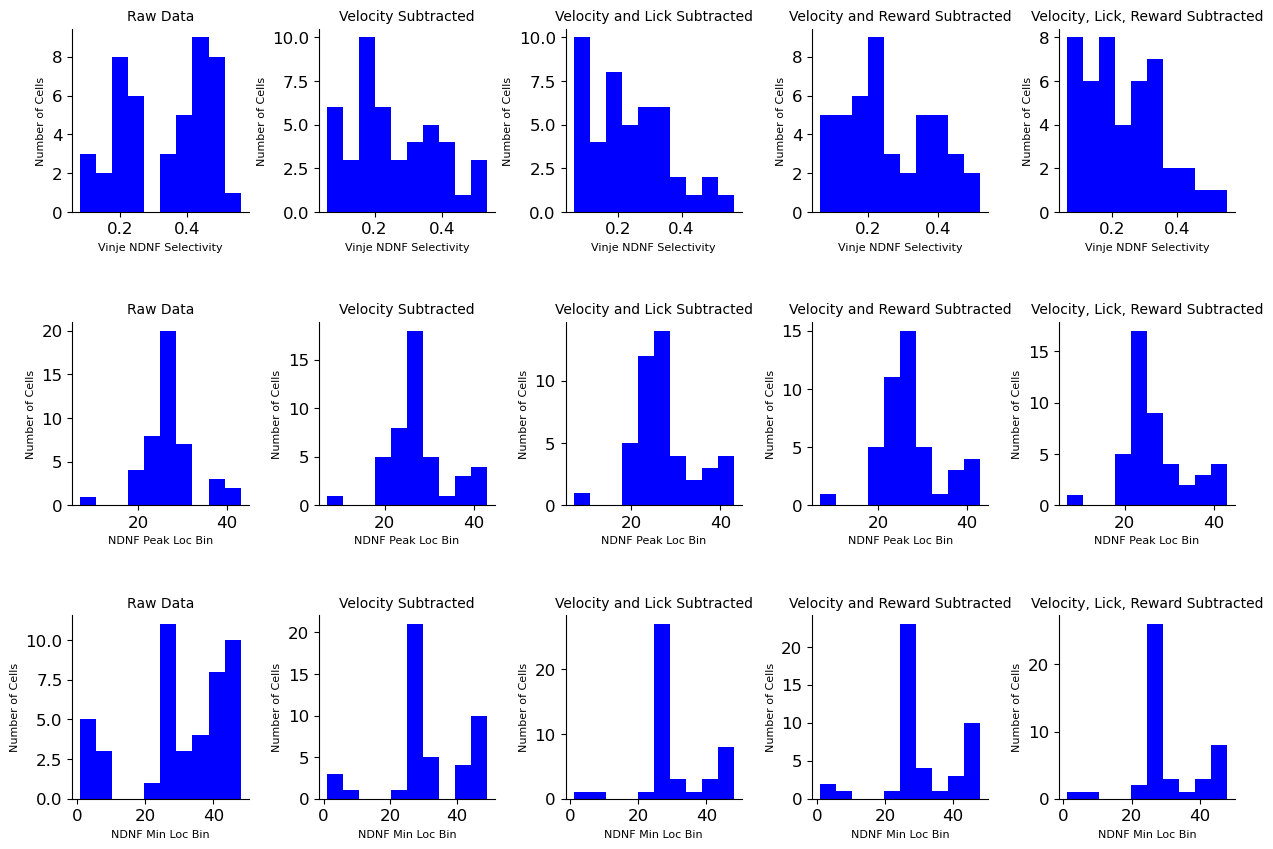

In [4]:
datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "NDNFindivsomata_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

#variable_list ['Activity'=0, 'Licks'=1, 'Reward_loc'=2, 'Velocity'=3, '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']

variables_to_remove = ["Velocity"]

avg_residuals, GLM_params, residual_activity_velocity_NDNF = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_NDNF_velocity, argmin_list_NDNF_velocity, selectivity_NDNF_velocity = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
                                                       

# selectivity_list_NDNF_velocity = []

# for cell in avg_residuals_NDNF_velocity:
#     selectivity_list_NDNF_velocity.append(Vinje2000(cell, norm='min_max'))

    
    
    
variables_to_remove = ["Velocity", "Licks"]


avg_residuals, GLM_params, residual_activity_vl_NDNF = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_NDNF_vl, argmin_list_NDNF_vl, selectivity_NDNF_vl = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
          



# avg_residuals_NDNF_vl, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# #normalized_NDNF_residuals_vl = normalize(avg_residuals_NDNF_vl, 'min_max')                                                        


# selectivity_list_NDNF_vl = []

# for cell in avg_residuals_NDNF_vl:
#     selectivity_list_NDNF_vl.append(Vinje2000(cell, norm='min_max'))
    
    

    
variables_to_remove = ["Velocity", "Reward_loc"]

# avg_residuals_NDNF_vr, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# # normalized_NDNF_residuals_vr = normalize(avg_residuals_NDNF, 'min_max')                                                        


# selectivity_list_NDNF_vr = []

# for cell in avg_residuals_NDNF_vr:
#     selectivity_list_NDNF_vr.append(Vinje2000(cell, norm='min_max'))



avg_residuals, GLM_params, residual_activity_vr_NDNF = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_NDNF_vr, argmin_list_NDNF_vr, selectivity_NDNF_vr = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
  
    
    
variables_to_remove = ["Velocity", "Reward_loc", "Licks"]

# avg_residuals_NDNF_vr, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# # normalized_NDNF_residuals_vr = normalize(avg_residuals_NDNF, 'min_max')                                                        


# selectivity_list_NDNF_vr = []

# for cell in avg_residuals_NDNF_vr:
#     selectivity_list_NDNF_vr.append(Vinje2000(cell, norm='min_max'))



avg_residuals, GLM_params, residual_activity_vrl_NDNF = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_NDNF_vrl, argmin_list_NDNF_vrl, selectivity_NDNF_vrl = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
  
    
    
    
Argmax_list_raw_NDNF = []
Argmin_list_raw_NDNF = []
selectivity_list_NDNF_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        neuron_activity_trial_averaged = np.mean(neuron_activity, axis=1)
        selectivity_list_NDNF_raw.append(neuron_activity_trial_averaged)

        
        
NDNF_raw_selectivity = []

selectivity_matrix_NDNF_raw = np.vstack(selectivity_list_NDNF_raw)

for cell in selectivity_matrix_NDNF_raw:
    NDNF_raw_selectivity.append(Vinje2000(cell, norm='min_max'))
    Argmax_list_raw_NDNF.append(np.argmax(cell))
    Argmin_list_raw_NDNF.append(np.argmin(cell))

    
    
   
fig, axs = plt.subplots(3,5, figsize=(15, 10))

fig.subplots_adjust(wspace=0.4, hspace=0.6)

axs[0, 0].hist(NDNF_raw_selectivity, bins=10, color='blue')
axs[0, 0].set_title("Raw Data", fontsize=10)
axs[0, 0].set_ylabel("Number of Cells", fontsize=8)
axs[0, 0].set_xlabel("Vinje NDNF Selectivity", fontsize=8)

axs[0, 1].hist(selectivity_NDNF_velocity, bins=10, color='blue')
axs[0, 1].set_title("Velocity Subtracted", fontsize=10)
axs[0, 1].set_ylabel("Number of Cells", fontsize=8)
axs[0, 1].set_xlabel("Vinje NDNF Selectivity", fontsize=8)

axs[0, 2].hist(selectivity_NDNF_vl, bins=10, color='blue')
axs[0, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[0, 2].set_ylabel("Number of Cells", fontsize=8)
axs[0, 2].set_xlabel("Vinje NDNF Selectivity", fontsize=8)

axs[0, 3].hist(selectivity_NDNF_vr, bins=10, color='blue')
axs[0, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[0, 3].set_ylabel("Number of Cells", fontsize=8)
axs[0, 3].set_xlabel("Vinje NDNF Selectivity", fontsize=8)

axs[0, 4].hist(selectivity_NDNF_vrl, bins=10, color='blue')
axs[0, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[0, 4].set_ylabel("Number of Cells", fontsize=8)
axs[0, 4].set_xlabel("Vinje NDNF Selectivity", fontsize=8)

axs[1, 0].hist(Argmax_list_raw_NDNF, bins=10, color='blue')
axs[1, 0].set_title("Raw Data", fontsize=10)
axs[1, 0].set_ylabel("Number of Cells", fontsize=8)
axs[1, 0].set_xlabel("NDNF Peak Loc Bin", fontsize=8)

axs[1, 1].hist(argmax_list_NDNF_velocity, bins=10, color='blue')
axs[1, 1].set_title("Velocity Subtracted", fontsize=10)
axs[1, 1].set_ylabel("Number of Cells", fontsize=8)
axs[1, 1].set_xlabel("NDNF Peak Loc Bin", fontsize=8)

axs[1, 2].hist(argmax_list_NDNF_vl, bins=10, color='blue')
axs[1, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[1, 2].set_ylabel("Number of Cells", fontsize=8)
axs[1, 2].set_xlabel("NDNF Peak Loc Bin", fontsize=8)

axs[1, 3].hist(argmax_list_NDNF_vr, bins=10, color='blue')
axs[1, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[1, 3].set_ylabel("Number of Cells", fontsize=8)
axs[1, 3].set_xlabel("NDNF Peak Loc Bin", fontsize=8)


axs[1, 4].hist(argmax_list_NDNF_vrl, bins=10, color='blue')
axs[1, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[1, 4].set_ylabel("Number of Cells", fontsize=8)
axs[1, 4].set_xlabel("NDNF Peak Loc Bin", fontsize=8)


axs[2, 0].hist(Argmin_list_raw_NDNF, bins=10, color='blue')
axs[2, 0].set_title("Raw Data", fontsize=10)
axs[2, 0].set_ylabel("Number of Cells", fontsize=8)
axs[2, 0].set_xlabel("NDNF Min Loc Bin", fontsize=8)

axs[2, 1].hist(argmin_list_NDNF_velocity, bins=10, color='blue')
axs[2, 1].set_title("Velocity Subtracted", fontsize=10)
axs[2, 1].set_ylabel("Number of Cells", fontsize=8)
axs[2, 1].set_xlabel("NDNF Min Loc Bin", fontsize=8)

axs[2, 2].hist(argmin_list_NDNF_vl, bins=10, color='blue')
axs[2, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[2, 2].set_ylabel("Number of Cells", fontsize=8)
axs[2, 2].set_xlabel("NDNF Min Loc Bin", fontsize=8)

axs[2, 3].hist(argmin_list_NDNF_vr, bins=10, color='blue')
axs[2, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[2, 3].set_ylabel("Number of Cells", fontsize=8)
axs[2, 3].set_xlabel("NDNF Min Loc Bin", fontsize=8)

axs[2, 4].hist(argmin_list_NDNF_vrl, bins=10, color='blue')
axs[2, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[2, 4].set_ylabel("Number of Cells", fontsize=8)
axs[2, 4].set_xlabel("NDNF Min Loc Bin", fontsize=8)









fig.show()

C:\Users\Msfin\AppData\Local\Temp\ipykernel_23084\4260557481.py:195: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


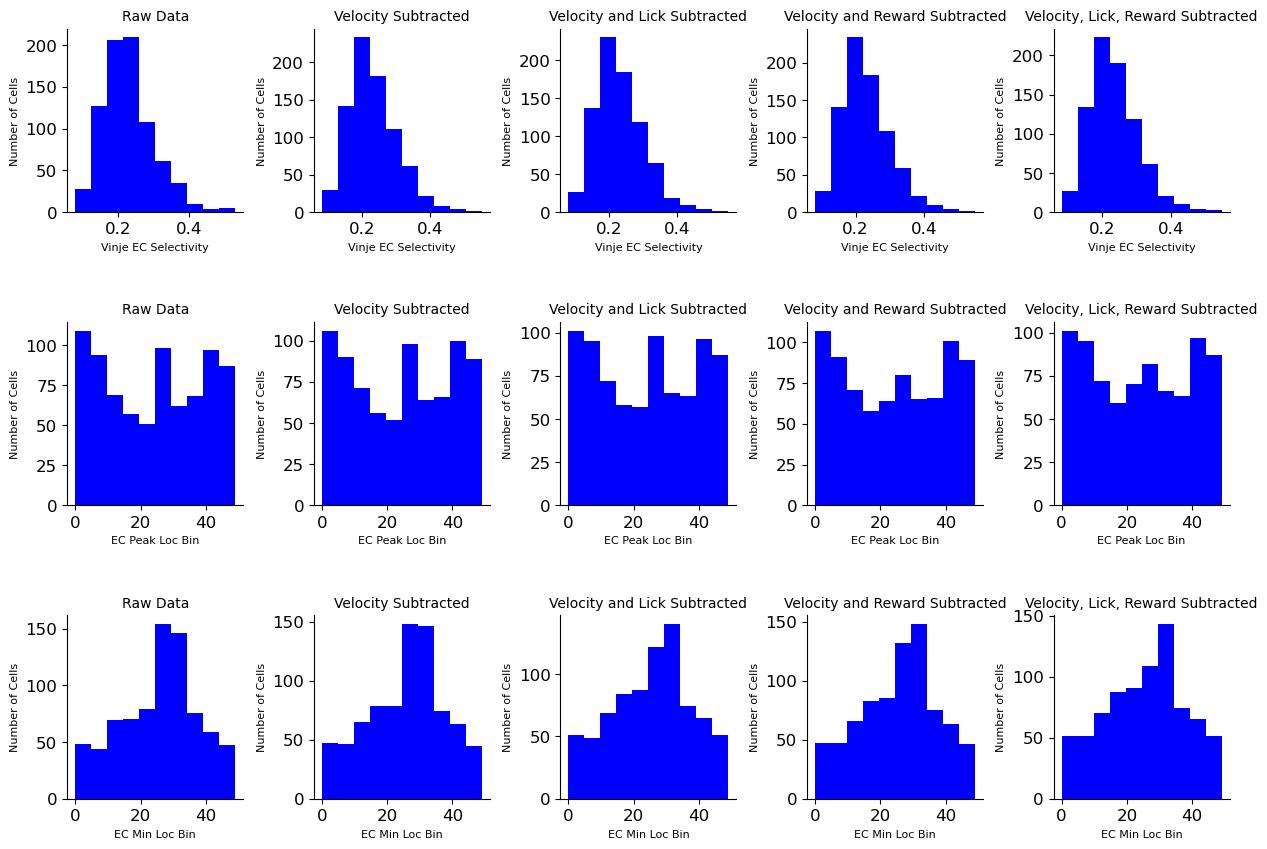

In [6]:
datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "EC_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

#variable_list ['Activity'=0, 'Licks'=1, 'Reward_loc'=2, 'Velocity'=3, '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']

variables_to_remove = ["Velocity"]

avg_residuals, GLM_params, residual_activity_velocity_EC = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_EC_velocity, argmin_list_EC_velocity, selectivity_EC_velocity = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
                                                       

# selectivity_list_EC_velocity = []

# for cell in avg_residuals_EC_velocity:
#     selectivity_list_EC_velocity.append(Vinje2000(cell, norm='min_max'))

    
    
    
variables_to_remove = ["Velocity", "Licks"]


avg_residuals, GLM_params, residual_activity_vl_EC = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_EC_vl, argmin_list_EC_vl, selectivity_EC_vl = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
          



# avg_residuals_EC_vl, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# #normalized_EC_residuals_vl = normalize(avg_residuals_EC_vl, 'min_max')                                                        


# selectivity_list_EC_vl = []

# for cell in avg_residuals_EC_vl:
#     selectivity_list_EC_vl.append(Vinje2000(cell, norm='min_max'))
    
    

    
variables_to_remove = ["Velocity", "Reward_loc"]

# avg_residuals_EC_vr, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# # normalized_EC_residuals_vr = normalize(avg_residuals_EC, 'min_max')                                                        


# selectivity_list_EC_vr = []

# for cell in avg_residuals_EC_vr:
#     selectivity_list_EC_vr.append(Vinje2000(cell, norm='min_max'))



avg_residuals, GLM_params, residual_activity_vr_EC = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_EC_vr, argmin_list_EC_vr, selectivity_EC_vr = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
  
    
    
variables_to_remove = ["Velocity", "Reward_loc", "Licks"]

# avg_residuals_EC_vr, GLM_params = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
# # normalized_EC_residuals_vr = normalize(avg_residuals_EC, 'min_max')                                                        


# selectivity_list_EC_vr = []

# for cell in avg_residuals_EC_vr:
#     selectivity_list_EC_vr.append(Vinje2000(cell, norm='min_max'))



avg_residuals, GLM_params, residual_activity_vrl_EC = compute_variable_subtracted_residuals(reorganized_data, variable_list, variables_to_remove, quintile=None)
avg_residuals_min_max, argmax_list_EC_vrl, argmin_list_EC_vrl, selectivity_EC_vrl = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals)
  
    
    
    
Argmax_list_raw_EC = []
Argmin_list_raw_EC = []
selectivity_list_EC_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        neuron_activity_trial_averaged = np.mean(neuron_activity, axis=1)
        selectivity_list_EC_raw.append(neuron_activity_trial_averaged)

        
        
EC_raw_selectivity = []

selectivity_matrix_EC_raw = np.vstack(selectivity_list_EC_raw)

for cell in selectivity_matrix_EC_raw:
    EC_raw_selectivity.append(Vinje2000(cell, norm='min_max'))
    Argmax_list_raw_EC.append(np.argmax(cell))
    Argmin_list_raw_EC.append(np.argmin(cell))

    
    
   
fig, axs = plt.subplots(3,5, figsize=(15, 10))

fig.subplots_adjust(wspace=0.4, hspace=0.6)

axs[0, 0].hist(EC_raw_selectivity, bins=10, color='blue')
axs[0, 0].set_title("Raw Data", fontsize=10)
axs[0, 0].set_ylabel("Number of Cells", fontsize=8)
axs[0, 0].set_xlabel("Vinje EC Selectivity", fontsize=8)

axs[0, 1].hist(selectivity_EC_velocity, bins=10, color='blue')
axs[0, 1].set_title("Velocity Subtracted", fontsize=10)
axs[0, 1].set_ylabel("Number of Cells", fontsize=8)
axs[0, 1].set_xlabel("Vinje EC Selectivity", fontsize=8)

axs[0, 2].hist(selectivity_EC_vl, bins=10, color='blue')
axs[0, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[0, 2].set_ylabel("Number of Cells", fontsize=8)
axs[0, 2].set_xlabel("Vinje EC Selectivity", fontsize=8)

axs[0, 3].hist(selectivity_EC_vr, bins=10, color='blue')
axs[0, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[0, 3].set_ylabel("Number of Cells", fontsize=8)
axs[0, 3].set_xlabel("Vinje EC Selectivity", fontsize=8)

axs[0, 4].hist(selectivity_EC_vrl, bins=10, color='blue')
axs[0, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[0, 4].set_ylabel("Number of Cells", fontsize=8)
axs[0, 4].set_xlabel("Vinje EC Selectivity", fontsize=8)

axs[1, 0].hist(Argmax_list_raw_EC, bins=10, color='blue')
axs[1, 0].set_title("Raw Data", fontsize=10)
axs[1, 0].set_ylabel("Number of Cells", fontsize=8)
axs[1, 0].set_xlabel("EC Peak Loc Bin", fontsize=8)

axs[1, 1].hist(argmax_list_EC_velocity, bins=10, color='blue')
axs[1, 1].set_title("Velocity Subtracted", fontsize=10)
axs[1, 1].set_ylabel("Number of Cells", fontsize=8)
axs[1, 1].set_xlabel("EC Peak Loc Bin", fontsize=8)

axs[1, 2].hist(argmax_list_EC_vl, bins=10, color='blue')
axs[1, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[1, 2].set_ylabel("Number of Cells", fontsize=8)
axs[1, 2].set_xlabel("EC Peak Loc Bin", fontsize=8)

axs[1, 3].hist(argmax_list_EC_vr, bins=10, color='blue')
axs[1, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[1, 3].set_ylabel("Number of Cells", fontsize=8)
axs[1, 3].set_xlabel("EC Peak Loc Bin", fontsize=8)


axs[1, 4].hist(argmax_list_EC_vrl, bins=10, color='blue')
axs[1, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[1, 4].set_ylabel("Number of Cells", fontsize=8)
axs[1, 4].set_xlabel("EC Peak Loc Bin", fontsize=8)


axs[2, 0].hist(Argmin_list_raw_EC, bins=10, color='blue')
axs[2, 0].set_title("Raw Data", fontsize=10)
axs[2, 0].set_ylabel("Number of Cells", fontsize=8)
axs[2, 0].set_xlabel("EC Min Loc Bin", fontsize=8)

axs[2, 1].hist(argmin_list_EC_velocity, bins=10, color='blue')
axs[2, 1].set_title("Velocity Subtracted", fontsize=10)
axs[2, 1].set_ylabel("Number of Cells", fontsize=8)
axs[2, 1].set_xlabel("EC Min Loc Bin", fontsize=8)

axs[2, 2].hist(argmin_list_EC_vl, bins=10, color='blue')
axs[2, 2].set_title("Velocity and Lick Subtracted", fontsize=10)
axs[2, 2].set_ylabel("Number of Cells", fontsize=8)
axs[2, 2].set_xlabel("EC Min Loc Bin", fontsize=8)

axs[2, 3].hist(argmin_list_EC_vr, bins=10, color='blue')
axs[2, 3].set_title("Velocity and Reward Subtracted", fontsize=10)
axs[2, 3].set_ylabel("Number of Cells", fontsize=8)
axs[2, 3].set_xlabel("EC Min Loc Bin", fontsize=8)

axs[2, 4].hist(argmin_list_EC_vrl, bins=10, color='blue')
axs[2, 4].set_title("Velocity, Lick, Reward Subtracted", fontsize=10)
axs[2, 4].set_ylabel("Number of Cells", fontsize=8)
axs[2, 4].set_xlabel("EC Min Loc Bin", fontsize=8)









fig.show()

In [7]:
bin_size = 180/50
reward_loc = bin_size * 25

argmax_SST_dist_reward_raw = []
for i in Argmax_list_raw_SST:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmax_SST_dist_reward_raw.append(diff)
    
argmin_SST_dist_reward_raw = []
for i in Argmin_list_raw_SST:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmin_SST_dist_reward_raw.append(diff)

bin_size = 180/50
reward_loc = bin_size * 25

argmax_SST_dist_reward_velocity = []
for i in argmax_list_SST_velocity:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmax_SST_dist_reward_velocity.append(diff)
    
argmin_SST_dist_reward_velocity = []
for i in argmin_list_SST_velocity:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmin_SST_dist_reward_velocity.append(diff)

bin_size = 180/50
reward_loc = bin_size * 25

argmax_SST_dist_reward_vl = []
for i in argmax_list_SST_vl:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmax_SST_dist_reward_vl.append(diff)
    
argmin_SST_dist_reward_vl = []
for i in argmin_list_SST_vl:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmin_SST_dist_reward_vl.append(diff)

bin_size = 180/50
reward_loc = bin_size * 25

argmax_SST_dist_reward_vr = []
for i in argmax_list_SST_vr:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmax_SST_dist_reward_vr.append(diff)
    
argmin_SST_dist_reward_vr = []
for i in argmin_list_SST_vr:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmin_SST_dist_reward_vr.append(diff)
    
bin_size = 180/50
reward_loc = bin_size * 25

argmax_SST_dist_reward_vrl = []
for i in argmax_list_SST_vrl:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmax_SST_dist_reward_vrl.append(diff)
    
argmin_SST_dist_reward_vrl = []
for i in argmin_list_SST_vrl:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    argmin_SST_dist_reward_vrl.append(diff)

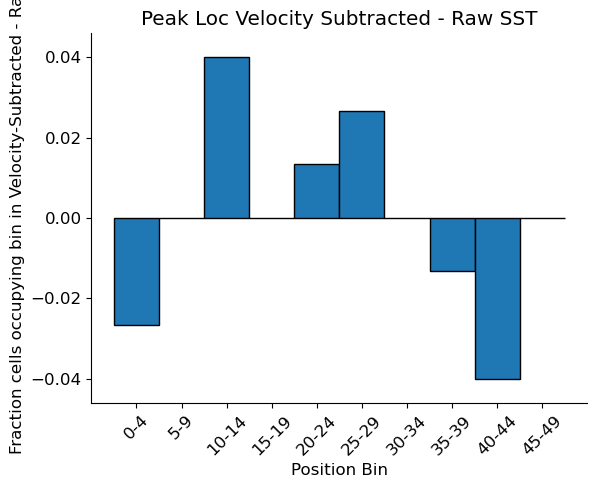

In [55]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_SST, bins=bin_edges)
velocity_hist, _ = np.histogram(argmax_list_SST_velocity, bins=bin_edges)

peak_loc_difference_learning = (velocity_hist - raw_hist)

peak_loc_difference_learning_list_SST_velocity = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_SST)
    peak_loc_difference_learning_list_SST_velocity.append(value)

y_min = np.min(peak_loc_difference_learning_list_SST_velocity)
y_max = np.max(peak_loc_difference_learning_list_SST_velocity)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_SST_velocity, width=5, align='center', edgecolor='k')
plt.title('Peak Loc Velocity Subtracted - Raw SST')
plt.ylabel('Fraction cells occupying bin in Velocity-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

In [65]:
import numpy as np
import matplotlib.pyplot as plt

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]


other_bins_fraction = (
    np.mean(
        [
            frac
            for i, frac in enumerate(peak_loc_difference_learning_list_SST_velocity)
            if i != specific_bin_index
        ]
    )
)

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, other_bins_fraction]
x_labels = ["Bin 25-29", "Average Other Bins"]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Comparison of In Reward Bin vs. Average Out of Reward Bin Peak SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()


NameError: name 'before_bin_index' is not defined

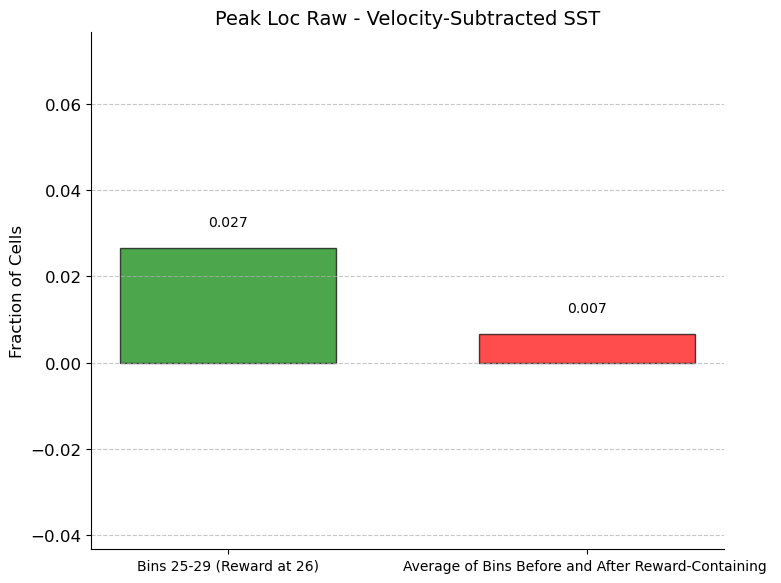

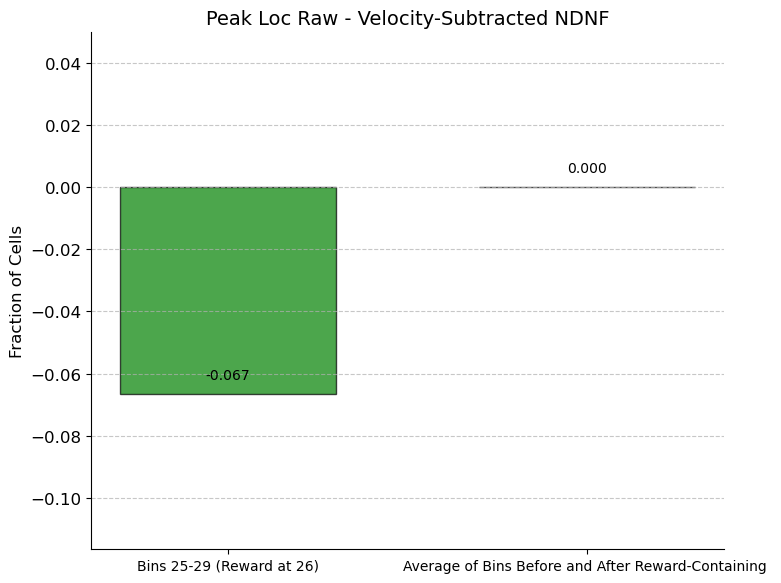

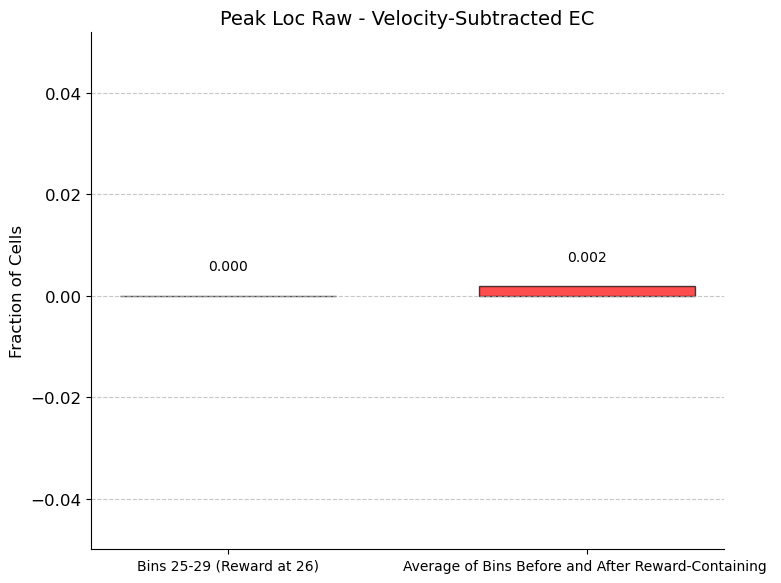

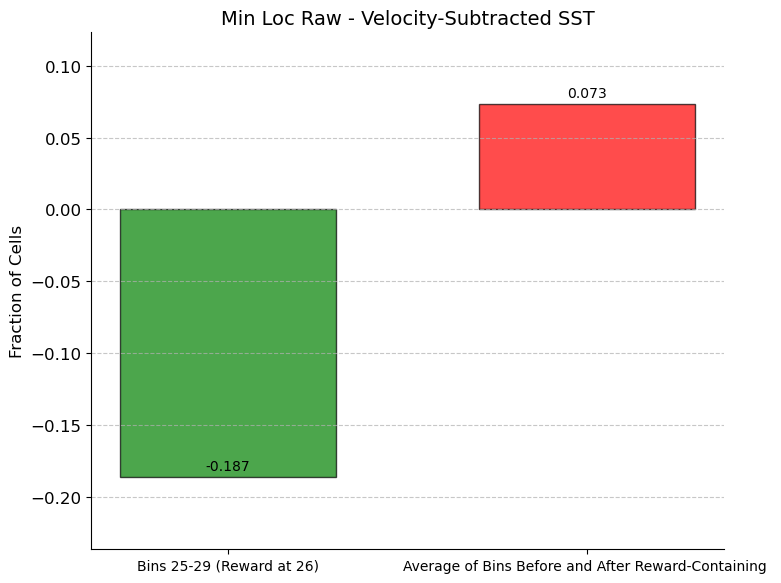

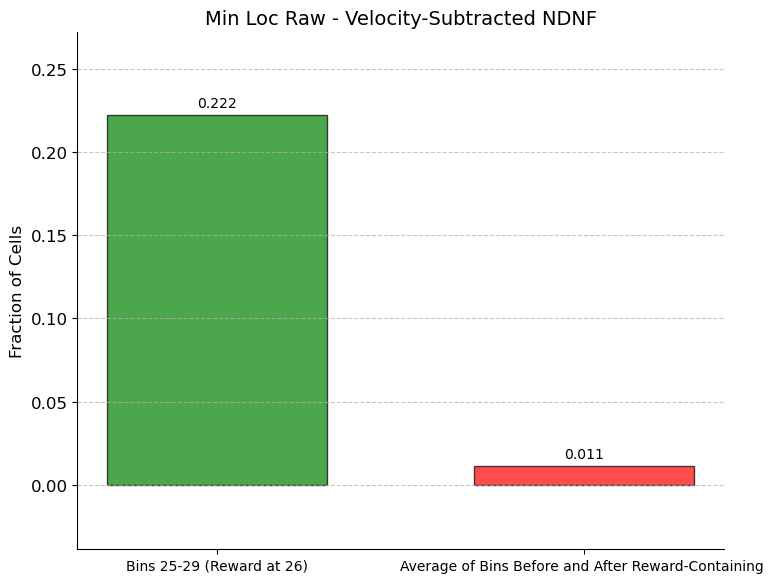

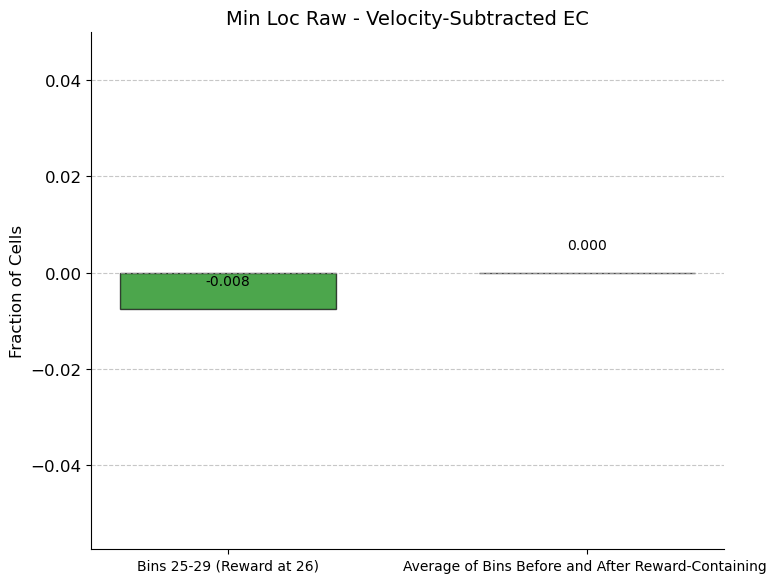

In [75]:
import numpy as np
import matplotlib.pyplot as plt

specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_SST_velocity[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_SST_velocity[before_bin_index],
    peak_loc_difference_learning_list_SST_velocity[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - Velocity-Subtracted SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_NDNF_velocity[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_NDNF_velocity[before_bin_index],
    peak_loc_difference_learning_list_NDNF_velocity[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - Velocity-Subtracted NDNF", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()




specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_EC_velocity[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_EC_velocity[before_bin_index],
    peak_loc_difference_learning_list_EC_velocity[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - Velocity-Subtracted EC", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_SST_velocity[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_SST_velocity[before_bin_index],
    Min_loc_difference_learning_list_SST_velocity[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - Velocity-Subtracted SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_NDNF_velocity[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_NDNF_velocity[before_bin_index],
    Min_loc_difference_learning_list_NDNF_velocity[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - Velocity-Subtracted NDNF", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()




specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_EC_velocity[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_EC_velocity[before_bin_index],
    Min_loc_difference_learning_list_EC_velocity[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - Velocity-Subtracted EC", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



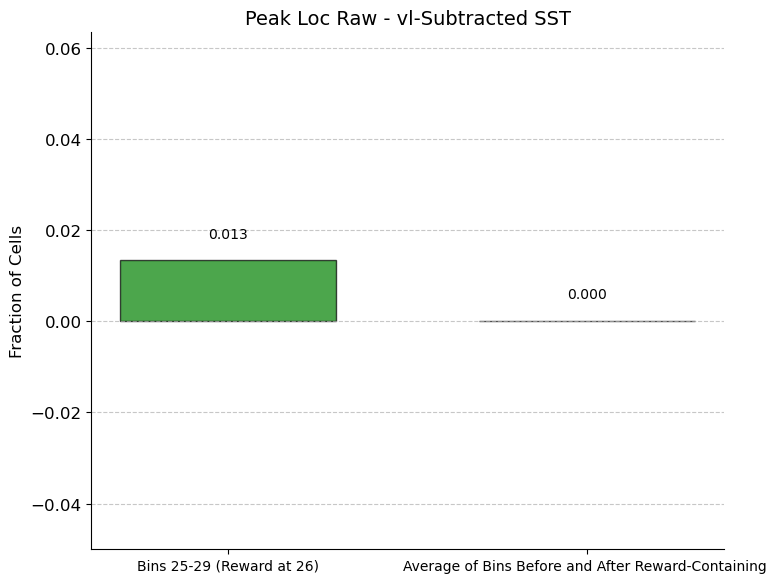

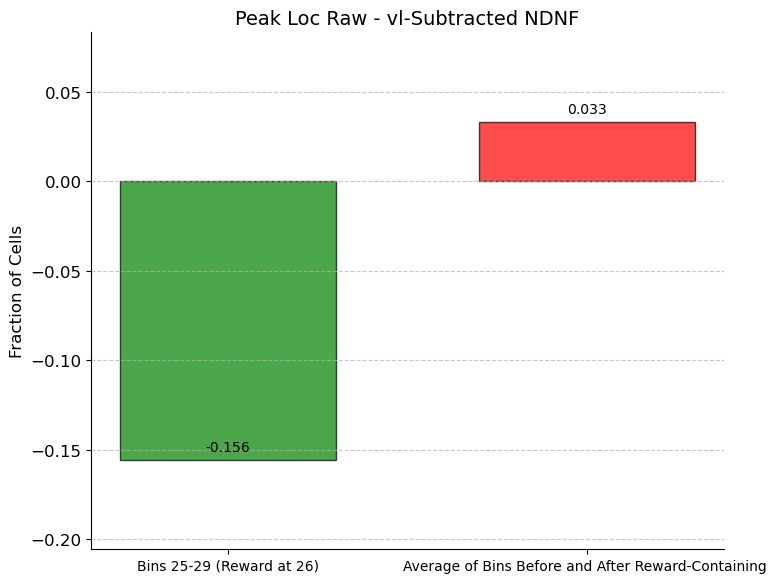

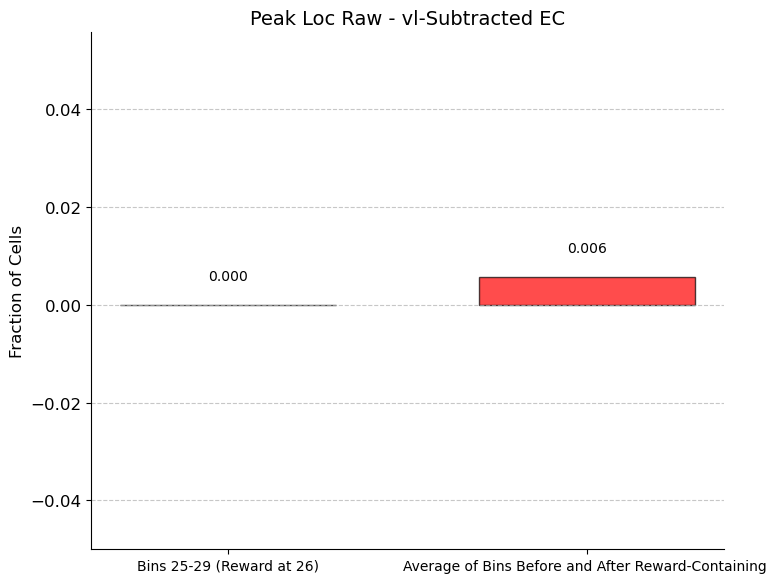

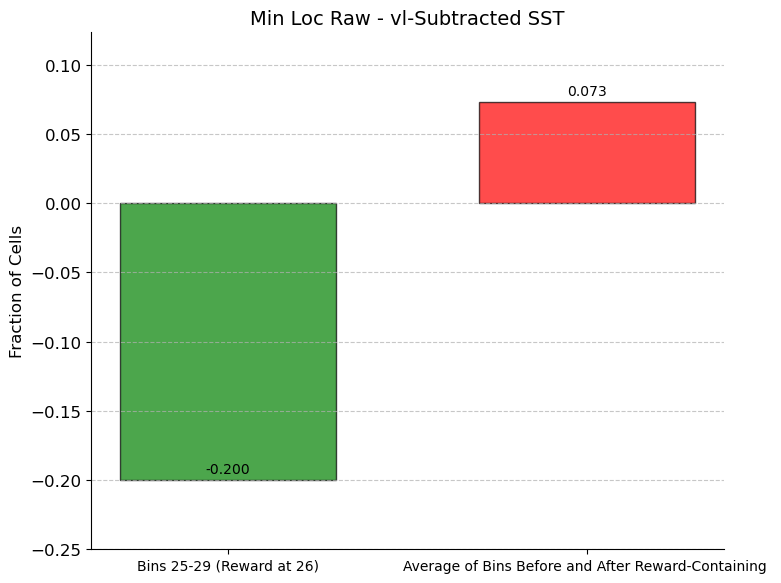

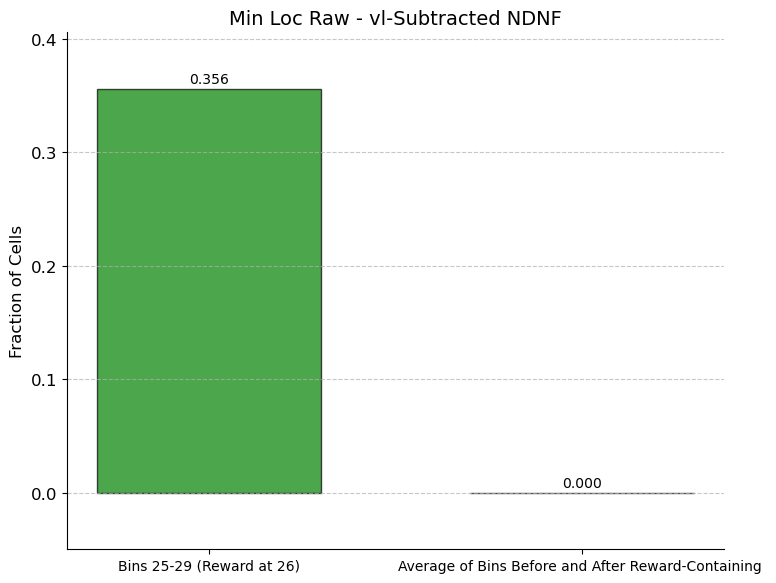

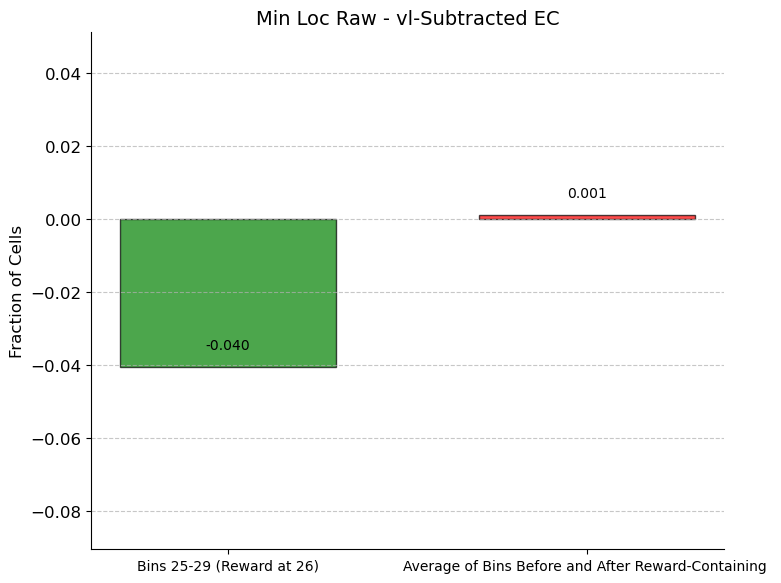

In [76]:
import numpy as np
import matplotlib.pyplot as plt

specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_SST_vl[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_SST_vl[before_bin_index],
    peak_loc_difference_learning_list_SST_vl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vl-Subtracted SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_NDNF_vl[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_NDNF_vl[before_bin_index],
    peak_loc_difference_learning_list_NDNF_vl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vl-Subtracted NDNF", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()




specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_EC_vl[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_EC_vl[before_bin_index],
    peak_loc_difference_learning_list_EC_vl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vl-Subtracted EC", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_SST_vl[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_SST_vl[before_bin_index],
    Min_loc_difference_learning_list_SST_vl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vl-Subtracted SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_NDNF_vl[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_NDNF_vl[before_bin_index],
    Min_loc_difference_learning_list_NDNF_vl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vl-Subtracted NDNF", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()




specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_EC_vl[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_EC_vl[before_bin_index],
    Min_loc_difference_learning_list_EC_vl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vl-Subtracted EC", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



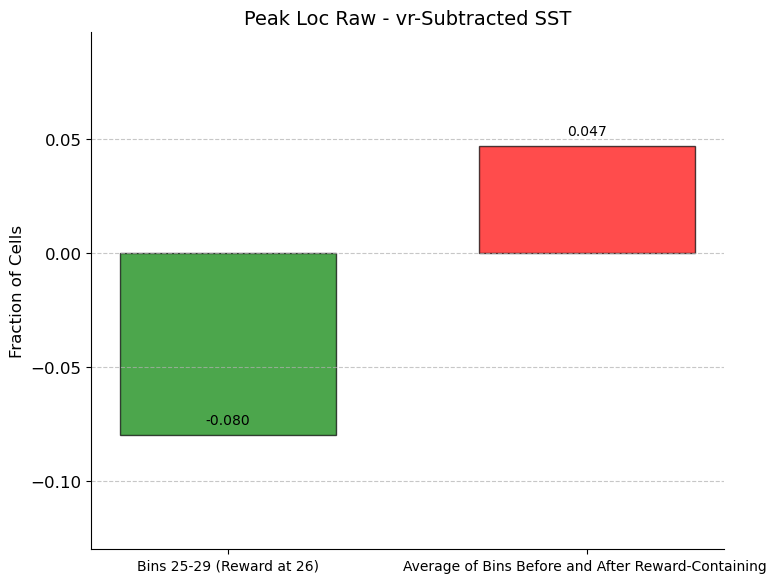

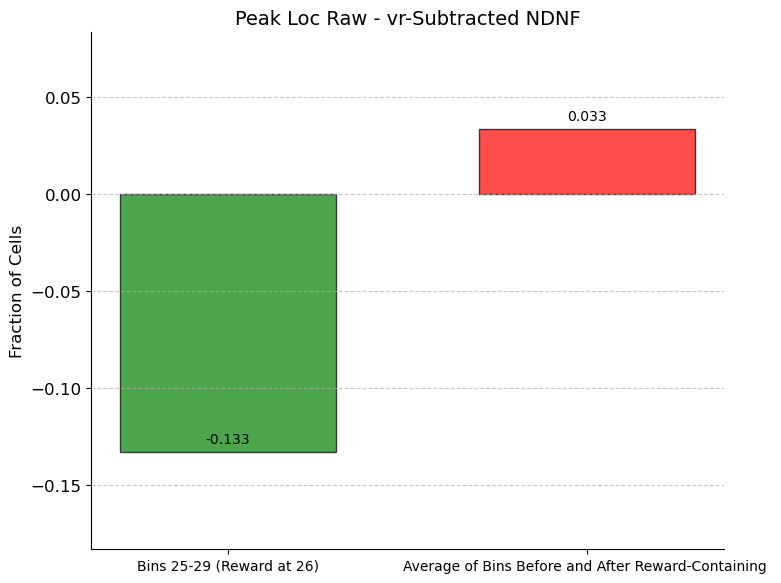

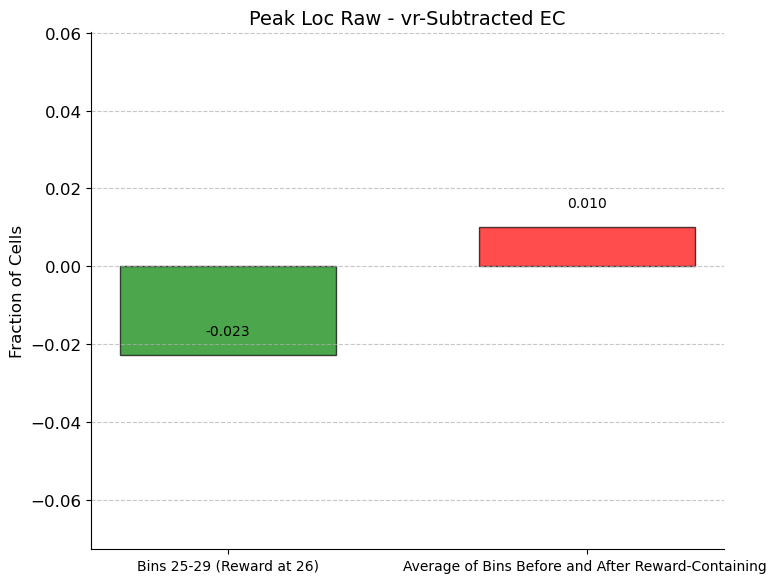

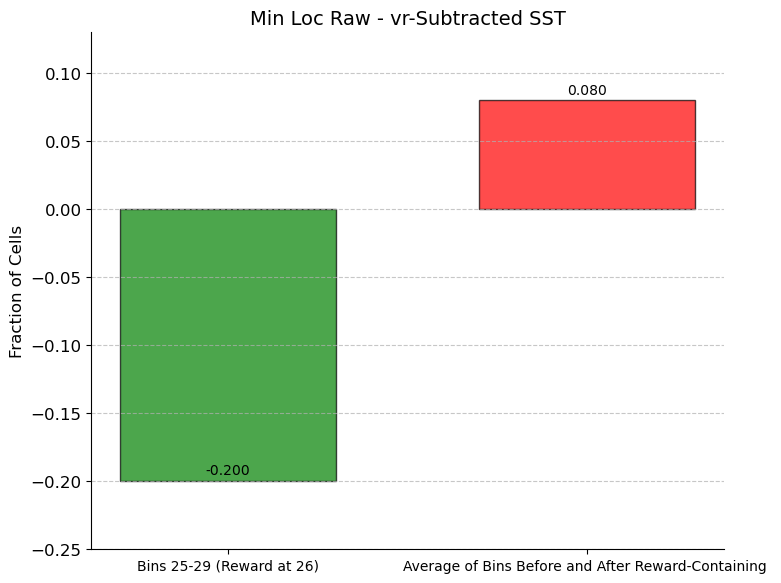

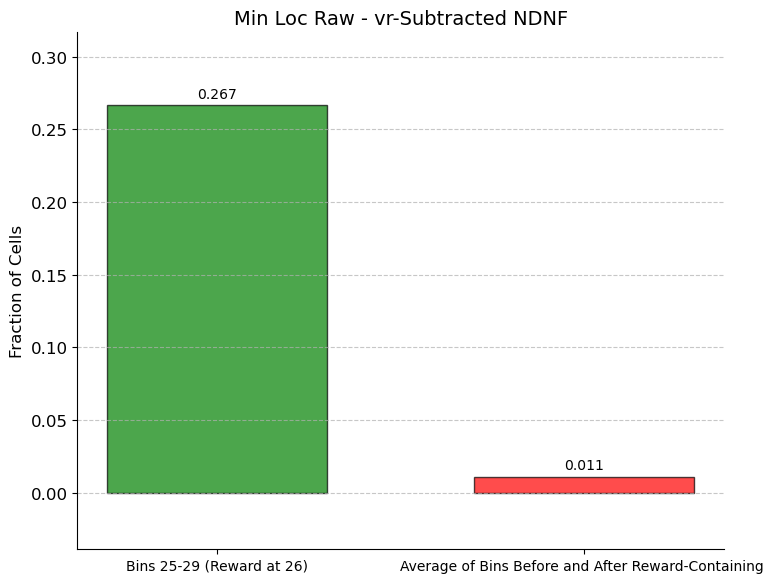

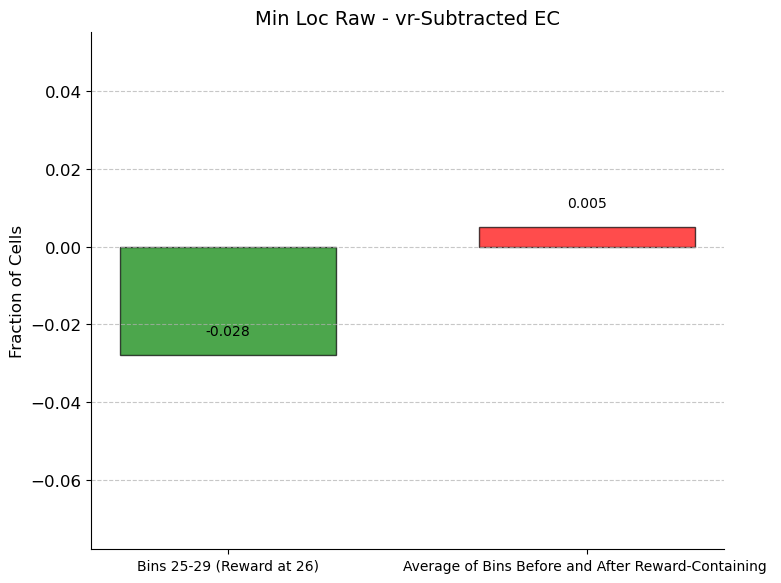

In [77]:
import numpy as np
import matplotlib.pyplot as plt

specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_SST_vr[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_SST_vr[before_bin_index],
    peak_loc_difference_learning_list_SST_vr[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vr-Subtracted SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_NDNF_vr[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_NDNF_vr[before_bin_index],
    peak_loc_difference_learning_list_NDNF_vr[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vr-Subtracted NDNF", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()




specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_EC_vr[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_EC_vr[before_bin_index],
    peak_loc_difference_learning_list_EC_vr[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vr-Subtracted EC", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_SST_vr[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_SST_vr[before_bin_index],
    Min_loc_difference_learning_list_SST_vr[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vr-Subtracted SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_NDNF_vr[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_NDNF_vr[before_bin_index],
    Min_loc_difference_learning_list_NDNF_vr[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vr-Subtracted NDNF", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()




specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_EC_vr[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_EC_vr[before_bin_index],
    Min_loc_difference_learning_list_EC_vr[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vr-Subtracted EC", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



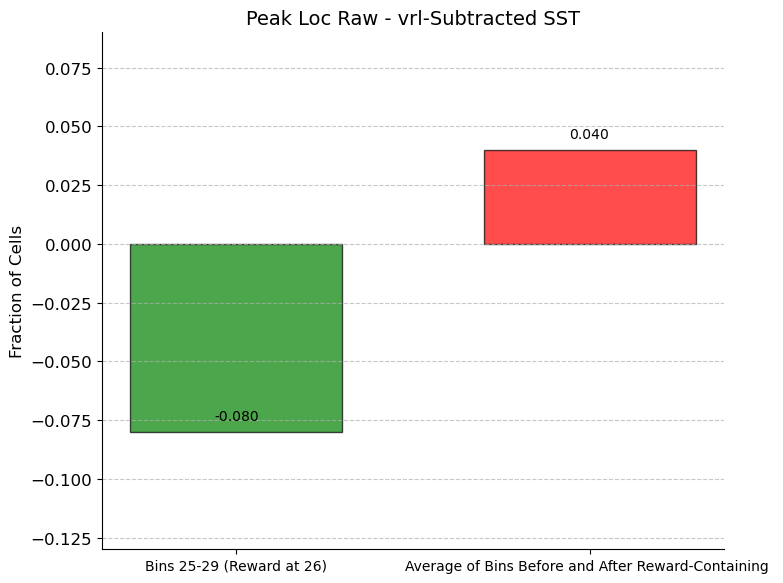

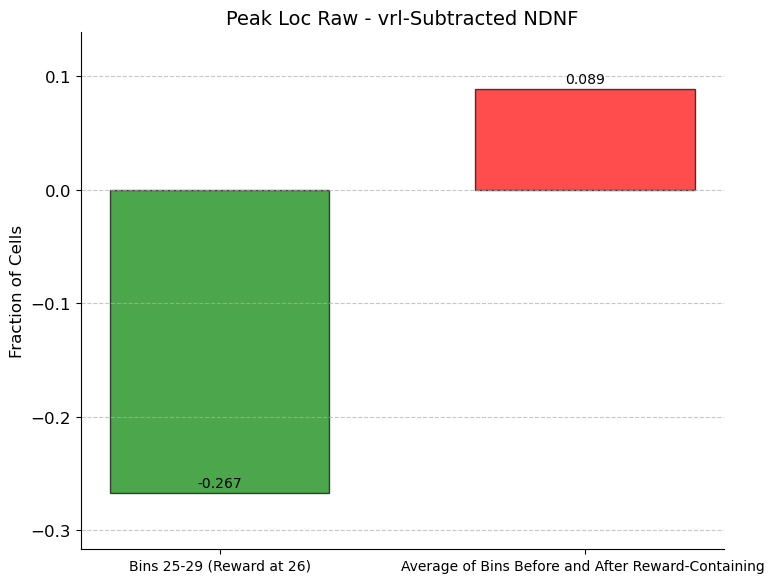

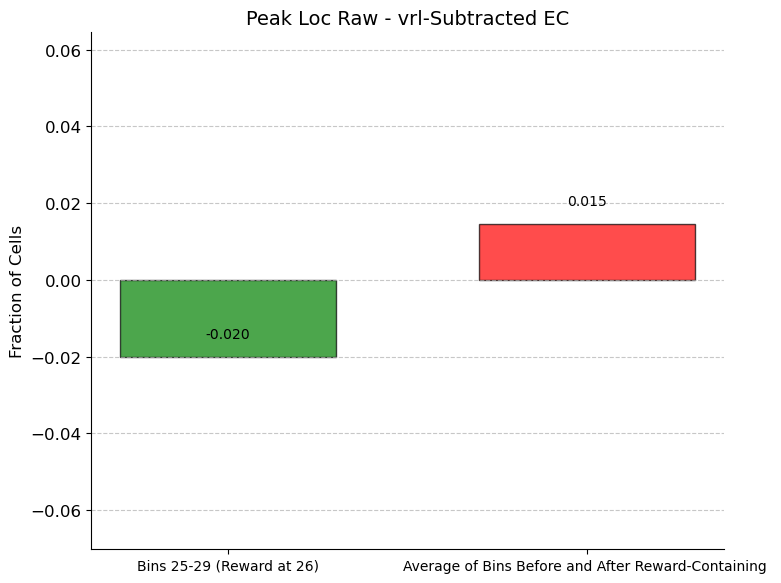

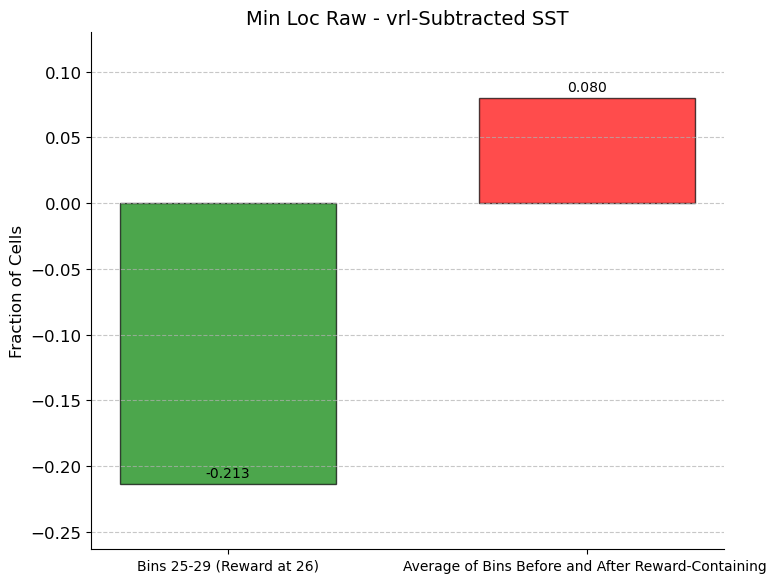

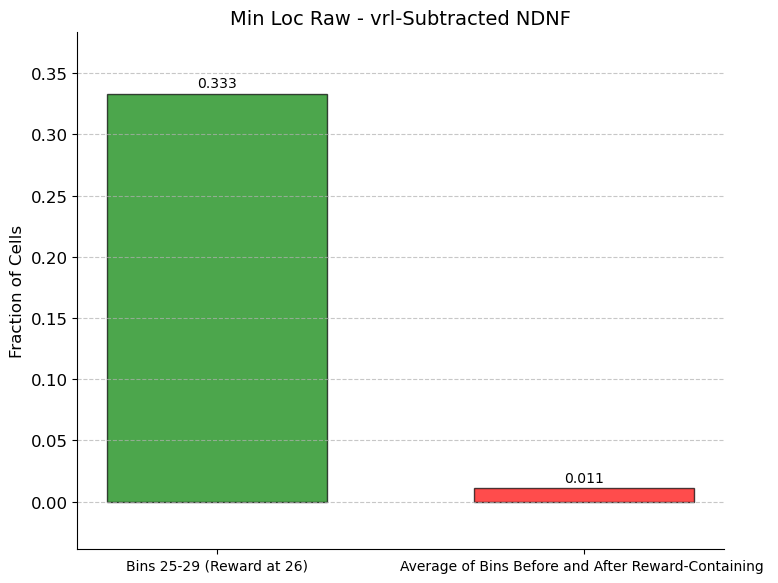

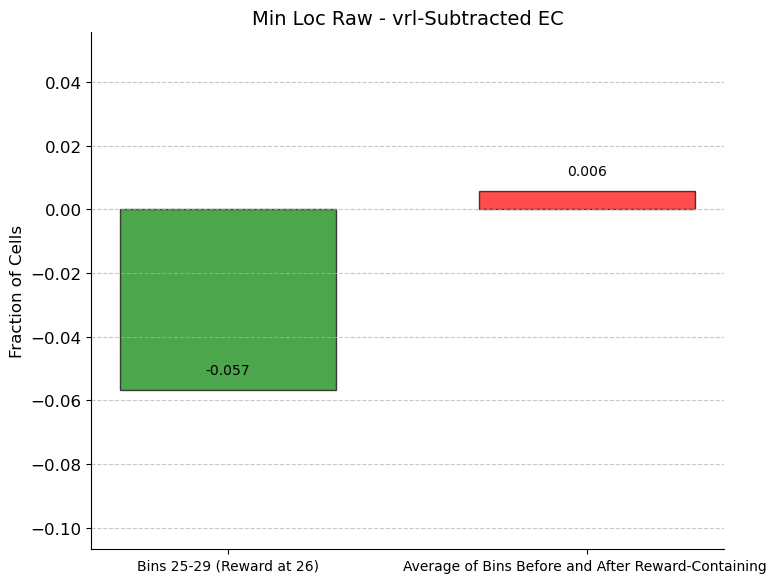

In [78]:
import numpy as np
import matplotlib.pyplot as plt

specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_SST_vrl[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_SST_vrl[before_bin_index],
    peak_loc_difference_learning_list_SST_vrl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vrl-Subtracted SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_NDNF_vrl[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_NDNF_vrl[before_bin_index],
    peak_loc_difference_learning_list_NDNF_vrl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vrl-Subtracted NDNF", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()




specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = peak_loc_difference_learning_list_EC_vrl[specific_bin_index]
before_after_bins_fraction = np.mean([
    peak_loc_difference_learning_list_EC_vrl[before_bin_index],
    peak_loc_difference_learning_list_EC_vrl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Peak Loc Raw - vrl-Subtracted EC", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_SST_vrl[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_SST_vrl[before_bin_index],
    Min_loc_difference_learning_list_SST_vrl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vrl-Subtracted SST", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_NDNF_vrl[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_NDNF_vrl[before_bin_index],
    Min_loc_difference_learning_list_NDNF_vrl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vrl-Subtracted NDNF", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()




specific_bin_index = 5  # Corresponds to bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34


specific_bin_fraction = Min_loc_difference_learning_list_EC_vrl[specific_bin_index]
before_after_bins_fraction = np.mean([
    Min_loc_difference_learning_list_EC_vrl[before_bin_index],
    Min_loc_difference_learning_list_EC_vrl[after_bin_index]
])

# Creating the bar chart
plt.figure(figsize=(8, 6))
x_positions = [0, 1]
y_values = [specific_bin_fraction, before_after_bins_fraction]
x_labels = ["Bins 25-29 (Reward at 26)", "Average of Bins Before and After Reward-Containing "]

# Bar chart
plt.bar(
    x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7
)

# Adding values on top of bars
for i, val in enumerate(y_values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10, color="black")

# Customizing plot
plt.title("Min Loc Raw - vrl-Subtracted EC", fontsize=14)
plt.ylabel("Fraction of Cells", fontsize=12)
plt.xticks(x_positions, x_labels, fontsize=10)
plt.ylim(min(y_values)-0.05, max(y_values) + 0.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()



In [43]:
bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vl_hist, _ = np.histogram(argmin_list_NDNF_vl, bins=bin_edges)

Min_loc_difference_learning = (vl_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vl.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vl)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vl)
    

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vl_hist, _ = np.histogram(argmin_list_NDNF_vl, bins=bin_edges)

Min_loc_difference_learning = (vl_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vl.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vl)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vl)
    


bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_EC, bins=bin_edges)
vl_hist, _ = np.histogram(argmin_list_EC_vl, bins=bin_edges)

Min_loc_difference_learning = (vl_hist - raw_hist)

Min_loc_difference_learning_list_EC_vl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_EC)
    Min_loc_difference_learning_list_EC_vl.append(value)

y_min = np.min(Min_loc_difference_learning_list_EC_vl)
y_max = np.max(Min_loc_difference_learning_list_EC_vl)


bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vr_hist, _ = np.histogram(argmin_list_NDNF_vr, bins=bin_edges)

Min_loc_difference_learning = (vr_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vr = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vr.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vr)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vr)




bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vr_hist, _ = np.histogram(argmin_list_NDNF_vr, bins=bin_edges)

Min_loc_difference_learning = (vr_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vr = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vr.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vr)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vr)







bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_EC, bins=bin_edges)
vr_hist, _ = np.histogram(argmin_list_EC_vr, bins=bin_edges)

Min_loc_difference_learning = (vr_hist - raw_hist)

Min_loc_difference_learning_list_EC_vr = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_EC)
    Min_loc_difference_learning_list_EC_vr.append(value)

y_min = np.min(Min_loc_difference_learning_list_EC_vr)
y_max = np.max(Min_loc_difference_learning_list_EC_vr)







bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vrl_hist, _ = np.histogram(argmin_list_NDNF_vrl, bins=bin_edges)

Min_loc_difference_learning = (vrl_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vrl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vrl.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vrl)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vrl)





bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vrl_hist, _ = np.histogram(argmin_list_NDNF_vrl, bins=bin_edges)

Min_loc_difference_learning = (vrl_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vrl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vrl.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vrl)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vrl)





bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_EC, bins=bin_edges)
vrl_hist, _ = np.histogram(argmin_list_EC_vrl, bins=bin_edges)

Min_loc_difference_learning = (vrl_hist - raw_hist)

Min_loc_difference_learning_list_EC_vrl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_EC)
    Min_loc_difference_learning_list_EC_vrl.append(value)

y_min = np.min(Min_loc_difference_learning_list_EC_vrl)
y_max = np.max(Min_loc_difference_learning_list_EC_vrl)


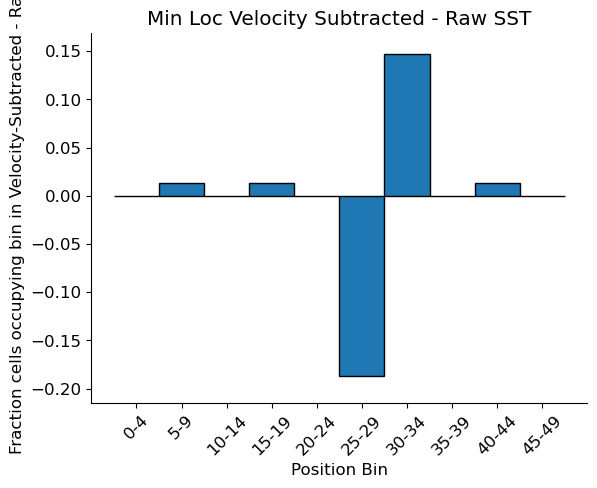

In [24]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_SST, bins=bin_edges)
velocity_hist, _ = np.histogram(argmin_list_SST_velocity, bins=bin_edges)

Min_loc_difference_learning = (velocity_hist - raw_hist)

Min_loc_difference_learning_list_SST_velocity = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_SST)
    Min_loc_difference_learning_list_SST_velocity.append(value)

y_min = np.min(Min_loc_difference_learning_list_SST_velocity)
y_max = np.max(Min_loc_difference_learning_list_SST_velocity)
    
plt.figure()
plt.bar(bin_centers, Min_loc_difference_learning_list_SST_velocity, width=5, align='center', edgecolor='k')
plt.title('Min Loc Velocity Subtracted - Raw SST')
plt.ylabel('Fraction cells occupying bin in Velocity-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

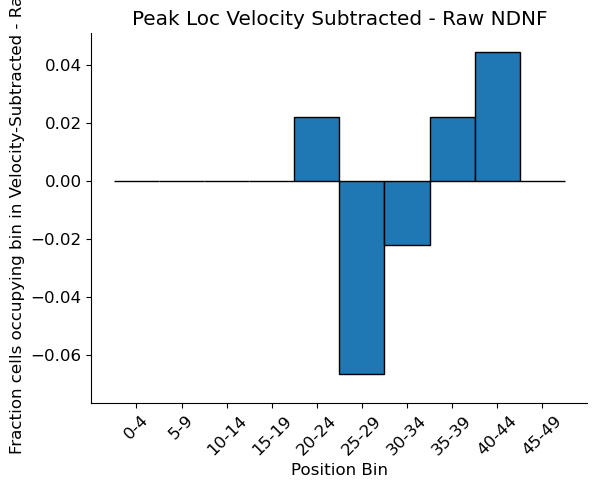

In [62]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_NDNF, bins=bin_edges)
velocity_hist, _ = np.histogram(argmax_list_NDNF_velocity, bins=bin_edges)

peak_loc_difference_learning = (velocity_hist - raw_hist)

peak_loc_difference_learning_list_NDNF_velocity = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_NDNF)
    peak_loc_difference_learning_list_NDNF_velocity.append(value)

y_min = np.min(peak_loc_difference_learning_list_NDNF_velocity)
y_max = np.max(peak_loc_difference_learning_list_NDNF_velocity)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_NDNF_velocity, width=5, align='center', edgecolor='k')
plt.title('Peak Loc Velocity Subtracted - Raw NDNF')
plt.ylabel('Fraction cells occupying bin in Velocity-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

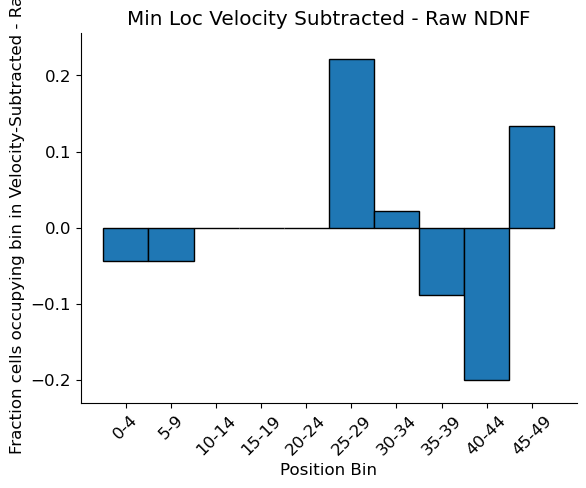

In [61]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
velocity_hist, _ = np.histogram(argmin_list_NDNF_velocity, bins=bin_edges)

Min_loc_difference_learning = (velocity_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_velocity = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_velocity.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_velocity)
y_max = np.max(Min_loc_difference_learning_list_NDNF_velocity)
    
plt.figure()
plt.bar(bin_centers, Min_loc_difference_learning_list_NDNF_velocity, width=5, align='center', edgecolor='k')
plt.title('Min Loc Velocity Subtracted - Raw NDNF')
plt.ylabel('Fraction cells occupying bin in Velocity-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

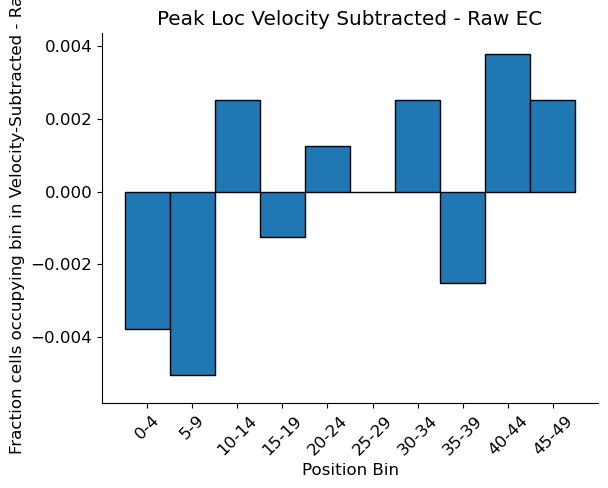

In [13]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_EC, bins=bin_edges)
velocity_hist, _ = np.histogram(argmax_list_EC_velocity, bins=bin_edges)

peak_loc_difference_learning = (velocity_hist - raw_hist)

peak_loc_difference_learning_list_EC_velocity = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_EC)
    peak_loc_difference_learning_list_EC_velocity.append(value)

y_min = np.min(peak_loc_difference_learning_list_EC_velocity)
y_max = np.max(peak_loc_difference_learning_list_EC_velocity)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_EC_velocity, width=5, align='center', edgecolor='k')
plt.title('Peak Loc Velocity Subtracted - Raw EC')
plt.ylabel('Fraction cells occupying bin in Velocity-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

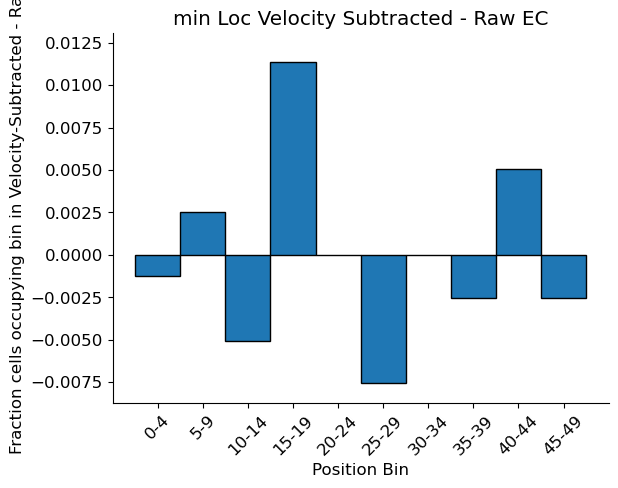

In [26]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_EC, bins=bin_edges)
velocity_hist, _ = np.histogram(argmin_list_EC_velocity, bins=bin_edges)

min_loc_difference_learning = (velocity_hist - raw_hist)

min_loc_difference_learning_list_EC_velocity = []

for value in min_loc_difference_learning:
    value = value / len(Argmin_list_raw_EC)
    min_loc_difference_learning_list_EC_velocity.append(value)

y_min = np.min(min_loc_difference_learning_list_EC_velocity)
y_max = np.max(min_loc_difference_learning_list_EC_velocity)
    
plt.figure()
plt.bar(bin_centers, min_loc_difference_learning_list_EC_velocity, width=5, align='center', edgecolor='k')
plt.title('min Loc Velocity Subtracted - Raw EC')
plt.ylabel('Fraction cells occupying bin in Velocity-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

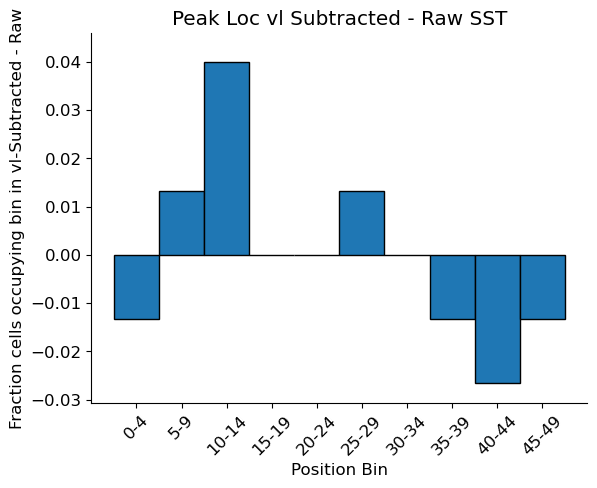

In [9]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_SST, bins=bin_edges)
vl_hist, _ = np.histogram(argmax_list_SST_vl, bins=bin_edges)

peak_loc_difference_learning = (vl_hist - raw_hist)

peak_loc_difference_learning_list_SST_vl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_SST)
    peak_loc_difference_learning_list_SST_vl.append(value)

y_min = np.min(peak_loc_difference_learning_list_SST_vl)
y_max = np.max(peak_loc_difference_learning_list_SST_vl)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_SST_vl, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vl Subtracted - Raw SST')
plt.ylabel('Fraction cells occupying bin in vl-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

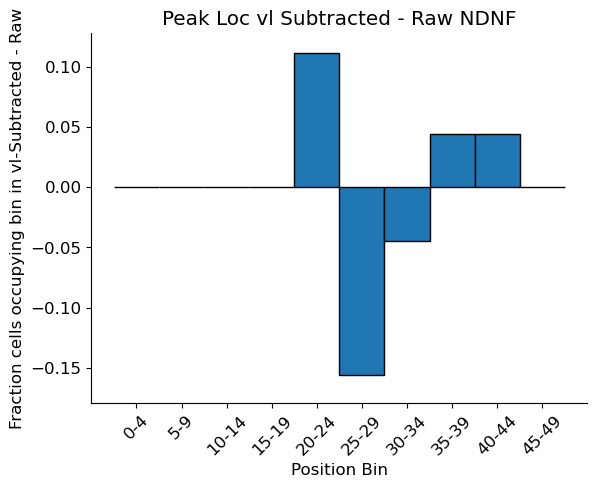

In [14]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_NDNF, bins=bin_edges)
vl_hist, _ = np.histogram(argmax_list_NDNF_vl, bins=bin_edges)

peak_loc_difference_learning = (vl_hist - raw_hist)

peak_loc_difference_learning_list_NDNF_vl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_NDNF)
    peak_loc_difference_learning_list_NDNF_vl.append(value)

y_min = np.min(peak_loc_difference_learning_list_NDNF_vl)
y_max = np.max(peak_loc_difference_learning_list_NDNF_vl)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_NDNF_vl, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vl Subtracted - Raw NDNF')
plt.ylabel('Fraction cells occupying bin in vl-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

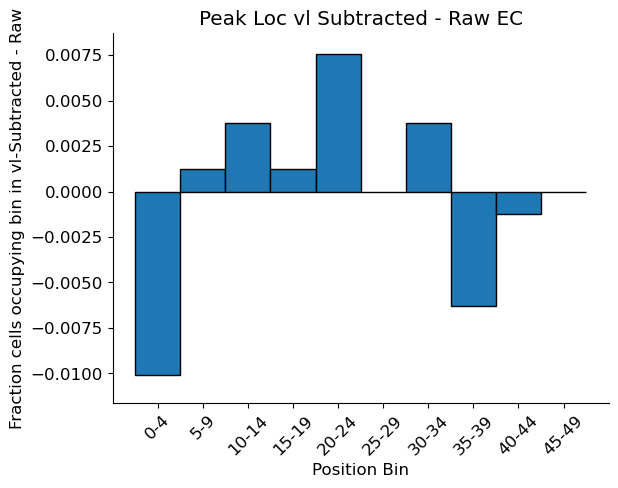

In [15]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_EC, bins=bin_edges)
vl_hist, _ = np.histogram(argmax_list_EC_vl, bins=bin_edges)

peak_loc_difference_learning = (vl_hist - raw_hist)

peak_loc_difference_learning_list_EC_vl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_EC)
    peak_loc_difference_learning_list_EC_vl.append(value)

y_min = np.min(peak_loc_difference_learning_list_EC_vl)
y_max = np.max(peak_loc_difference_learning_list_EC_vl)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_EC_vl, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vl Subtracted - Raw EC')
plt.ylabel('Fraction cells occupying bin in vl-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

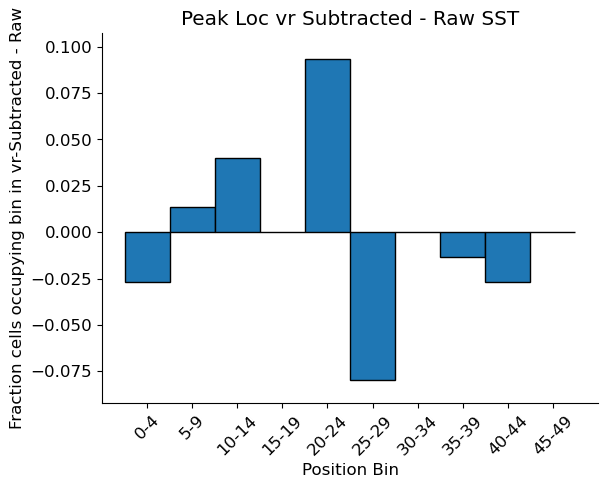

In [10]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_SST, bins=bin_edges)
vr_hist, _ = np.histogram(argmax_list_SST_vr, bins=bin_edges)

peak_loc_difference_learning = (vr_hist - raw_hist)

peak_loc_difference_learning_list_SST_vr = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_SST)
    peak_loc_difference_learning_list_SST_vr.append(value)

y_min = np.min(peak_loc_difference_learning_list_SST_vr)
y_max = np.max(peak_loc_difference_learning_list_SST_vr)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_SST_vr, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vr Subtracted - Raw SST')
plt.ylabel('Fraction cells occupying bin in vr-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

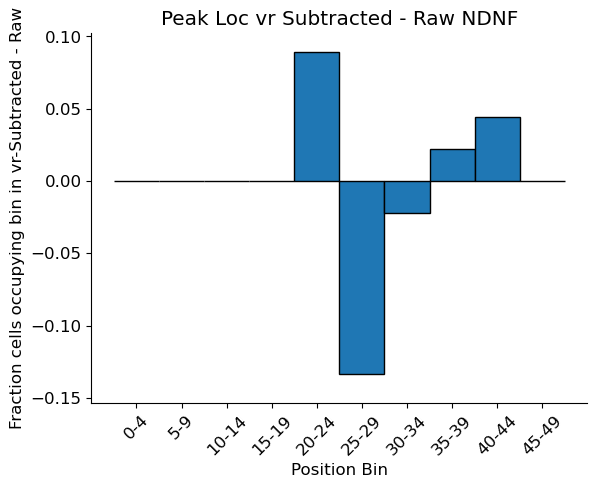

In [16]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_NDNF, bins=bin_edges)
vr_hist, _ = np.histogram(argmax_list_NDNF_vr, bins=bin_edges)

peak_loc_difference_learning = (vr_hist - raw_hist)

peak_loc_difference_learning_list_NDNF_vr = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_NDNF)
    peak_loc_difference_learning_list_NDNF_vr.append(value)

y_min = np.min(peak_loc_difference_learning_list_NDNF_vr)
y_max = np.max(peak_loc_difference_learning_list_NDNF_vr)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_NDNF_vr, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vr Subtracted - Raw NDNF')
plt.ylabel('Fraction cells occupying bin in vr-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

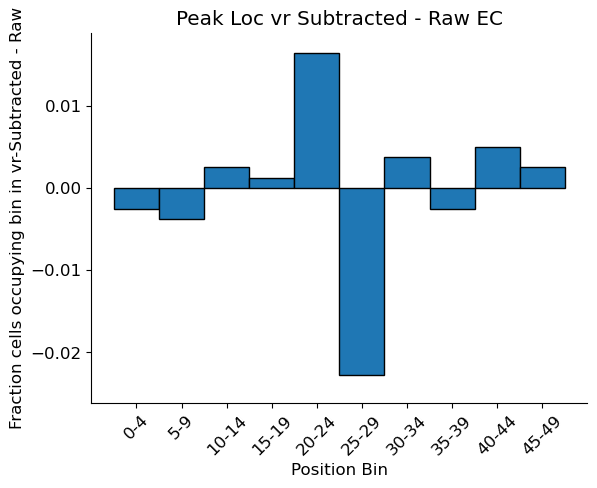

In [17]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_EC, bins=bin_edges)
vr_hist, _ = np.histogram(argmax_list_EC_vr, bins=bin_edges)

peak_loc_difference_learning = (vr_hist - raw_hist)

peak_loc_difference_learning_list_EC_vr = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_EC)
    peak_loc_difference_learning_list_EC_vr.append(value)

y_min = np.min(peak_loc_difference_learning_list_EC_vr)
y_max = np.max(peak_loc_difference_learning_list_EC_vr)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_EC_vr, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vr Subtracted - Raw EC')
plt.ylabel('Fraction cells occupying bin in vr-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

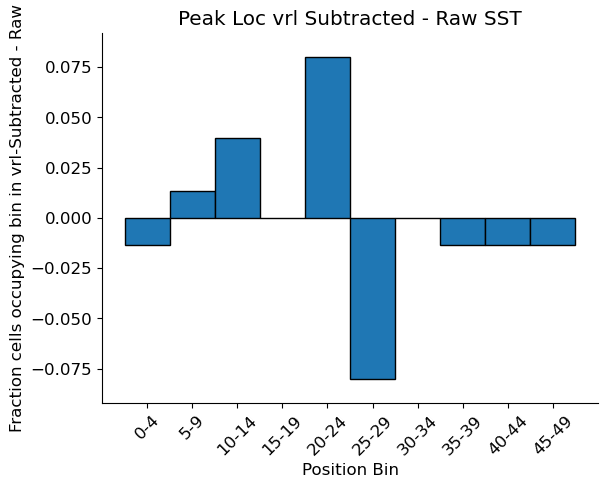

In [11]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_SST, bins=bin_edges)
vrl_hist, _ = np.histogram(argmax_list_SST_vrl, bins=bin_edges)

peak_loc_difference_learning = (vrl_hist - raw_hist)

peak_loc_difference_learning_list_SST_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_SST)
    peak_loc_difference_learning_list_SST_vrl.append(value)

y_min = np.min(peak_loc_difference_learning_list_SST_vrl)
y_max = np.max(peak_loc_difference_learning_list_SST_vrl)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_SST_vrl, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vrl Subtracted - Raw SST')
plt.ylabel('Fraction cells occupying bin in vrl-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

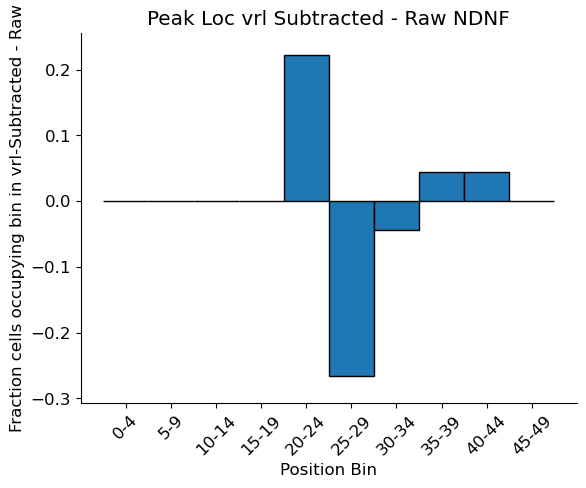

In [18]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_NDNF, bins=bin_edges)
vrl_hist, _ = np.histogram(argmax_list_NDNF_vrl, bins=bin_edges)

peak_loc_difference_learning = (vrl_hist - raw_hist)

peak_loc_difference_learning_list_NDNF_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_NDNF)
    peak_loc_difference_learning_list_NDNF_vrl.append(value)

y_min = np.min(peak_loc_difference_learning_list_NDNF_vrl)
y_max = np.max(peak_loc_difference_learning_list_NDNF_vrl)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_NDNF_vrl, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vrl Subtracted - Raw NDNF')
plt.ylabel('Fraction cells occupying bin in vrl-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

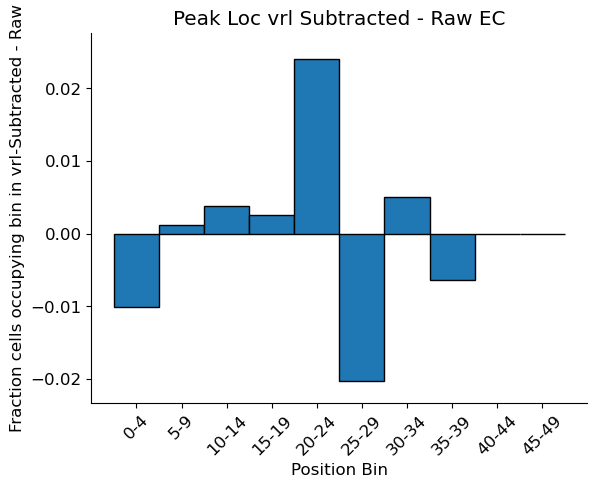

In [19]:

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_EC, bins=bin_edges)
vrl_hist, _ = np.histogram(argmax_list_EC_vrl, bins=bin_edges)

peak_loc_difference_learning = (vrl_hist - raw_hist)

peak_loc_difference_learning_list_EC_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_EC)
    peak_loc_difference_learning_list_EC_vrl.append(value)

y_min = np.min(peak_loc_difference_learning_list_EC_vrl)
y_max = np.max(peak_loc_difference_learning_list_EC_vrl)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_EC_vrl, width=5, align='center', edgecolor='k')
plt.title('Peak Loc vrl Subtracted - Raw EC')
plt.ylabel('Fraction cells occupying bin in vrl-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


plt.show()

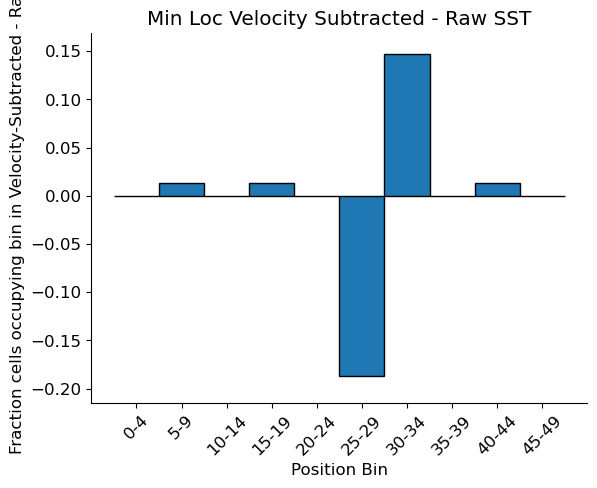

In [57]:


bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_SST, bins=bin_edges)
velocity_hist, _ = np.histogram(argmin_list_SST_velocity, bins=bin_edges)

Min_loc_difference_learning = (velocity_hist - raw_hist)

Min_loc_difference_learning_list_SST_velocity = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_SST)
    Min_loc_difference_learning_list_SST_velocity.append(value)

y_min = np.min(Min_loc_difference_learning_list_SST_velocity)
y_max = np.max(Min_loc_difference_learning_list_SST_velocity)
    
plt.figure()
plt.bar(bin_centers, Min_loc_difference_learning_list_SST_velocity, width=5, align='center', edgecolor='k')
plt.title('Min Loc Velocity Subtracted - Raw SST')
plt.ylabel('Fraction cells occupying bin in Velocity-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)




bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
velocity_hist, _ = np.histogram(argmin_list_NDNF_velocity, bins=bin_edges)

Min_loc_difference_learning = (velocity_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_velocity = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_velocity.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_velocity)
y_max = np.max(Min_loc_difference_learning_list_NDNF_velocity)

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_EC, bins=bin_edges)
velocity_hist, _ = np.histogram(argmax_list_EC_velocity, bins=bin_edges)

peak_loc_difference_learning = (velocity_hist - raw_hist)

peak_loc_difference_learning_list_EC_velocity = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_EC)
    peak_loc_difference_learning_list_EC_velocity.append(value)

y_min = np.min(peak_loc_difference_learning_list_EC_velocity)
y_max = np.max(peak_loc_difference_learning_list_EC_velocity)



bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_SST, bins=bin_edges)
vl_hist, _ = np.histogram(argmax_list_SST_vl, bins=bin_edges)

peak_loc_difference_learning = (vl_hist - raw_hist)

peak_loc_difference_learning_list_SST_vl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_SST)
    peak_loc_difference_learning_list_SST_vl.append(value)

y_min = np.min(peak_loc_difference_learning_list_SST_vl)
y_max = np.max(peak_loc_difference_learning_list_SST_vl)



bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_NDNF, bins=bin_edges)
vl_hist, _ = np.histogram(argmax_list_NDNF_vl, bins=bin_edges)

peak_loc_difference_learning = (vl_hist - raw_hist)

peak_loc_difference_learning_list_NDNF_vl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_NDNF)
    peak_loc_difference_learning_list_NDNF_vl.append(value)

y_min = np.min(peak_loc_difference_learning_list_NDNF_vl)
y_max = np.max(peak_loc_difference_learning_list_NDNF_vl)



bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_EC, bins=bin_edges)
vl_hist, _ = np.histogram(argmax_list_EC_vl, bins=bin_edges)

peak_loc_difference_learning = (vl_hist - raw_hist)

peak_loc_difference_learning_list_EC_vl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_EC)
    peak_loc_difference_learning_list_EC_vl.append(value)

y_min = np.min(peak_loc_difference_learning_list_EC_vl)
y_max = np.max(peak_loc_difference_learning_list_EC_vl)




bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_SST, bins=bin_edges)
vr_hist, _ = np.histogram(argmax_list_SST_vr, bins=bin_edges)

peak_loc_difference_learning = (vr_hist - raw_hist)

peak_loc_difference_learning_list_SST_vr = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_SST)
    peak_loc_difference_learning_list_SST_vr.append(value)

y_min = np.min(peak_loc_difference_learning_list_SST_vr)
y_max = np.max(peak_loc_difference_learning_list_SST_vr)


bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_NDNF, bins=bin_edges)
vr_hist, _ = np.histogram(argmax_list_NDNF_vr, bins=bin_edges)

peak_loc_difference_learning = (vr_hist - raw_hist)

peak_loc_difference_learning_list_NDNF_vr = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_NDNF)
    peak_loc_difference_learning_list_NDNF_vr.append(value)

y_min = np.min(peak_loc_difference_learning_list_NDNF_vr)
y_max = np.max(peak_loc_difference_learning_list_NDNF_vr)




bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_EC, bins=bin_edges)
vr_hist, _ = np.histogram(argmax_list_EC_vr, bins=bin_edges)

peak_loc_difference_learning = (vr_hist - raw_hist)

peak_loc_difference_learning_list_EC_vr = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_EC)
    peak_loc_difference_learning_list_EC_vr.append(value)

y_min = np.min(peak_loc_difference_learning_list_EC_vr)
y_max = np.max(peak_loc_difference_learning_list_EC_vr)




bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_SST, bins=bin_edges)
vrl_hist, _ = np.histogram(argmax_list_SST_vrl, bins=bin_edges)

peak_loc_difference_learning = (vrl_hist - raw_hist)

peak_loc_difference_learning_list_SST_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_SST)
    peak_loc_difference_learning_list_SST_vrl.append(value)

y_min = np.min(peak_loc_difference_learning_list_SST_vrl)
y_max = np.max(peak_loc_difference_learning_list_SST_vrl)


bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_NDNF, bins=bin_edges)
vrl_hist, _ = np.histogram(argmax_list_NDNF_vrl, bins=bin_edges)

peak_loc_difference_learning = (vrl_hist - raw_hist)

peak_loc_difference_learning_list_NDNF_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_NDNF)
    peak_loc_difference_learning_list_NDNF_vrl.append(value)

y_min = np.min(peak_loc_difference_learning_list_NDNF_vrl)
y_max = np.max(peak_loc_difference_learning_list_NDNF_vrl)




bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_EC, bins=bin_edges)
vrl_hist, _ = np.histogram(argmax_list_EC_vrl, bins=bin_edges)

peak_loc_difference_learning = (vrl_hist - raw_hist)

peak_loc_difference_learning_list_EC_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_EC)
    peak_loc_difference_learning_list_EC_vrl.append(value)

y_min = np.min(peak_loc_difference_learning_list_EC_vrl)
y_max = np.max(peak_loc_difference_learning_list_EC_vrl)

([<matplotlib.axis.XTick at 0x20cf01f4410>,
 [Text(2.5, 0, '0-4'),
  Text(7.5, 0, '5-9'),
  Text(12.5, 0, '10-14'),
  Text(17.5, 0, '15-19'),
  Text(22.5, 0, '20-24'),
  Text(27.5, 0, '25-29'),
  Text(32.5, 0, '30-34'),
  Text(37.5, 0, '35-39'),
  Text(42.5, 0, '40-44'),
  Text(47.5, 0, '45-49')])

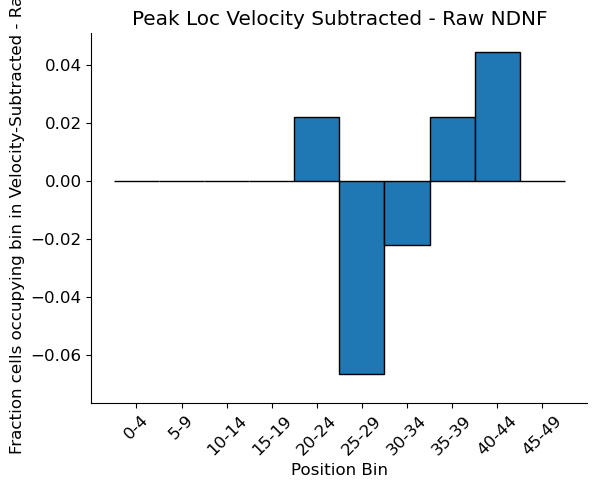

In [63]:
bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_SST, bins=bin_edges)
velocity_hist, _ = np.histogram(argmin_list_SST_velocity, bins=bin_edges)

Min_loc_difference_learning = (velocity_hist - raw_hist)

Min_loc_difference_learning_list_SST_velocity = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_SST)
    Min_loc_difference_learning_list_SST_velocity.append(value)

y_min = np.min(Min_loc_difference_learning_list_SST_velocity)
y_max = np.max(Min_loc_difference_learning_list_SST_velocity)
    

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
velocity_hist, _ = np.histogram(argmin_list_NDNF_velocity, bins=bin_edges)

Min_loc_difference_learning = (velocity_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_velocity = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_velocity.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_velocity)
y_max = np.max(Min_loc_difference_learning_list_NDNF_velocity)
    


bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_EC, bins=bin_edges)
velocity_hist, _ = np.histogram(argmin_list_EC_velocity, bins=bin_edges)

Min_loc_difference_learning = (velocity_hist - raw_hist)

Min_loc_difference_learning_list_EC_velocity = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_EC)
    Min_loc_difference_learning_list_EC_velocity.append(value)

y_min = np.min(Min_loc_difference_learning_list_EC_velocity)
y_max = np.max(Min_loc_difference_learning_list_EC_velocity)



bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_SST, bins=bin_edges)
vl_hist, _ = np.histogram(argmin_list_SST_vl, bins=bin_edges)

Min_loc_difference_learning = (vl_hist - raw_hist)

Min_loc_difference_learning_list_SST_vl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_SST)
    Min_loc_difference_learning_list_SST_vl.append(value)

y_min = np.min(Min_loc_difference_learning_list_SST_vl)
y_max = np.max(Min_loc_difference_learning_list_SST_vl)
    

bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vl_hist, _ = np.histogram(argmin_list_NDNF_vl, bins=bin_edges)

Min_loc_difference_learning = (vl_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vl.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vl)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vl)
    


bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_EC, bins=bin_edges)
vl_hist, _ = np.histogram(argmin_list_EC_vl, bins=bin_edges)

Min_loc_difference_learning = (vl_hist - raw_hist)

Min_loc_difference_learning_list_EC_vl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_EC)
    Min_loc_difference_learning_list_EC_vl.append(value)

y_min = np.min(Min_loc_difference_learning_list_EC_vl)
y_max = np.max(Min_loc_difference_learning_list_EC_vl)


bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_SST, bins=bin_edges)
vr_hist, _ = np.histogram(argmin_list_SST_vr, bins=bin_edges)

Min_loc_difference_learning = (vr_hist - raw_hist)

Min_loc_difference_learning_list_SST_vr = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_SST)
    Min_loc_difference_learning_list_SST_vr.append(value)

y_min = np.min(Min_loc_difference_learning_list_SST_vr)
y_max = np.max(Min_loc_difference_learning_list_SST_vr)




bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vr_hist, _ = np.histogram(argmin_list_NDNF_vr, bins=bin_edges)

Min_loc_difference_learning = (vr_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vr = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vr.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vr)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vr)







bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_EC, bins=bin_edges)
vr_hist, _ = np.histogram(argmin_list_EC_vr, bins=bin_edges)

Min_loc_difference_learning = (vr_hist - raw_hist)

Min_loc_difference_learning_list_EC_vr = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_EC)
    Min_loc_difference_learning_list_EC_vr.append(value)

y_min = np.min(Min_loc_difference_learning_list_EC_vr)
y_max = np.max(Min_loc_difference_learning_list_EC_vr)







bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_SST, bins=bin_edges)
vrl_hist, _ = np.histogram(argmin_list_SST_vrl, bins=bin_edges)

Min_loc_difference_learning = (vrl_hist - raw_hist)

Min_loc_difference_learning_list_SST_vrl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_SST)
    Min_loc_difference_learning_list_SST_vrl.append(value)

y_min = np.min(Min_loc_difference_learning_list_SST_vrl)
y_max = np.max(Min_loc_difference_learning_list_SST_vrl)





bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_NDNF, bins=bin_edges)
vrl_hist, _ = np.histogram(argmin_list_NDNF_vrl, bins=bin_edges)

Min_loc_difference_learning = (vrl_hist - raw_hist)

Min_loc_difference_learning_list_NDNF_vrl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_NDNF)
    Min_loc_difference_learning_list_NDNF_vrl.append(value)

y_min = np.min(Min_loc_difference_learning_list_NDNF_vrl)
y_max = np.max(Min_loc_difference_learning_list_NDNF_vrl)





bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmin_list_raw_EC, bins=bin_edges)
vrl_hist, _ = np.histogram(argmin_list_EC_vrl, bins=bin_edges)

Min_loc_difference_learning = (vrl_hist - raw_hist)

Min_loc_difference_learning_list_EC_vrl = []

for value in Min_loc_difference_learning:
    value = value / len(Argmin_list_raw_EC)
    Min_loc_difference_learning_list_EC_vrl.append(value)

y_min = np.min(Min_loc_difference_learning_list_EC_vrl)
y_max = np.max(Min_loc_difference_learning_list_EC_vrl)




bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5
bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

raw_hist, _ = np.histogram(Argmax_list_raw_NDNF, bins=bin_edges)
velocity_hist, _ = np.histogram(argmax_list_NDNF_velocity, bins=bin_edges)

peak_loc_difference_learning = (velocity_hist - raw_hist)

peak_loc_difference_learning_list_NDNF_velocity = []

for value in peak_loc_difference_learning:
    value = value / len(Argmax_list_raw_NDNF)
    peak_loc_difference_learning_list_NDNF_velocity.append(value)

y_min = np.min(peak_loc_difference_learning_list_NDNF_velocity)
y_max = np.max(peak_loc_difference_learning_list_NDNF_velocity)
    
plt.figure()
plt.bar(bin_centers, peak_loc_difference_learning_list_NDNF_velocity, width=5, align='center', edgecolor='k')
plt.title('Peak Loc Velocity Subtracted - Raw NDNF')
plt.ylabel('Fraction cells occupying bin in Velocity-Subtracted - Raw')
plt.xlabel('Position Bin')
plt.ylim(y_min + y_min * 0.15, y_max + y_max * 0.15)
plt.xticks(bin_centers, bin_labels, rotation=45)


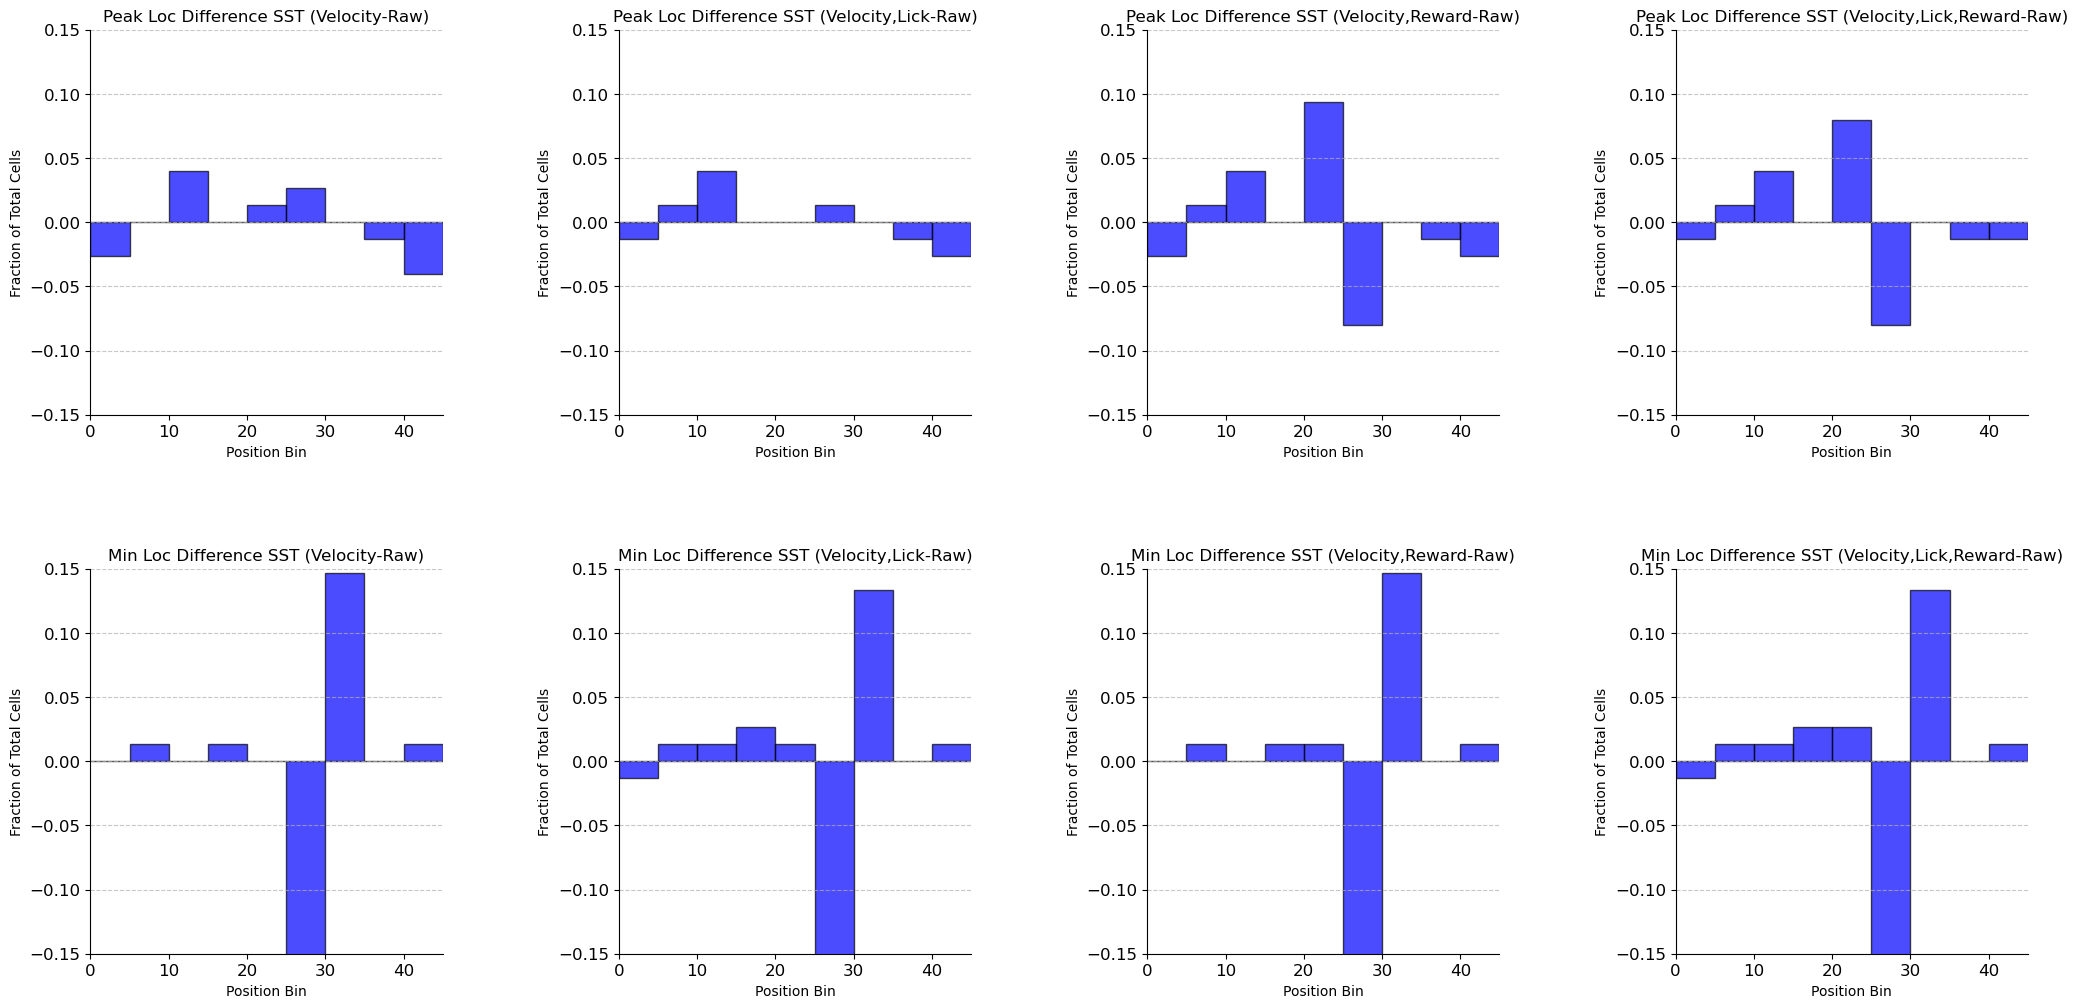

In [59]:
fig, axs = plt.subplots(2, 4, figsize=(25,12))

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.4, wspace=0.5)

# Unified bin settings for clarity
y_max = 0.15
x_min, x_max = 0, 45

# Plotting each subplot
titles = [
    "Peak Loc Difference SST (Velocity-Raw)", "Peak Loc Difference SST (Velocity,Lick-Raw)", "Peak Loc Difference SST (Velocity,Reward-Raw)", "Peak Loc Difference SST (Velocity,Lick,Reward-Raw)",
    
    "Min Loc Difference SST (Velocity-Raw)", "Min Loc Difference SST (Velocity,Lick-Raw)", "Min Loc Difference SST (Velocity,Reward-Raw)", "Min Loc Difference SST (Velocity,Lick,Reward-Raw)",
    
]

datasets = [
    peak_loc_difference_learning_list_SST_velocity, peak_loc_difference_learning_list_SST_vl, peak_loc_difference_learning_list_SST_vr, peak_loc_difference_learning_list_SST_vrl,
   
    Min_loc_difference_learning_list_SST_velocity, Min_loc_difference_learning_list_SST_vl, Min_loc_difference_learning_list_SST_vr, Min_loc_difference_learning_list_SST_vrl,
    
]

for ax, title, data in zip(axs.flat, titles, datasets):
    ax.bar(bin_centers, data, width=5, align='center', edgecolor='k', color='blue', alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-y_max, y_max)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Position Bin", fontsize=10)
    ax.set_ylabel("Fraction of Total Cells", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)


# Show the final plot
plt.show()


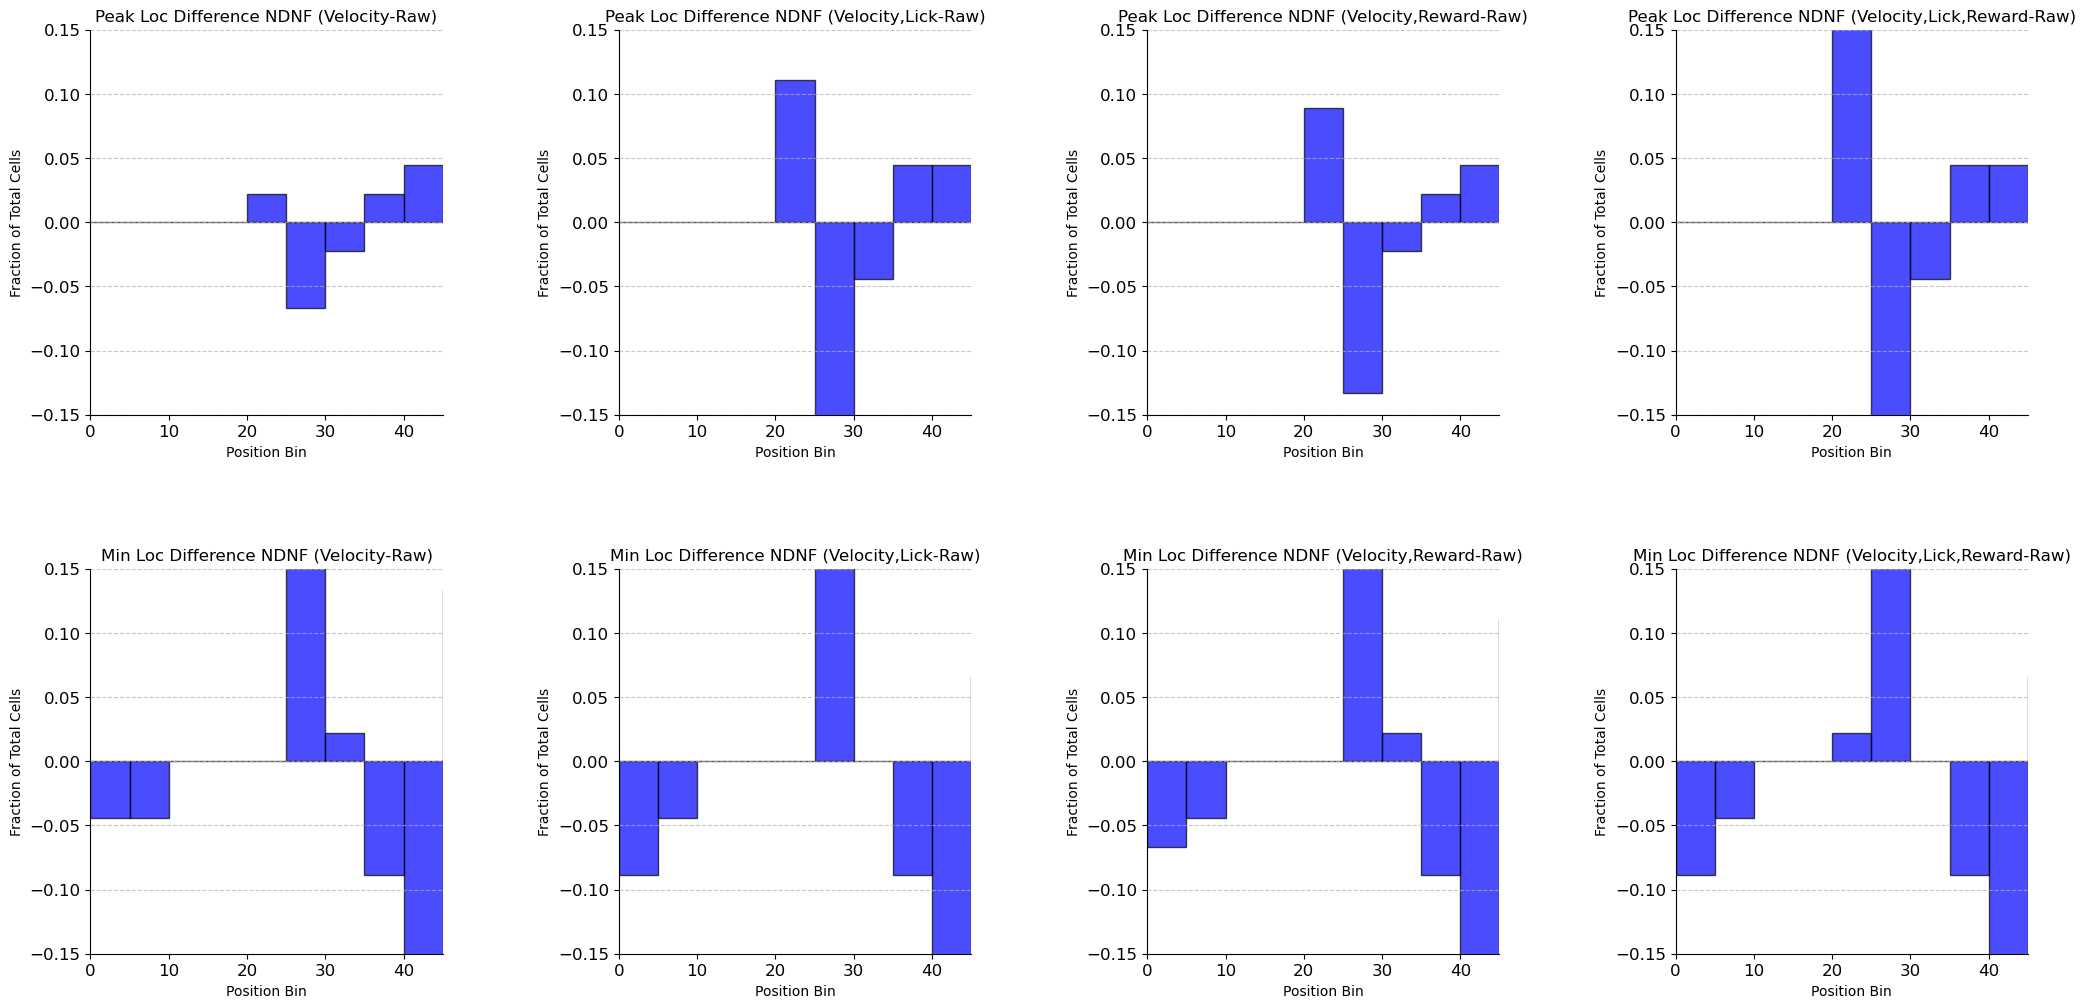

In [64]:
fig, axs = plt.subplots(2, 4, figsize=(25,12))

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.4, wspace=0.5)

# Unified bin settings for clarity
y_max = 0.15
x_min, x_max = 0, 45

# Plotting each subplot
titles = [
    "Peak Loc Difference NDNF (Velocity-Raw)", "Peak Loc Difference NDNF (Velocity,Lick-Raw)", "Peak Loc Difference NDNF (Velocity,Reward-Raw)", "Peak Loc Difference NDNF (Velocity,Lick,Reward-Raw)",
    
    "Min Loc Difference NDNF (Velocity-Raw)", "Min Loc Difference NDNF (Velocity,Lick-Raw)", "Min Loc Difference NDNF (Velocity,Reward-Raw)", "Min Loc Difference NDNF (Velocity,Lick,Reward-Raw)",
    
]

datasets = [
    peak_loc_difference_learning_list_NDNF_velocity, peak_loc_difference_learning_list_NDNF_vl, peak_loc_difference_learning_list_NDNF_vr, peak_loc_difference_learning_list_NDNF_vrl,
   
    Min_loc_difference_learning_list_NDNF_velocity, Min_loc_difference_learning_list_NDNF_vl, Min_loc_difference_learning_list_NDNF_vr, Min_loc_difference_learning_list_NDNF_vrl,
    
]

for ax, title, data in zip(axs.flat, titles, datasets):
    ax.bar(bin_centers, data, width=5, align='center', edgecolor='k', color='blue', alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-y_max, y_max)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Position Bin", fontsize=10)
    ax.set_ylabel("Fraction of Total Cells", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)


# Show the final plot
plt.show()


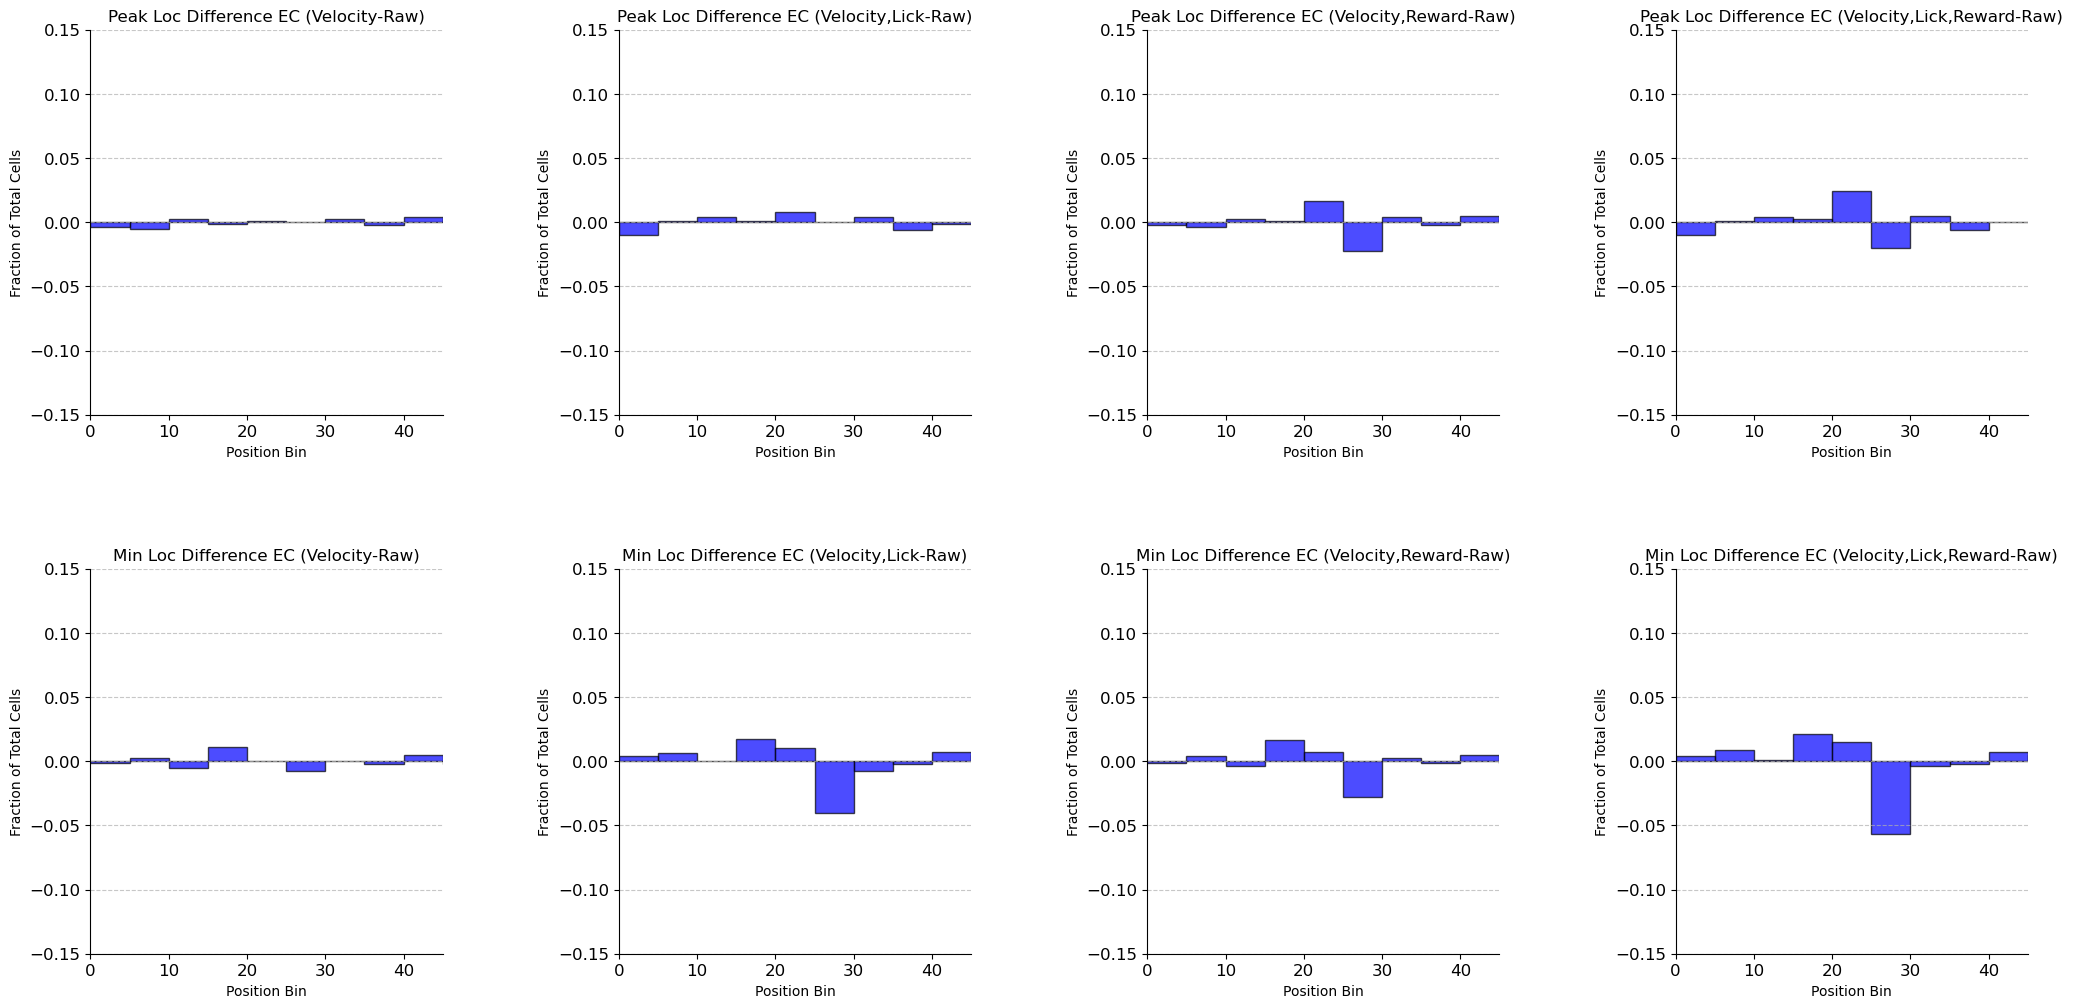

In [45]:
fig, axs = plt.subplots(2, 4, figsize=(25,12))

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.4, wspace=0.5)

# Unified bin settings for clarity
y_max = 0.15
x_min, x_max = 0, 45

# Plotting each subplot
titles = [
    "Peak Loc Difference EC (Velocity-Raw)", "Peak Loc Difference EC (Velocity,Lick-Raw)", "Peak Loc Difference EC (Velocity,Reward-Raw)", "Peak Loc Difference EC (Velocity,Lick,Reward-Raw)",
    
    "Min Loc Difference EC (Velocity-Raw)", "Min Loc Difference EC (Velocity,Lick-Raw)", "Min Loc Difference EC (Velocity,Reward-Raw)", "Min Loc Difference EC (Velocity,Lick,Reward-Raw)",
    
]

datasets = [
    peak_loc_difference_learning_list_EC_velocity, peak_loc_difference_learning_list_EC_vl, peak_loc_difference_learning_list_EC_vr, peak_loc_difference_learning_list_EC_vrl,
   
    Min_loc_difference_learning_list_EC_velocity, Min_loc_difference_learning_list_EC_vl, Min_loc_difference_learning_list_EC_vr, Min_loc_difference_learning_list_EC_vrl,
    
]

for ax, title, data in zip(axs.flat, titles, datasets):
    ax.bar(bin_centers, data, width=5, align='center', edgecolor='k', color='blue', alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-y_max, y_max)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Position Bin", fontsize=10)
    ax.set_ylabel("Fraction of Total Cells", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)


# Show the final plot
plt.show()


In [46]:
bin_size = 180/50
reward_loc = bin_size * 25

# trial_argmax_list_SST_first_quintile_cm = trial_argmax_list_SST_first_quintile.astype(float) * bin_size.astype

raw_argmax_list_SST_distance = []
for i in Argmax_list_raw_SST:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    raw_argmax_list_SST_distance.append(diff)
    

    
velocity_argmax_list_SST_distance = []
for i in argmax_list_SST_velocity:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    velocity_argmax_list_SST_distance.append(diff)
    
    
    
raw_argmin_list_SST_distance = []
for i in Argmin_list_raw_SST:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    raw_argmin_list_SST_distance.append(diff)
    

    
velocity_argmin_list_SST_distance = []
for i in argmin_list_SST_velocity:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    velocity_argmin_list_SST_distance.append(diff)
    
    
    

raw_argmax_list_NDNF_distance = []
for i in Argmax_list_raw_NDNF:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    raw_argmax_list_NDNF_distance.append(diff)
    

    
velocity_argmax_list_NDNF_distance = []
for i in argmax_list_NDNF_velocity:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    velocity_argmax_list_NDNF_distance.append(diff)
    
    
print(f"raw_argmax_list_EC_distance {raw_argmax_list_NDNF_distance}")
print(f"velocity_argmax_list_EC_distance {velocity_argmax_list_NDNF_distance}")

raw_argmin_list_NDNF_distance = []
for i in Argmin_list_raw_NDNF:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    raw_argmin_list_NDNF_distance.append(diff)
    

    
velocity_argmin_list_NDNF_distance = []
for i in argmin_list_NDNF_velocity:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    velocity_argmin_list_NDNF_distance.append(diff)
    
    
print(f"raw_argmin_list_EC_distance {raw_argmin_list_NDNF_distance}")
print(f"velocity_argmin_list_EC_distance {velocity_argmin_list_NDNF_distance}")



raw_argmax_list_EC_distance = []
for i in Argmax_list_raw_EC:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    raw_argmax_list_EC_distance.append(diff)
    

    
velocity_argmax_list_EC_distance = []
for i in argmax_list_EC_velocity:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    velocity_argmax_list_EC_distance.append(diff)
    
print(f"raw_argmax_list_EC_distance {len(raw_argmax_list_EC_distance)}")
print(f"velocity_argmax_list_EC_distance {len(velocity_argmax_list_EC_distance)}")
    
    

raw_argmin_list_EC_distance = []
for i in Argmin_list_raw_EC:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    raw_argmin_list_EC_distance.append(diff)
    

    
velocity_argmin_list_EC_distance = []
for i in argmin_list_EC_velocity:
    i_cm = i*bin_size
    diff = np.absolute(i - reward_loc)
    velocity_argmin_list_EC_distance.append(diff)
    
print(f"raw_argmin_list_EC_distance {len(raw_argmin_list_EC_distance)}")
print(f"velocity_argmin_list_EC_distance {len(velocity_argmin_list_EC_distance)}")


raw_argmax_list_EC_distance [68.0, 66.0, 66.0, 52.0, 50.0, 68.0, 68.0, 52.0, 66.0, 65.0, 83.0, 66.0, 54.0, 69.0, 64.0, 64.0, 65.0, 62.0, 69.0, 64.0, 64.0, 64.0, 70.0, 64.0, 47.0, 58.0, 64.0, 64.0, 58.0, 59.0, 58.0, 67.0, 58.0, 58.0, 63.0, 71.0, 64.0, 64.0, 63.0, 64.0, 61.0, 64.0, 64.0, 64.0, 64.0]
velocity_argmax_list_EC_distance [68.0, 66.0, 66.0, 52.0, 50.0, 68.0, 68.0, 52.0, 66.0, 65.0, 83.0, 66.0, 54.0, 69.0, 64.0, 69.0, 65.0, 62.0, 69.0, 64.0, 64.0, 64.0, 70.0, 64.0, 47.0, 58.0, 64.0, 64.0, 59.0, 59.0, 58.0, 64.0, 68.0, 58.0, 48.0, 71.0, 50.0, 65.0, 65.0, 64.0, 55.0, 65.0, 65.0, 64.0, 64.0]
raw_argmin_list_EC_distance [63.0, 63.0, 63.0, 64.0, 64.0, 64.0, 63.0, 44.0, 64.0, 61.0, 49.0, 58.0, 44.0, 64.0, 42.0, 47.0, 46.0, 68.0, 55.0, 58.0, 46.0, 47.0, 53.0, 47.0, 64.0, 88.0, 46.0, 46.0, 82.0, 89.0, 88.0, 56.0, 87.0, 84.0, 82.0, 60.0, 86.0, 46.0, 49.0, 51.0, 47.0, 46.0, 52.0, 45.0, 50.0]
velocity_argmin_list_EC_distance [63.0, 63.0, 63.0, 64.0, 64.0, 64.0, 63.0, 44.0, 64.0, 59.0, 49.0

Text(0.5, 92.0, 'P-value: 0.655')

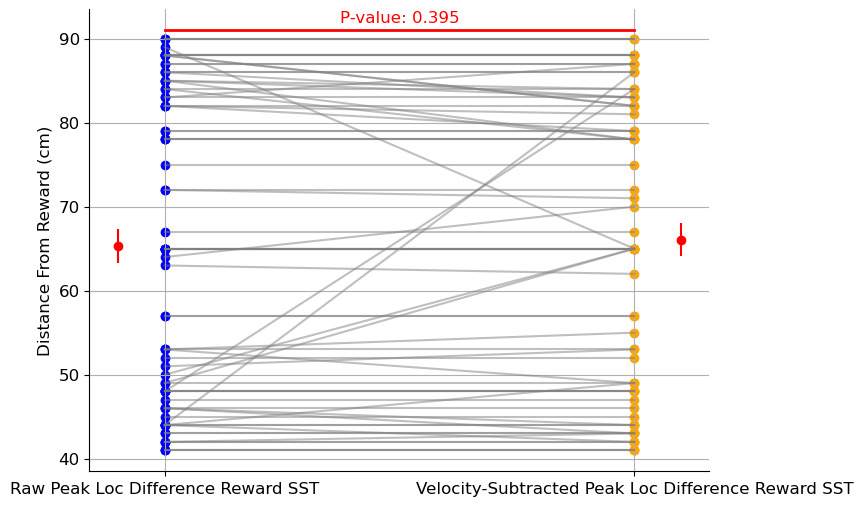

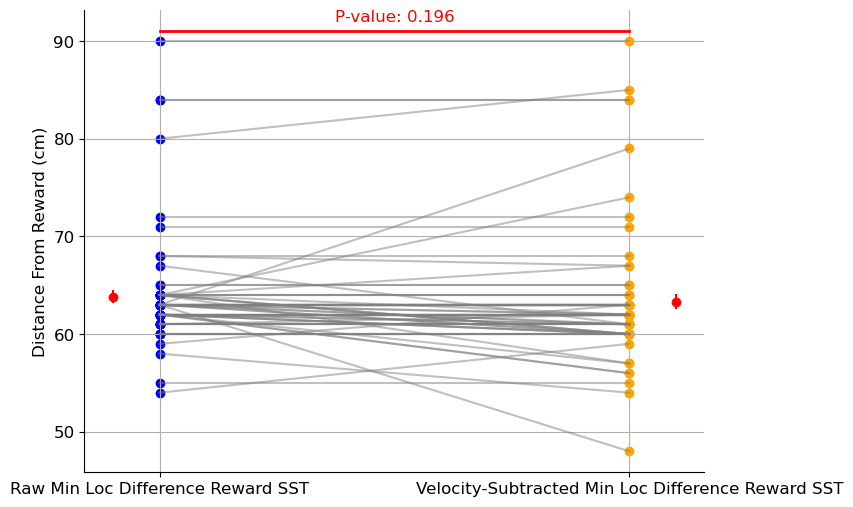

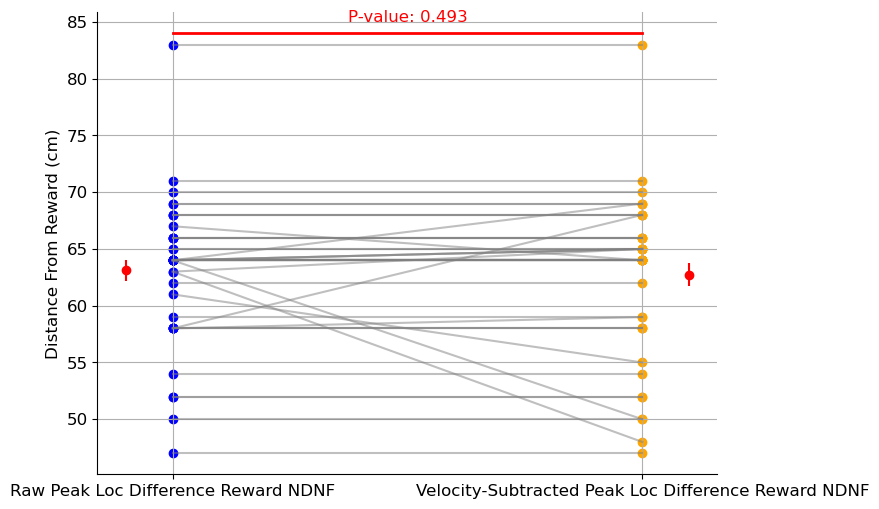

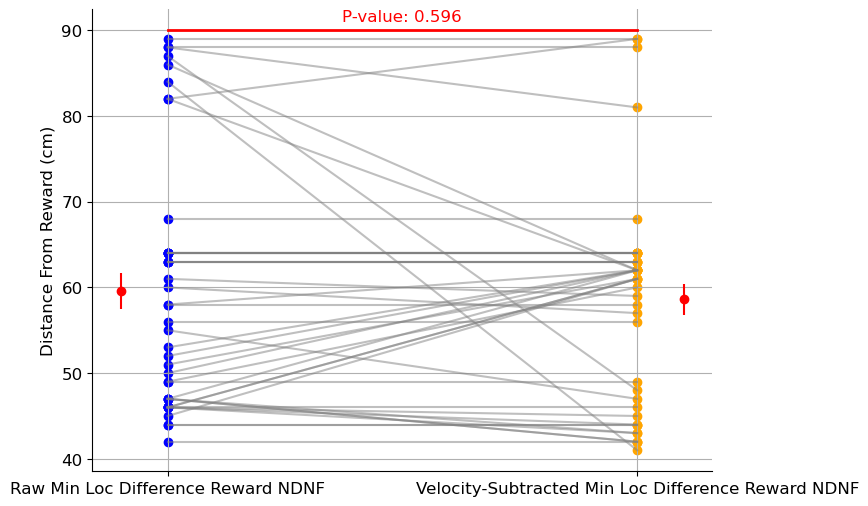

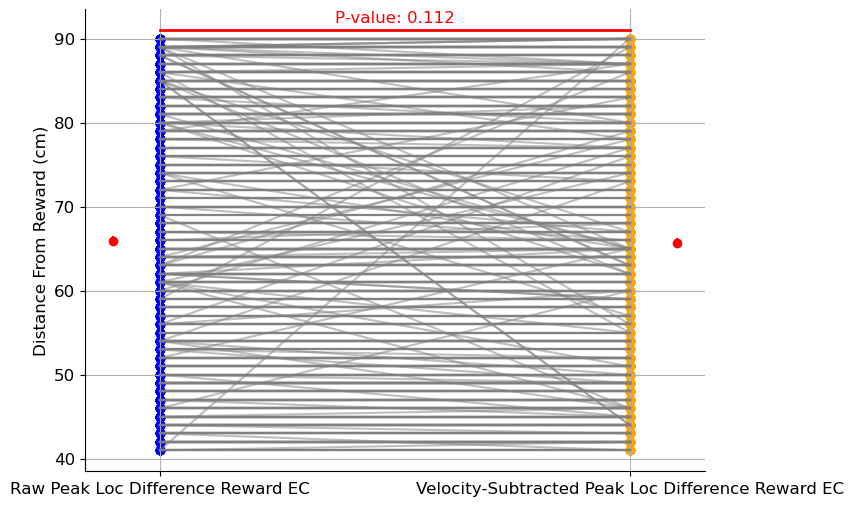

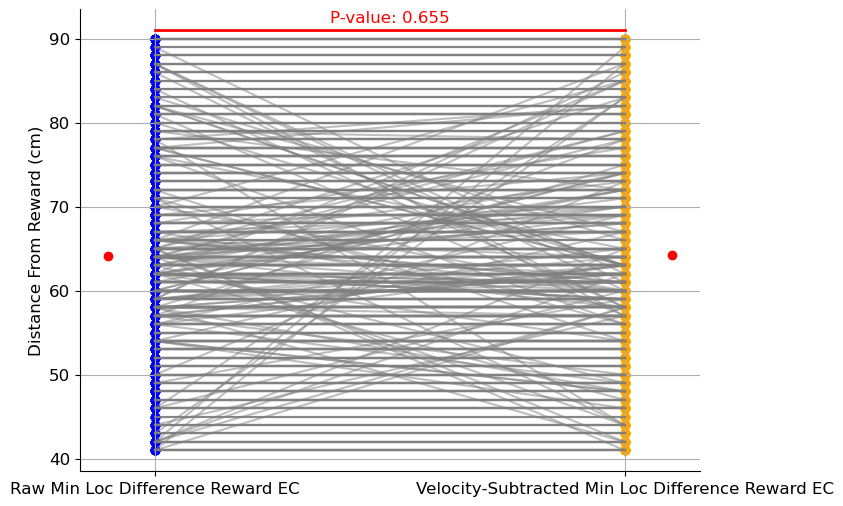

In [49]:



from scipy.stats import ttest_rel

t_stat, p_value_raw_velocity = ttest_rel(raw_argmax_list_SST_distance, velocity_argmax_list_SST_distance)
        
mean_raw = np.mean(velocity_argmax_list_SST_distance)
mean_velocity = np.mean(raw_argmax_list_SST_distance)

sem_raw = np.std(velocity_argmax_list_SST_distance) / np.sqrt(len(velocity_argmax_list_SST_distance))
sem_velocity = np.std(raw_argmax_list_SST_distance) / np.sqrt(len(raw_argmax_list_SST_distance))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Peak Loc Difference Reward SST", "Velocity-Subtracted Peak Loc Difference Reward SST"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red'

)

for i in range(len(velocity_argmax_list_SST_distance)):
    plt.plot(x_positions, [raw_argmax_list_SST_distance[i], velocity_argmax_list_SST_distance[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(raw_argmax_list_SST_distance), raw_argmax_list_SST_distance, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(velocity_argmax_list_SST_distance), velocity_argmax_list_SST_distance, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Distance From Reward (cm)')

# Display p-value with a red line
y_min = max(max(raw_argmax_list_SST_distance), max(velocity_argmax_list_SST_distance))
plt.plot([x_positions[0], x_positions[1]], [y_min + 1, y_min + 1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 2, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')


from scipy.stats import ttest_rel

t_stat, p_value_raw_velocity = ttest_rel(raw_argmin_list_SST_distance, velocity_argmin_list_SST_distance)
        
mean_raw = np.mean(velocity_argmin_list_SST_distance)
mean_velocity = np.mean(raw_argmin_list_SST_distance)

sem_raw = np.std(velocity_argmin_list_SST_distance) / np.sqrt(len(velocity_argmin_list_SST_distance))
sem_velocity = np.std(raw_argmin_list_SST_distance) / np.sqrt(len(raw_argmin_list_SST_distance))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Min Loc Difference Reward SST", "Velocity-Subtracted Min Loc Difference Reward SST"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red'

)

for i in range(len(velocity_argmin_list_SST_distance)):
    plt.plot(x_positions, [raw_argmin_list_SST_distance[i], velocity_argmin_list_SST_distance[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(raw_argmin_list_SST_distance), raw_argmin_list_SST_distance, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(velocity_argmin_list_SST_distance), velocity_argmin_list_SST_distance, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Distance From Reward (cm)')

# Display p-value with a red line
y_min = max(max(raw_argmin_list_SST_distance), max(velocity_argmin_list_SST_distance))
plt.plot([x_positions[0], x_positions[1]], [y_min + 1, y_min + 1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 2, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')











from scipy.stats import ttest_rel

t_stat, p_value_raw_velocity = ttest_rel(raw_argmax_list_NDNF_distance, velocity_argmax_list_NDNF_distance)
        
mean_raw = np.mean(velocity_argmax_list_NDNF_distance)
mean_velocity = np.mean(raw_argmax_list_NDNF_distance)

sem_raw = np.std(velocity_argmax_list_NDNF_distance) / np.sqrt(len(velocity_argmax_list_NDNF_distance))
sem_velocity = np.std(raw_argmax_list_NDNF_distance) / np.sqrt(len(raw_argmax_list_NDNF_distance))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Peak Loc Difference Reward NDNF", "Velocity-Subtracted Peak Loc Difference Reward NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red'

)

for i in range(len(velocity_argmax_list_NDNF_distance)):
    plt.plot(x_positions, [raw_argmax_list_NDNF_distance[i], velocity_argmax_list_NDNF_distance[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(raw_argmax_list_NDNF_distance), raw_argmax_list_NDNF_distance, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(velocity_argmax_list_NDNF_distance), velocity_argmax_list_NDNF_distance, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Distance From Reward (cm)')

# Display p-value with a red line
y_min = max(max(raw_argmax_list_NDNF_distance), max(velocity_argmax_list_NDNF_distance))
plt.plot([x_positions[0], x_positions[1]], [y_min + 1, y_min + 1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 2, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')


from scipy.stats import ttest_rel

t_stat, p_value_raw_velocity = ttest_rel(raw_argmin_list_NDNF_distance, velocity_argmin_list_NDNF_distance)
        
mean_raw = np.mean(velocity_argmin_list_NDNF_distance)
mean_velocity = np.mean(raw_argmin_list_NDNF_distance)

sem_raw = np.std(velocity_argmin_list_NDNF_distance) / np.sqrt(len(velocity_argmin_list_NDNF_distance))
sem_velocity = np.std(raw_argmin_list_NDNF_distance) / np.sqrt(len(raw_argmin_list_NDNF_distance))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Min Loc Difference Reward NDNF", "Velocity-Subtracted Min Loc Difference Reward NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red'

)

for i in range(len(velocity_argmin_list_NDNF_distance)):
    plt.plot(x_positions, [raw_argmin_list_NDNF_distance[i], velocity_argmin_list_NDNF_distance[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(raw_argmin_list_NDNF_distance), raw_argmin_list_NDNF_distance, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(velocity_argmin_list_NDNF_distance), velocity_argmin_list_NDNF_distance, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Distance From Reward (cm)')

# Display p-value with a red line
y_min = max(max(raw_argmin_list_NDNF_distance), max(velocity_argmin_list_NDNF_distance))
plt.plot([x_positions[0], x_positions[1]], [y_min + 1, y_min + 1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 2, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')










from scipy.stats import ttest_rel

t_stat, p_value_raw_velocity = ttest_rel(raw_argmax_list_EC_distance, velocity_argmax_list_EC_distance)
        
mean_raw = np.mean(velocity_argmax_list_EC_distance)
mean_velocity = np.mean(raw_argmax_list_EC_distance)

sem_raw = np.std(velocity_argmax_list_EC_distance) / np.sqrt(len(velocity_argmax_list_EC_distance))
sem_velocity = np.std(raw_argmax_list_EC_distance) / np.sqrt(len(raw_argmax_list_EC_distance))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Peak Loc Difference Reward EC", "Velocity-Subtracted Peak Loc Difference Reward EC"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red'

)

for i in range(len(velocity_argmax_list_EC_distance)):
    plt.plot(x_positions, [raw_argmax_list_EC_distance[i], velocity_argmax_list_EC_distance[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(raw_argmax_list_EC_distance), raw_argmax_list_EC_distance, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(velocity_argmax_list_EC_distance), velocity_argmax_list_EC_distance, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Distance From Reward (cm)')

# Display p-value with a red line
y_min = max(max(raw_argmax_list_EC_distance), max(velocity_argmax_list_EC_distance))
plt.plot([x_positions[0], x_positions[1]], [y_min + 1, y_min + 1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 2, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')


from scipy.stats import ttest_rel

t_stat, p_value_raw_velocity = ttest_rel(raw_argmin_list_EC_distance, velocity_argmin_list_EC_distance)
        
mean_raw = np.mean(velocity_argmin_list_EC_distance)
mean_velocity = np.mean(raw_argmin_list_EC_distance)

sem_raw = np.std(velocity_argmin_list_EC_distance) / np.sqrt(len(velocity_argmin_list_EC_distance))
sem_velocity = np.std(raw_argmin_list_EC_distance) / np.sqrt(len(raw_argmin_list_EC_distance))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Min Loc Difference Reward EC", "Velocity-Subtracted Min Loc Difference Reward EC"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red'

)

for i in range(len(velocity_argmin_list_EC_distance)):
    plt.plot(x_positions, [raw_argmin_list_EC_distance[i], velocity_argmin_list_EC_distance[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(raw_argmin_list_EC_distance), raw_argmin_list_EC_distance, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(velocity_argmin_list_EC_distance), velocity_argmin_list_EC_distance, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Distance From Reward (cm)')

# Display p-value with a red line
y_min = max(max(raw_argmin_list_EC_distance), max(velocity_argmin_list_EC_distance))
plt.plot([x_positions[0], x_positions[1]], [y_min + 1, y_min + 1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 2, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')













In [ ]:


from scipy.stats import ttest_rel

t_stat, p_value_raw_velocity = ttest_rel(raw_argmax_list_NDNF_distance, velocity_argmax_list_NDNF_distance)
        
mean_raw = np.mean(velocity_argmax_list_NDNF_distance)
mean_velocity = np.mean(raw_argmax_list_NDNF_distance)

sem_raw = np.std(velocity_argmax_list_NDNF_distance) / np.sqrt(len(velocity_argmax_list_NDNF_distance))
sem_velocity = np.std(raw_argmax_list_NDNF_distance) / np.sqrt(len(raw_argmax_list_NDNF_distance))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Peak Loc Difference Reward", "Velocity-Subtracted Peak Loc Difference Reward"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red'

)

for i in range(len(velocity_argmax_list_NDNF_distance)):
    plt.plot(x_positions, [raw_argmax_list_NDNF_distance[i], velocity_argmax_list_NDNF_distance[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(raw_argmax_list_NDNF_distance), raw_argmax_list_NDNF_distance, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(velocity_argmax_list_NDNF_distance), velocity_argmax_list_NDNF_distance, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(raw_argmax_list_NDNF_distance), max(velocity_argmax_list_NDNF_distance))
plt.plot([x_positions[0], x_positions[1]], [y_min + 1, y_min + 1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 2, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')


from scipy.stats import ttest_rel

t_stat, p_value_raw_velocity = ttest_rel(raw_argmin_list_NDNF_distance, velocity_argmin_list_NDNF_distance)
        
mean_raw = np.mean(velocity_argmin_list_NDNF_distance)
mean_velocity = np.mean(raw_argmin_list_NDNF_distance)

sem_raw = np.std(velocity_argmin_list_NDNF_distance) / np.sqrt(len(velocity_argmin_list_NDNF_distance))
sem_velocity = np.std(raw_argmin_list_NDNF_distance) / np.sqrt(len(raw_argmin_list_NDNF_distance))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Peak Loc Difference Reward", "Velocity-Subtracted Peak Loc Difference Reward"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red'

)

for i in range(len(velocity_argmin_list_NDNF_distance)):
    plt.plot(x_positions, [raw_argmin_list_NDNF_distance[i], velocity_argmin_list_NDNF_distance[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(raw_argmin_list_NDNF_distance), raw_argmin_list_NDNF_distance, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(velocity_argmin_list_NDNF_distance), velocity_argmin_list_NDNF_distance, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(raw_argmin_list_NDNF_distance), max(velocity_argmin_list_NDNF_distance))
plt.plot([x_positions[0], x_positions[1]], [y_min + 1, y_min + 1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 2, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')

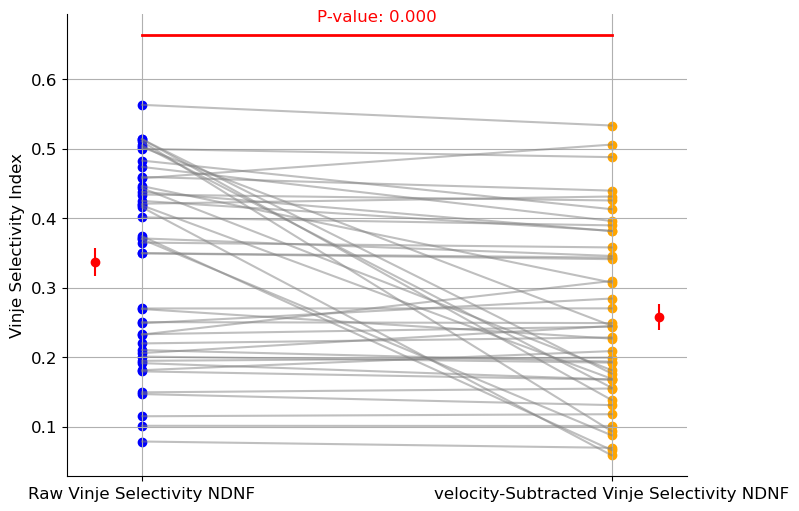

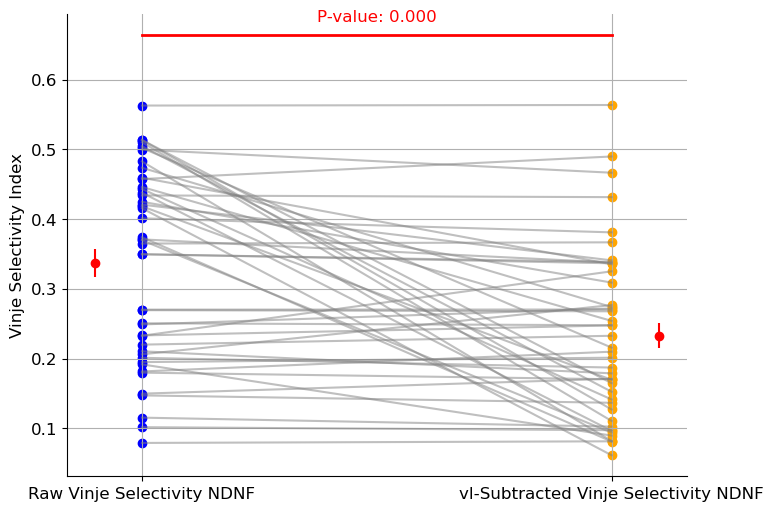

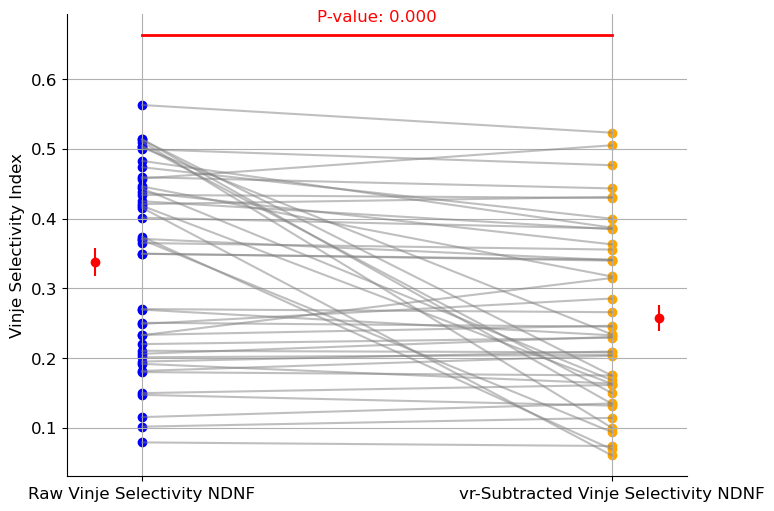

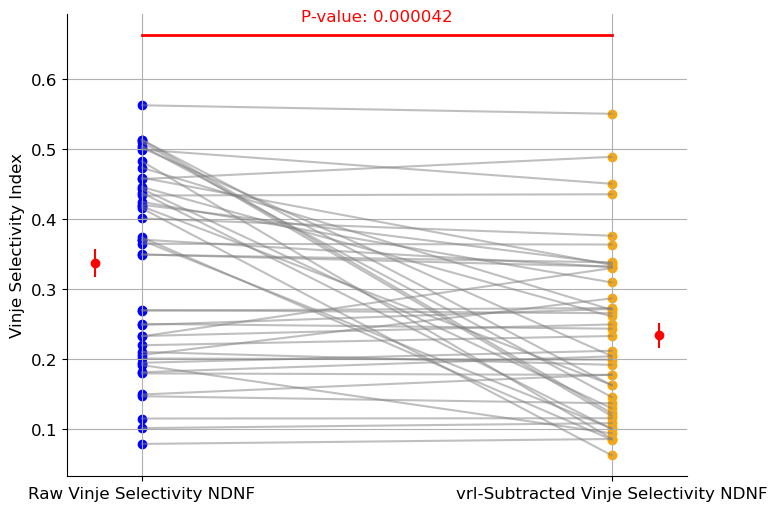

In [35]:

from scipy.stats import ttest_rel


t_stat, p_value_raw_velocity = ttest_rel(selectivity_NDNF_velocity, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_velocity = np.mean(selectivity_NDNF_velocity)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_velocity = np.std(selectivity_NDNF_velocity) / np.sqrt(len(selectivity_NDNF_velocity))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "velocity-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_velocity[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_velocity), selectivity_NDNF_velocity, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_velocity))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')





plt.show()

t_stat, p_value_raw_vl = ttest_rel(selectivity_NDNF_vl, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vl = np.mean(selectivity_NDNF_vl)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vl = np.std(selectivity_NDNF_vl) / np.sqrt(len(selectivity_NDNF_vl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vl-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vl, yerr=sem_vl, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vl), selectivity_NDNF_vl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vl:.3f}", ha='center', color='red')




t_stat, p_value_raw_vr = ttest_rel(selectivity_NDNF_vr, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vr = np.mean(selectivity_NDNF_vr)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vr = np.std(selectivity_NDNF_vr) / np.sqrt(len(selectivity_NDNF_vr))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vr-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vr, yerr=sem_vr, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vr[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vr), selectivity_NDNF_vr, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vr))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vr:.3f}", ha='center', color='red')



t_stat, p_value_raw_vrl = ttest_rel(selectivity_NDNF_vrl, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vrl = np.mean(selectivity_NDNF_vrl)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vrl = np.std(selectivity_NDNF_vrl) / np.sqrt(len(selectivity_NDNF_vrl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vrl-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vrl, yerr=sem_vrl, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vrl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vrl), selectivity_NDNF_vrl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vrl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vrl:.6f}", ha='center', color='red')





plt.show()


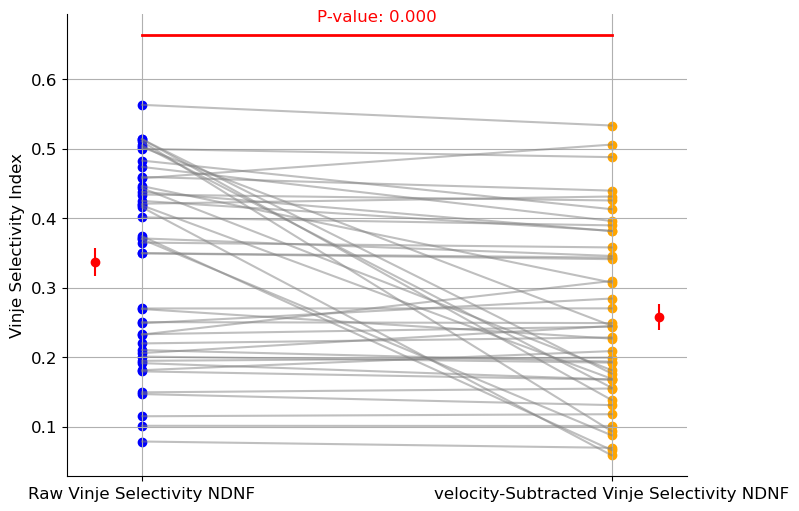

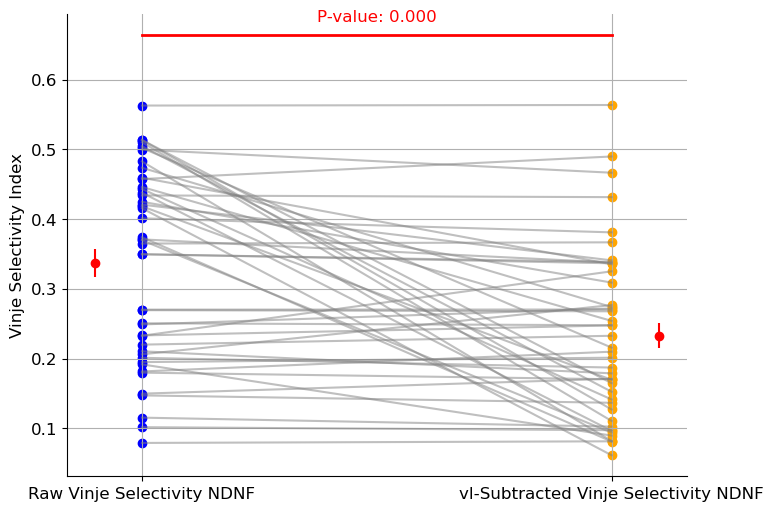

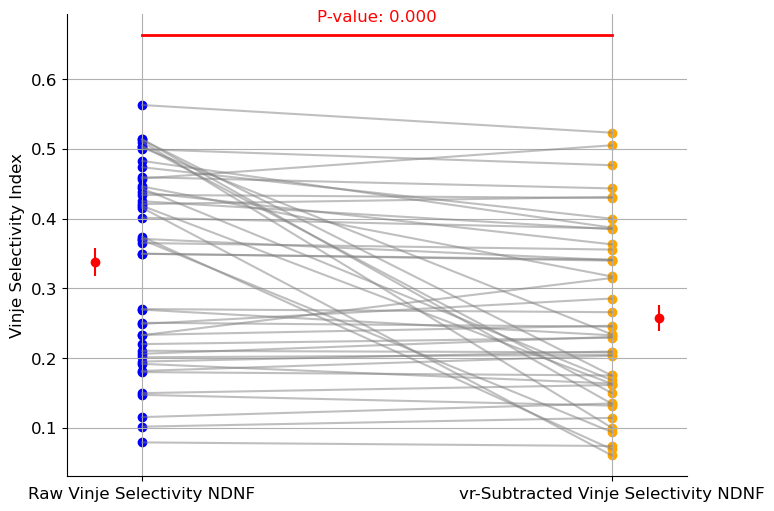

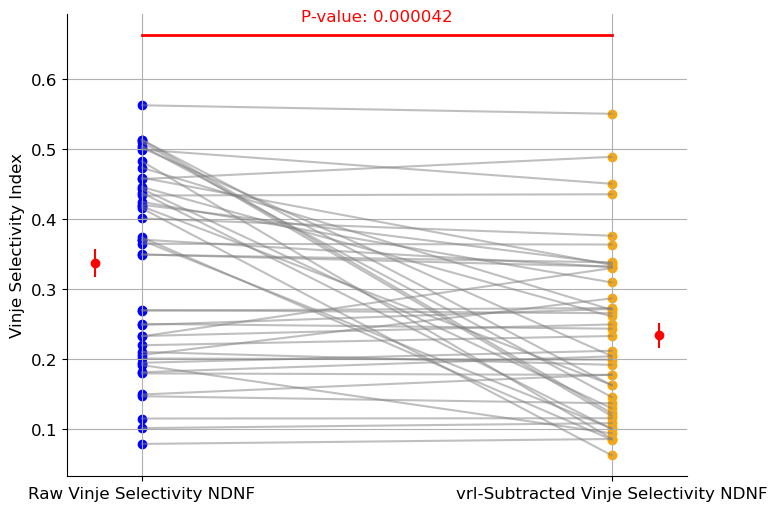

In [35]:

from scipy.stats import ttest_rel


t_stat, p_value_raw_velocity = ttest_rel(selectivity_NDNF_velocity, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_velocity = np.mean(selectivity_NDNF_velocity)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_velocity = np.std(selectivity_NDNF_velocity) / np.sqrt(len(selectivity_NDNF_velocity))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "velocity-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_velocity[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_velocity), selectivity_NDNF_velocity, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_velocity))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')





plt.show()

t_stat, p_value_raw_vl = ttest_rel(selectivity_NDNF_vl, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vl = np.mean(selectivity_NDNF_vl)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vl = np.std(selectivity_NDNF_vl) / np.sqrt(len(selectivity_NDNF_vl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vl-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vl, yerr=sem_vl, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vl), selectivity_NDNF_vl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vl:.3f}", ha='center', color='red')




t_stat, p_value_raw_vr = ttest_rel(selectivity_NDNF_vr, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vr = np.mean(selectivity_NDNF_vr)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vr = np.std(selectivity_NDNF_vr) / np.sqrt(len(selectivity_NDNF_vr))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vr-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vr, yerr=sem_vr, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vr[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vr), selectivity_NDNF_vr, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vr))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vr:.3f}", ha='center', color='red')



t_stat, p_value_raw_vrl = ttest_rel(selectivity_NDNF_vrl, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vrl = np.mean(selectivity_NDNF_vrl)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vrl = np.std(selectivity_NDNF_vrl) / np.sqrt(len(selectivity_NDNF_vrl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vrl-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vrl, yerr=sem_vrl, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vrl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vrl), selectivity_NDNF_vrl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vrl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vrl:.6f}", ha='center', color='red')





plt.show()


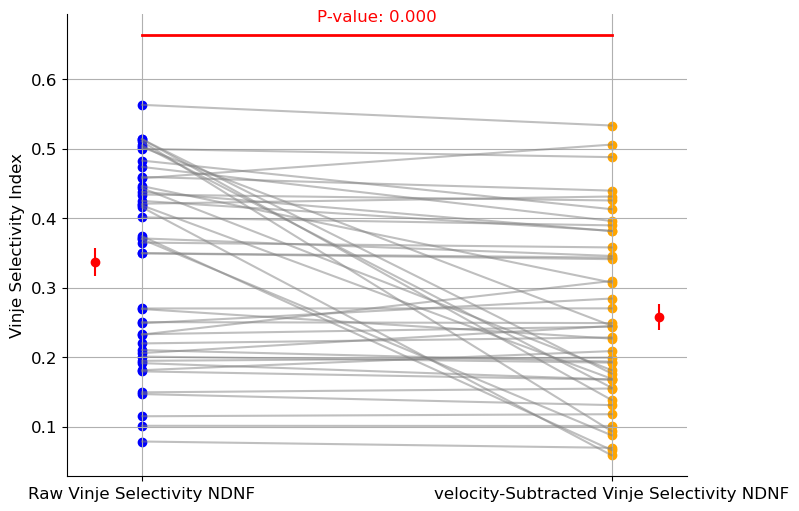

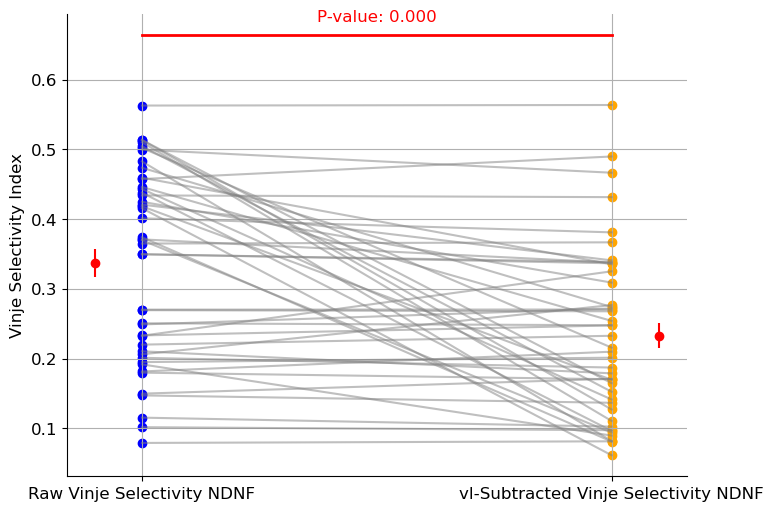

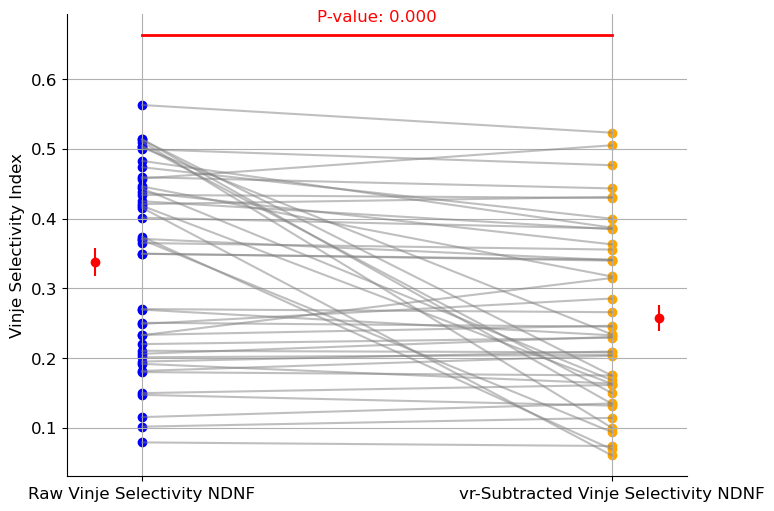

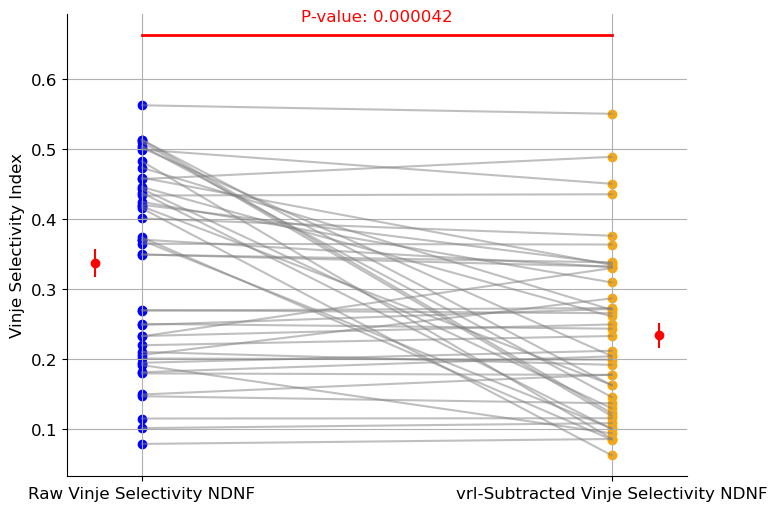

In [35]:

from scipy.stats import ttest_rel


t_stat, p_value_raw_velocity = ttest_rel(selectivity_NDNF_velocity, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_velocity = np.mean(selectivity_NDNF_velocity)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_velocity = np.std(selectivity_NDNF_velocity) / np.sqrt(len(selectivity_NDNF_velocity))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "velocity-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_velocity[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_velocity), selectivity_NDNF_velocity, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_velocity))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')





plt.show()

t_stat, p_value_raw_vl = ttest_rel(selectivity_NDNF_vl, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vl = np.mean(selectivity_NDNF_vl)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vl = np.std(selectivity_NDNF_vl) / np.sqrt(len(selectivity_NDNF_vl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vl-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vl, yerr=sem_vl, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vl), selectivity_NDNF_vl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vl:.3f}", ha='center', color='red')




t_stat, p_value_raw_vr = ttest_rel(selectivity_NDNF_vr, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vr = np.mean(selectivity_NDNF_vr)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vr = np.std(selectivity_NDNF_vr) / np.sqrt(len(selectivity_NDNF_vr))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vr-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vr, yerr=sem_vr, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vr[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vr), selectivity_NDNF_vr, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vr))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vr:.3f}", ha='center', color='red')



t_stat, p_value_raw_vrl = ttest_rel(selectivity_NDNF_vrl, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vrl = np.mean(selectivity_NDNF_vrl)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vrl = np.std(selectivity_NDNF_vrl) / np.sqrt(len(selectivity_NDNF_vrl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vrl-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vrl, yerr=sem_vrl, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vrl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vrl), selectivity_NDNF_vrl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vrl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vrl:.6f}", ha='center', color='red')





plt.show()


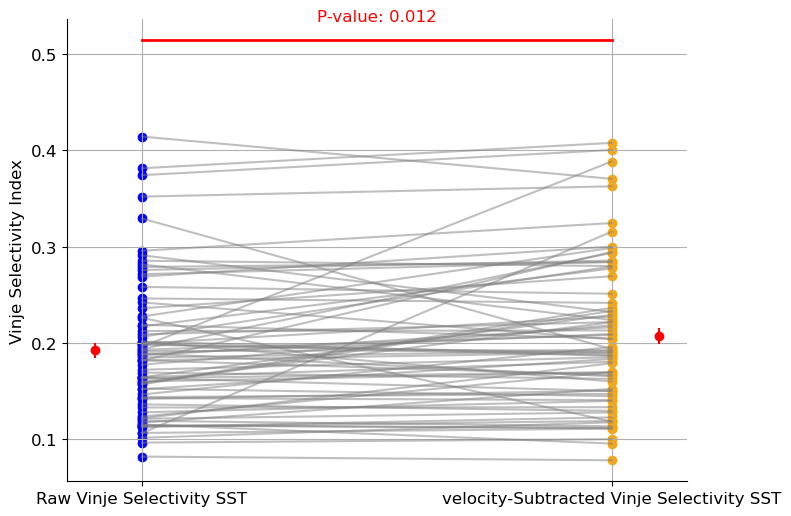

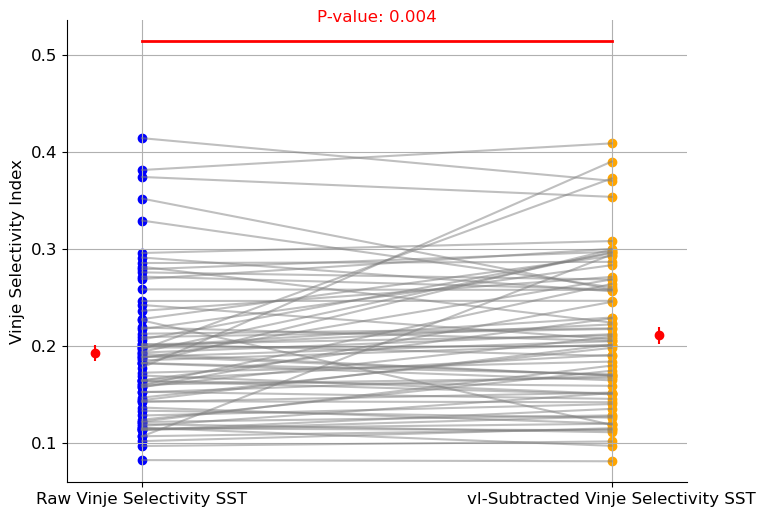

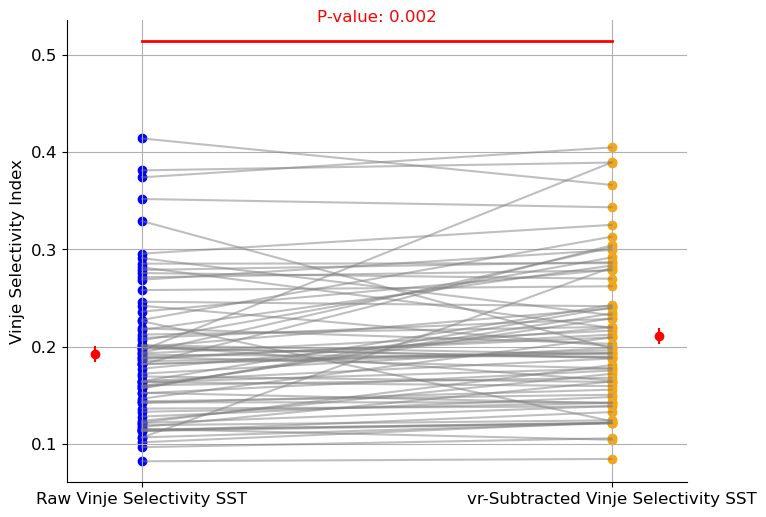

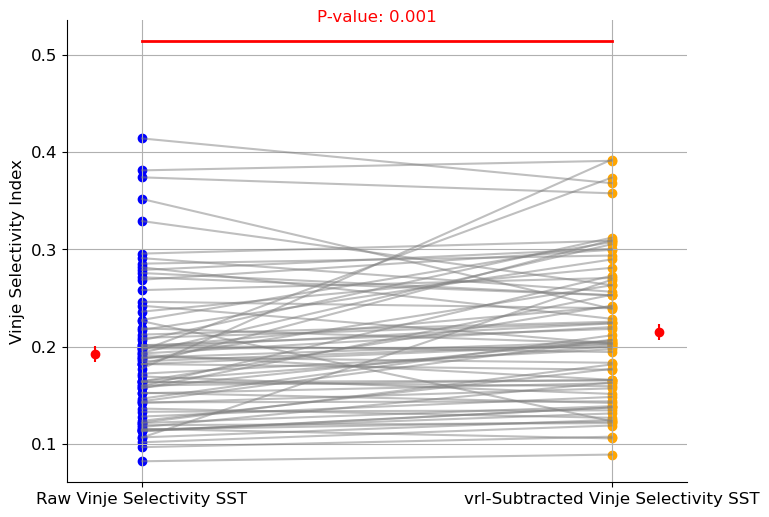

In [33]:

from scipy.stats import ttest_rel


t_stat, p_value_raw_velocity = ttest_rel(selectivity_SST_velocity, SST_raw_selectivity)
        
mean_raw = np.mean(SST_raw_selectivity)
mean_velocity = np.mean(selectivity_SST_velocity)

sem_raw = np.std(SST_raw_selectivity) / np.sqrt(len(SST_raw_selectivity))
sem_velocity = np.std(selectivity_SST_velocity) / np.sqrt(len(selectivity_SST_velocity))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity SST", "velocity-Subtracted Vinje Selectivity SST"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red'
)


for i in range(len(SST_raw_selectivity)):
    plt.plot(x_positions, [SST_raw_selectivity[i], selectivity_SST_velocity[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(SST_raw_selectivity), SST_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_SST_velocity), selectivity_SST_velocity, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(SST_raw_selectivity), max(selectivity_SST_velocity))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')





plt.show()

t_stat, p_value_raw_vl = ttest_rel(selectivity_SST_vl, SST_raw_selectivity)
        
mean_raw = np.mean(SST_raw_selectivity)
mean_vl = np.mean(selectivity_SST_vl)

sem_raw = np.std(SST_raw_selectivity) / np.sqrt(len(SST_raw_selectivity))
sem_vl = np.std(selectivity_SST_vl) / np.sqrt(len(selectivity_SST_vl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity SST", "vl-Subtracted Vinje Selectivity SST"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vl, yerr=sem_vl, fmt='o', color='red'
)


for i in range(len(SST_raw_selectivity)):
    plt.plot(x_positions, [SST_raw_selectivity[i], selectivity_SST_vl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(SST_raw_selectivity), SST_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_SST_vl), selectivity_SST_vl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(SST_raw_selectivity), max(selectivity_SST_vl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vl:.3f}", ha='center', color='red')




t_stat, p_value_raw_vr = ttest_rel(selectivity_SST_vr, SST_raw_selectivity)
        
mean_raw = np.mean(SST_raw_selectivity)
mean_vr = np.mean(selectivity_SST_vr)

sem_raw = np.std(SST_raw_selectivity) / np.sqrt(len(SST_raw_selectivity))
sem_vr = np.std(selectivity_SST_vr) / np.sqrt(len(selectivity_SST_vr))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity SST", "vr-Subtracted Vinje Selectivity SST"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vr, yerr=sem_vr, fmt='o', color='red'
)


for i in range(len(SST_raw_selectivity)):
    plt.plot(x_positions, [SST_raw_selectivity[i], selectivity_SST_vr[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(SST_raw_selectivity), SST_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_SST_vr), selectivity_SST_vr, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(SST_raw_selectivity), max(selectivity_SST_vr))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vr:.3f}", ha='center', color='red')



t_stat, p_value_raw_vrl = ttest_rel(selectivity_SST_vrl, SST_raw_selectivity)
        
mean_raw = np.mean(SST_raw_selectivity)
mean_vrl = np.mean(selectivity_SST_vrl)

sem_raw = np.std(SST_raw_selectivity) / np.sqrt(len(SST_raw_selectivity))
sem_vrl = np.std(selectivity_SST_vrl) / np.sqrt(len(selectivity_SST_vrl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity SST", "vrl-Subtracted Vinje Selectivity SST"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vrl, yerr=sem_vrl, fmt='o', color='red'
)


for i in range(len(SST_raw_selectivity)):
    plt.plot(x_positions, [SST_raw_selectivity[i], selectivity_SST_vrl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(SST_raw_selectivity), SST_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_SST_vrl), selectivity_SST_vrl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(SST_raw_selectivity), max(selectivity_SST_vrl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vrl:.3f}", ha='center', color='red')





plt.show()


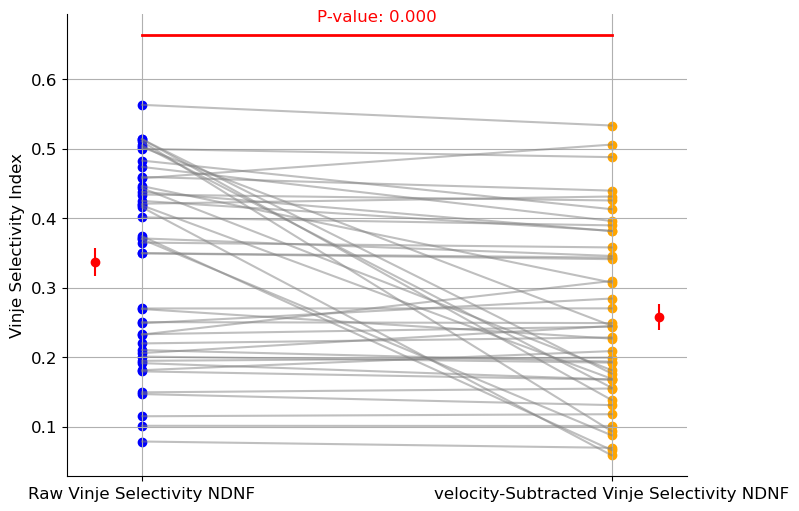

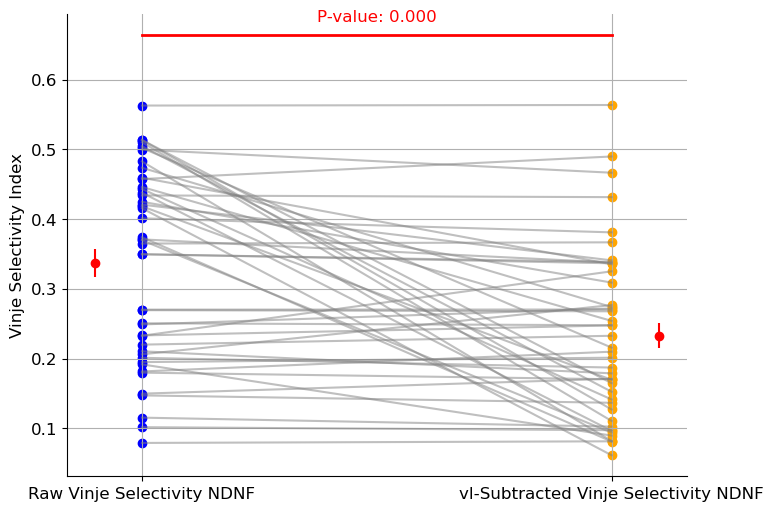

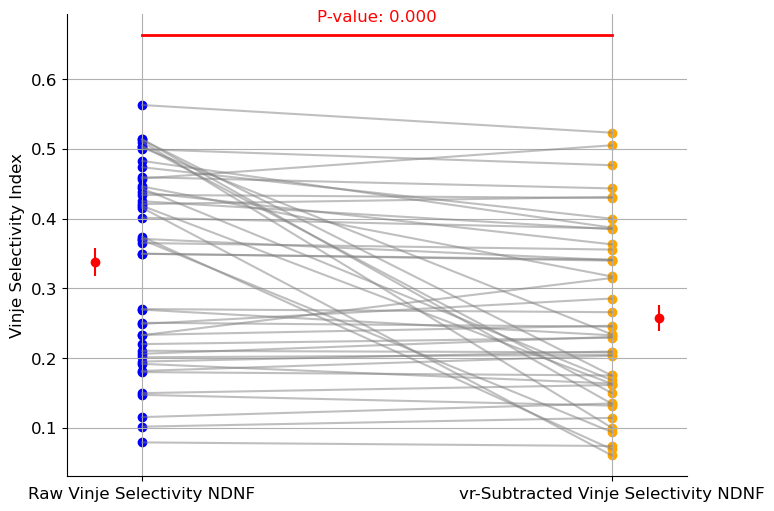

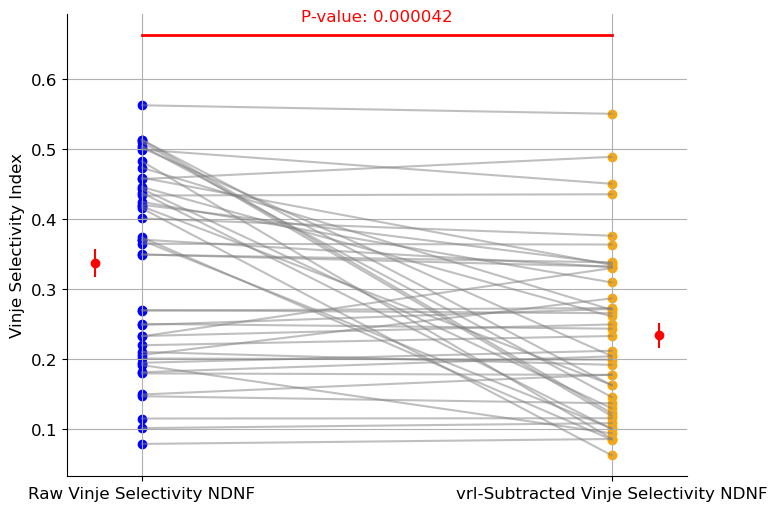

In [35]:

from scipy.stats import ttest_rel


t_stat, p_value_raw_velocity = ttest_rel(selectivity_NDNF_velocity, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_velocity = np.mean(selectivity_NDNF_velocity)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_velocity = np.std(selectivity_NDNF_velocity) / np.sqrt(len(selectivity_NDNF_velocity))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "velocity-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_velocity[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_velocity), selectivity_NDNF_velocity, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_velocity))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')





plt.show()

t_stat, p_value_raw_vl = ttest_rel(selectivity_NDNF_vl, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vl = np.mean(selectivity_NDNF_vl)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vl = np.std(selectivity_NDNF_vl) / np.sqrt(len(selectivity_NDNF_vl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vl-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vl, yerr=sem_vl, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vl), selectivity_NDNF_vl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vl:.3f}", ha='center', color='red')




t_stat, p_value_raw_vr = ttest_rel(selectivity_NDNF_vr, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vr = np.mean(selectivity_NDNF_vr)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vr = np.std(selectivity_NDNF_vr) / np.sqrt(len(selectivity_NDNF_vr))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vr-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vr, yerr=sem_vr, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vr[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vr), selectivity_NDNF_vr, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vr))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vr:.3f}", ha='center', color='red')



t_stat, p_value_raw_vrl = ttest_rel(selectivity_NDNF_vrl, NDNF_raw_selectivity)
        
mean_raw = np.mean(NDNF_raw_selectivity)
mean_vrl = np.mean(selectivity_NDNF_vrl)

sem_raw = np.std(NDNF_raw_selectivity) / np.sqrt(len(NDNF_raw_selectivity))
sem_vrl = np.std(selectivity_NDNF_vrl) / np.sqrt(len(selectivity_NDNF_vrl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity NDNF", "vrl-Subtracted Vinje Selectivity NDNF"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vrl, yerr=sem_vrl, fmt='o', color='red'
)


for i in range(len(NDNF_raw_selectivity)):
    plt.plot(x_positions, [NDNF_raw_selectivity[i], selectivity_NDNF_vrl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(NDNF_raw_selectivity), NDNF_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_NDNF_vrl), selectivity_NDNF_vrl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(NDNF_raw_selectivity), max(selectivity_NDNF_vrl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vrl:.6f}", ha='center', color='red')





plt.show()


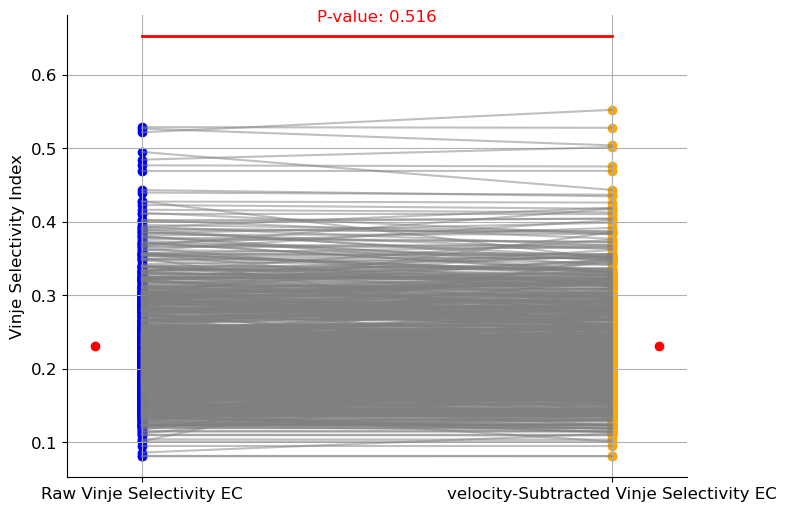

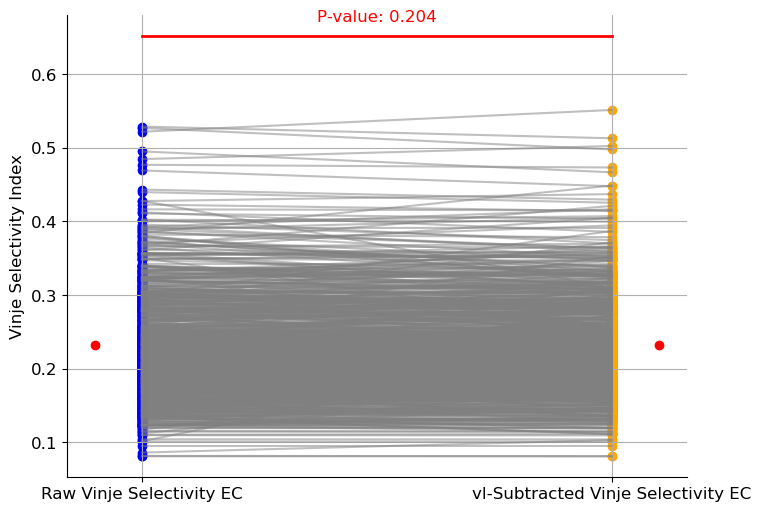

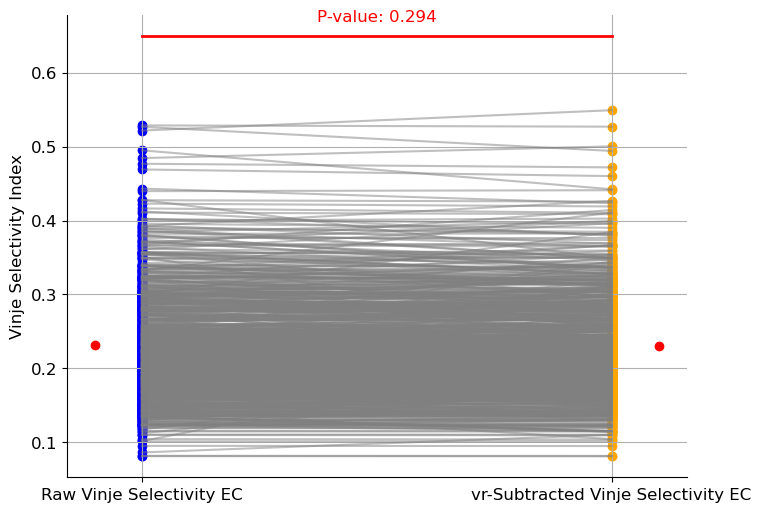

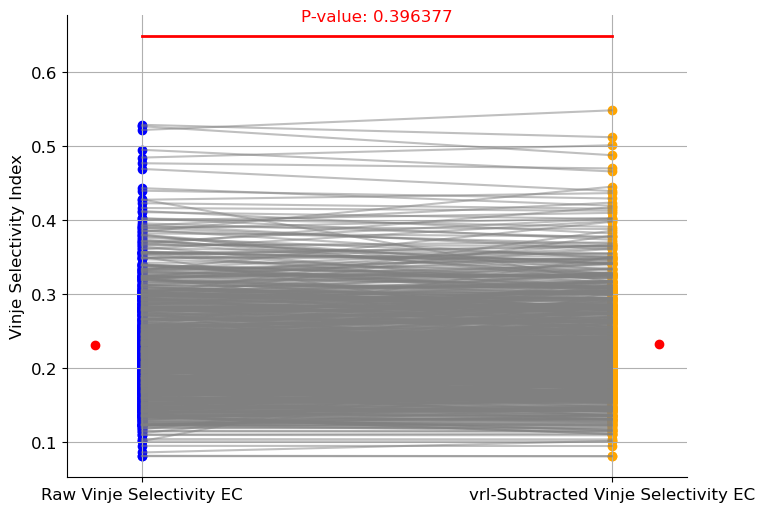

In [36]:

from scipy.stats import ttest_rel


t_stat, p_value_raw_velocity = ttest_rel(selectivity_EC_velocity, EC_raw_selectivity)
        
mean_raw = np.mean(EC_raw_selectivity)
mean_velocity = np.mean(selectivity_EC_velocity)

sem_raw = np.std(EC_raw_selectivity) / np.sqrt(len(EC_raw_selectivity))
sem_velocity = np.std(selectivity_EC_velocity) / np.sqrt(len(selectivity_EC_velocity))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity EC", "velocity-Subtracted Vinje Selectivity EC"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_velocity, yerr=sem_velocity, fmt='o', color='red'
)


for i in range(len(EC_raw_selectivity)):
    plt.plot(x_positions, [EC_raw_selectivity[i], selectivity_EC_velocity[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(EC_raw_selectivity), EC_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_EC_velocity), selectivity_EC_velocity, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(EC_raw_selectivity), max(selectivity_EC_velocity))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_velocity:.3f}", ha='center', color='red')





plt.show()

t_stat, p_value_raw_vl = ttest_rel(selectivity_EC_vl, EC_raw_selectivity)
        
mean_raw = np.mean(EC_raw_selectivity)
mean_vl = np.mean(selectivity_EC_vl)

sem_raw = np.std(EC_raw_selectivity) / np.sqrt(len(EC_raw_selectivity))
sem_vl = np.std(selectivity_EC_vl) / np.sqrt(len(selectivity_EC_vl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity EC", "vl-Subtracted Vinje Selectivity EC"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vl, yerr=sem_vl, fmt='o', color='red'
)


for i in range(len(EC_raw_selectivity)):
    plt.plot(x_positions, [EC_raw_selectivity[i], selectivity_EC_vl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(EC_raw_selectivity), EC_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_EC_vl), selectivity_EC_vl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(EC_raw_selectivity), max(selectivity_EC_vl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vl:.3f}", ha='center', color='red')




t_stat, p_value_raw_vr = ttest_rel(selectivity_EC_vr, EC_raw_selectivity)
        
mean_raw = np.mean(EC_raw_selectivity)
mean_vr = np.mean(selectivity_EC_vr)

sem_raw = np.std(EC_raw_selectivity) / np.sqrt(len(EC_raw_selectivity))
sem_vr = np.std(selectivity_EC_vr) / np.sqrt(len(selectivity_EC_vr))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity EC", "vr-Subtracted Vinje Selectivity EC"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vr, yerr=sem_vr, fmt='o', color='red'
)


for i in range(len(EC_raw_selectivity)):
    plt.plot(x_positions, [EC_raw_selectivity[i], selectivity_EC_vr[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(EC_raw_selectivity), EC_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_EC_vr), selectivity_EC_vr, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(EC_raw_selectivity), max(selectivity_EC_vr))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vr:.3f}", ha='center', color='red')



t_stat, p_value_raw_vrl = ttest_rel(selectivity_EC_vrl, EC_raw_selectivity)
        
mean_raw = np.mean(EC_raw_selectivity)
mean_vrl = np.mean(selectivity_EC_vrl)

sem_raw = np.std(EC_raw_selectivity) / np.sqrt(len(EC_raw_selectivity))
sem_vrl = np.std(selectivity_EC_vrl) / np.sqrt(len(selectivity_EC_vrl))

plt.figure(figsize=(8, 6))

# Scatter points
x_positions = [0.4, 0.6]
x_labels = ["Raw Vinje Selectivity EC", "vrl-Subtracted Vinje Selectivity EC"]

mean_offset = 0.02
plt.errorbar(
    x_positions[0] - mean_offset, mean_raw, yerr=sem_raw, fmt='o', color='red' 
)
plt.errorbar(
    x_positions[1] + mean_offset, mean_vrl, yerr=sem_vrl, fmt='o', color='red'
)


for i in range(len(EC_raw_selectivity)):
    plt.plot(x_positions, [EC_raw_selectivity[i], selectivity_EC_vrl[i]], color='gray', alpha=0.5)

plt.scatter([x_positions[0]] * len(EC_raw_selectivity), EC_raw_selectivity, color='blue', label="First Quintile Distance From Reward EC")
plt.scatter([x_positions[1]] * len(selectivity_EC_vrl), selectivity_EC_vrl, color='orange', label="Last Quintile Distance From Reward EC")

# Add labels and title
plt.xticks(x_positions, x_labels)
plt.ylabel('Vinje Selectivity Index')

# Display p-value with a red line
y_min = max(max(EC_raw_selectivity), max(selectivity_EC_vrl))
plt.plot([x_positions[0], x_positions[1]], [y_min + 0.1, y_min + 0.1], color='red', linewidth=2)
plt.grid()         
plt.text(0.5, y_min + 0.12, f"P-value: {p_value_raw_vrl:.6f}", ha='center', color='red')





plt.show()


In [103]:
datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "SSTindivsomata_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

trial_argmin_list_SST_first_quintile_raw = []
trial_argmin_list_SST_last_quintile_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        sst_quintiles = split_into_quintiles(neuron_activity)
        first_quintile = sst_quintiles[0]
        last_quintile = sst_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_first_quintile_raw.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_last_quintile_raw.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_SST_first_quintile_raw, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_SST_last_quintile_raw, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_SST_raw = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_SST_first_quintile_raw)
    min_loc_difference_learning_list_SST_raw.append(value)

y_min_SST_raw = np.min(min_loc_difference_learning_list_SST_raw)
y_max_SST_raw = np.max(min_loc_difference_learning_list_SST_raw)


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "NDNFindivsomata_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

trial_argmin_list_NDNF_first_quintile_raw = []
trial_argmin_list_NDNF_last_quintile_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        NDNF_quintiles = split_into_quintiles(neuron_activity)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_first_quintile_raw.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_last_quintile_raw.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_first_quintile_raw, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_last_quintile_raw, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_NDNF_raw = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_NDNF_first_quintile_raw)
    min_loc_difference_learning_list_NDNF_raw.append(value)

y_min_NDNF_raw = np.min(min_loc_difference_learning_list_NDNF_raw)
y_max_NDNF_raw = np.max(min_loc_difference_learning_list_NDNF_raw)


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "EC_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

trial_argmin_list_EC_first_quintile_raw = []
trial_argmin_list_EC_last_quintile_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        EC_quintiles = split_into_quintiles(neuron_activity)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_first_quintile_raw.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_last_quintile_raw.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_EC_first_quintile_raw, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_EC_last_quintile_raw, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_EC_raw = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_EC_first_quintile_raw)
    min_loc_difference_learning_list_EC_raw.append(value)

y_min_EC_raw = np.min(min_loc_difference_learning_list_EC_raw)
y_max_EC_raw = np.max(min_loc_difference_learning_list_EC_raw)

In [104]:
datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "SSTindivsomata_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

trial_argmax_list_SST_first_quintile_raw = []
trial_argmax_list_SST_last_quintile_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        SST_quintiles = split_into_quintiles(neuron_activity)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_first_quintile_raw.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_last_quintile_raw.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_SST_first_quintile_raw, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_SST_last_quintile_raw, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_SST_raw = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_SST_first_quintile_raw)
    peak_loc_difference_learning_list_SST_raw.append(value)

y_min_SST_raw = np.min(peak_loc_difference_learning_list_SST_raw)
y_max_SST_raw = np.max(peak_loc_difference_learning_list_SST_raw)


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "NDNFindivsomata_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

trial_argmax_list_NDNF_first_quintile_raw = []
trial_argmax_list_NDNF_last_quintile_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        NDNF_quintiles = split_into_quintiles(neuron_activity)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_first_quintile_raw.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_last_quintile_raw.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_first_quintile_raw, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_last_quintile_raw, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_NDNF_raw = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_NDNF_first_quintile_raw)
    peak_loc_difference_learning_list_NDNF_raw.append(value)

y_min_NDNF_raw = np.min(peak_loc_difference_learning_list_NDNF_raw)
y_max_NDNF_raw = np.max(peak_loc_difference_learning_list_NDNF_raw)

datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "EC_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data, variable_list = preprocess_data(filepath, normalize=True)

trial_argmax_list_EC_first_quintile_raw = []
trial_argmax_list_EC_last_quintile_raw = []

for animal, subdict in reorganized_data.items():
    for cell, value in subdict.items():
        neuron_data = reorganized_data[animal][cell]
#         print(f"neuron_data.shape {neuron_data.shape}")
        neuron_activity = neuron_data[:, 0, :]
        EC_quintiles = split_into_quintiles(neuron_activity)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_first_quintile_raw.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_last_quintile_raw.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_EC_first_quintile_raw, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_EC_last_quintile_raw, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_EC_raw = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_EC_first_quintile_raw)
    peak_loc_difference_learning_list_EC_raw.append(value)

y_min_EC_raw = np.min(peak_loc_difference_learning_list_EC_raw)
y_max_EC_raw = np.max(peak_loc_difference_learning_list_EC_raw)
        

In [97]:
#function to get quintiles 

trial_argmax_list_SST_first_quintile_velocity = []
trial_argmax_list_SST_last_quintile_velocity = []

for animal, subdict in residual_activity_velocity_SST.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_velocity_SST[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_first_quintile_velocity.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_last_quintile_velocity.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_SST_first_quintile_velocity, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_SST_last_quintile_velocity, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_SST_velocity = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_SST_first_quintile_velocity)
    peak_loc_difference_learning_list_SST_velocity.append(value)

y_min_SST_velocity = np.min(peak_loc_difference_learning_list_SST_velocity)
y_max_SST_velocity = np.max(peak_loc_difference_learning_list_SST_velocity)


trial_argmax_list_NDNF_first_quintile_velocity = []
trial_argmax_list_NDNF_last_quintile_velocity = []

for animal, subdict in residual_activity_velocity_NDNF.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_velocity_NDNF[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_first_quintile_velocity.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_last_quintile_velocity.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_first_quintile_velocity, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_last_quintile_velocity, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_NDNF_velocity = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_NDNF_first_quintile_velocity)
    peak_loc_difference_learning_list_NDNF_velocity.append(value)

y_min_NDNF_velocity = np.min(peak_loc_difference_learning_list_NDNF_velocity)
y_max_NDNF_velocity = np.max(peak_loc_difference_learning_list_NDNF_velocity)



trial_argmax_list_EC_first_quintile_velocity = []
trial_argmax_list_EC_last_quintile_velocity = []

for animal, subdict in residual_activity_velocity_EC.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_velocity_EC[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_first_quintile_velocity.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_last_quintile_velocity.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_EC_first_quintile_velocity, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_EC_last_quintile_velocity, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_EC_velocity = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_EC_first_quintile_velocity)
    peak_loc_difference_learning_list_EC_velocity.append(value)

y_min_EC_velocity = np.min(peak_loc_difference_learning_list_EC_velocity)
y_max_EC_velocity = np.max(peak_loc_difference_learning_list_EC_velocity)





In [105]:
trial_argmin_list_SST_first_quintile_velocity = []
trial_argmin_list_SST_last_quintile_velocity = []

for animal, subdict in residual_activity_velocity_SST.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_velocity_SST[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_first_quintile_velocity.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_last_quintile_velocity.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_SST_first_quintile_velocity, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_SST_last_quintile_velocity, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_SST_velocity = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_SST_first_quintile_velocity)
    min_loc_difference_learning_list_SST_velocity.append(value)

y_min_SST_velocity = np.min(min_loc_difference_learning_list_SST_velocity)
y_max_SST_velocity = np.max(min_loc_difference_learning_list_SST_velocity)


trial_argmin_list_NDNF_first_quintile_velocity = []
trial_argmin_list_NDNF_last_quintile_velocity = []

for animal, subdict in residual_activity_velocity_NDNF.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_velocity_NDNF[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_first_quintile_velocity.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_last_quintile_velocity.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_first_quintile_velocity, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_last_quintile_velocity, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_NDNF_velocity = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_NDNF_first_quintile_velocity)
    min_loc_difference_learning_list_NDNF_velocity.append(value)

y_min_NDNF_velocity = np.min(min_loc_difference_learning_list_NDNF_velocity)
y_max_NDNF_velocity = np.max(min_loc_difference_learning_list_NDNF_velocity)



trial_argmin_list_EC_first_quintile_velocity = []
trial_argmin_list_EC_last_quintile_velocity = []

for animal, subdict in residual_activity_velocity_EC.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_velocity_EC[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_first_quintile_velocity.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_last_quintile_velocity.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_EC_first_quintile_velocity, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_EC_last_quintile_velocity, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_EC_velocity = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_EC_first_quintile_velocity)
    min_loc_difference_learning_list_EC_velocity.append(value)

y_min_EC_velocity = np.min(min_loc_difference_learning_list_EC_velocity)
y_max_EC_velocity = np.max(min_loc_difference_learning_list_EC_velocity)





In [98]:
#function to get quintiles 

trial_argmax_list_SST_first_quintile_vl = []
trial_argmax_list_SST_last_quintile_vl = []

for animal, subdict in residual_activity_vl_SST.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vl_SST[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_first_quintile_vl.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_last_quintile_vl.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_SST_first_quintile_vl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_SST_last_quintile_vl, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_SST_vl = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_SST_first_quintile_vl)
    peak_loc_difference_learning_list_SST_vl.append(value)

y_min_SST_vl = np.min(peak_loc_difference_learning_list_SST_vl)
y_max_SST_vl = np.max(peak_loc_difference_learning_list_SST_vl)


trial_argmax_list_NDNF_first_quintile_vl = []
trial_argmax_list_NDNF_last_quintile_vl = []

for animal, subdict in residual_activity_vl_NDNF.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vl_NDNF[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_first_quintile_vl.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_last_quintile_vl.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_first_quintile_vl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_last_quintile_vl, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_NDNF_vl = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_NDNF_first_quintile_vl)
    peak_loc_difference_learning_list_NDNF_vl.append(value)

y_min_NDNF_vl = np.min(peak_loc_difference_learning_list_NDNF_vl)
y_max_NDNF_vl = np.max(peak_loc_difference_learning_list_NDNF_vl)



trial_argmax_list_EC_first_quintile_vl = []
trial_argmax_list_EC_last_quintile_vl = []

for animal, subdict in residual_activity_vl_EC.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vl_EC[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_first_quintile_vl.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_last_quintile_vl.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_EC_first_quintile_vl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_EC_last_quintile_vl, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_EC_vl = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_EC_first_quintile_vl)
    peak_loc_difference_learning_list_EC_vl.append(value)

y_min_EC_vl = np.min(peak_loc_difference_learning_list_EC_vl)
y_max_EC_vl = np.max(peak_loc_difference_learning_list_EC_vl)





In [106]:

trial_argmin_list_SST_first_quintile_vl = []
trial_argmin_list_SST_last_quintile_vl = []

for animal, subdict in residual_activity_vl_SST.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vl_SST[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_first_quintile_vl.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_last_quintile_vl.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_SST_first_quintile_vl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_SST_last_quintile_vl, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_SST_vl = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_SST_first_quintile_vl)
    min_loc_difference_learning_list_SST_vl.append(value)

y_min_SST_vl = np.min(min_loc_difference_learning_list_SST_vl)
y_max_SST_vl = np.max(min_loc_difference_learning_list_SST_vl)


trial_argmin_list_NDNF_first_quintile_vl = []
trial_argmin_list_NDNF_last_quintile_vl = []

for animal, subdict in residual_activity_vl_NDNF.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vl_NDNF[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_first_quintile_vl.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_last_quintile_vl.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_first_quintile_vl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_last_quintile_vl, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_NDNF_vl = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_NDNF_first_quintile_vl)
    min_loc_difference_learning_list_NDNF_vl.append(value)

y_min_NDNF_vl = np.min(min_loc_difference_learning_list_NDNF_vl)
y_max_NDNF_vl = np.max(min_loc_difference_learning_list_NDNF_vl)



trial_argmin_list_EC_first_quintile_vl = []
trial_argmin_list_EC_last_quintile_vl = []

for animal, subdict in residual_activity_vl_EC.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vl_EC[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_first_quintile_vl.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_last_quintile_vl.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_EC_first_quintile_vl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_EC_last_quintile_vl, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_EC_vl = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_EC_first_quintile_vl)
    min_loc_difference_learning_list_EC_vl.append(value)

y_min_EC_vl = np.min(min_loc_difference_learning_list_EC_vl)
y_max_EC_vl = np.max(min_loc_difference_learning_list_EC_vl)




In [99]:
#function to get quintiles 

trial_argmax_list_SST_first_quintile_vr = []
trial_argmax_list_SST_last_quintile_vr = []

for animal, subdict in residual_activity_vr_SST.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vr_SST[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_first_quintile_vr.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_last_quintile_vr.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_SST_first_quintile_vr, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_SST_last_quintile_vr, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_SST_vr = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_SST_first_quintile_vr)
    peak_loc_difference_learning_list_SST_vr.append(value)

y_min_SST_vr = np.min(peak_loc_difference_learning_list_SST_vr)
y_max_SST_vr = np.max(peak_loc_difference_learning_list_SST_vr)


trial_argmax_list_NDNF_first_quintile_vr = []
trial_argmax_list_NDNF_last_quintile_vr = []

for animal, subdict in residual_activity_vr_NDNF.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vr_NDNF[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_first_quintile_vr.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_last_quintile_vr.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_first_quintile_vr, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_last_quintile_vr, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_NDNF_vr = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_NDNF_first_quintile_vr)
    peak_loc_difference_learning_list_NDNF_vr.append(value)

y_min_NDNF_vr = np.min(peak_loc_difference_learning_list_NDNF_vr)
y_max_NDNF_vr = np.max(peak_loc_difference_learning_list_NDNF_vr)



trial_argmax_list_EC_first_quintile_vr = []
trial_argmax_list_EC_last_quintile_vr = []

for animal, subdict in residual_activity_vr_EC.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vr_EC[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_first_quintile_vr.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_last_quintile_vr.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_EC_first_quintile_vr, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_EC_last_quintile_vr, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_EC_vr = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_EC_first_quintile_vr)
    peak_loc_difference_learning_list_EC_vr.append(value)

y_min_EC_vr = np.min(peak_loc_difference_learning_list_EC_vr)
y_max_EC_vr = np.max(peak_loc_difference_learning_list_EC_vr)




In [109]:



trial_argmin_list_SST_first_quintile_vr = []
trial_argmin_list_SST_last_quintile_vr = []

for animal, subdict in residual_activity_vr_SST.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vr_SST[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_first_quintile_vr.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_last_quintile_vr.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_SST_first_quintile_vr, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_SST_last_quintile_vr, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_SST_vr = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_SST_first_quintile_vr)
    min_loc_difference_learning_list_SST_vr.append(value)

y_min_SST_vr = np.min(min_loc_difference_learning_list_SST_vr)
y_max_SST_vr = np.max(min_loc_difference_learning_list_SST_vr)


trial_argmin_list_NDNF_first_quintile_vr = []
trial_argmin_list_NDNF_last_quintile_vr = []

for animal, subdict in residual_activity_vr_NDNF.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vr_NDNF[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_first_quintile_vr.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_last_quintile_vr.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_first_quintile_vr, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_last_quintile_vr, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_NDNF_vr = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_NDNF_first_quintile_vr)
    min_loc_difference_learning_list_NDNF_vr.append(value)

y_min_NDNF_vr = np.min(min_loc_difference_learning_list_NDNF_vr)
y_max_NDNF_vr = np.max(min_loc_difference_learning_list_NDNF_vr)



trial_argmin_list_EC_first_quintile_vr = []
trial_argmin_list_EC_last_quintile_vr = []

for animal, subdict in residual_activity_vr_EC.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vr_EC[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_first_quintile_vr.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_last_quintile_vr.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_EC_first_quintile_vr, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_EC_last_quintile_vr, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_EC_vr = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_EC_first_quintile_vr)
    min_loc_difference_learning_list_EC_vr.append(value)

y_min_EC_vr = np.min(min_loc_difference_learning_list_EC_vr)
y_max_EC_vr = np.max(min_loc_difference_learning_list_EC_vr)



In [110]:
#function to get quintiles 

trial_argmax_list_SST_first_quintile_vrl = []
trial_argmax_list_SST_last_quintile_vrl = []

for animal, subdict in residual_activity_vrl_SST.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vrl_SST[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_first_quintile_vrl.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_SST_last_quintile_vrl.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_SST_first_quintile_vrl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_SST_last_quintile_vrl, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_SST_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_SST_first_quintile_vrl)
    peak_loc_difference_learning_list_SST_vrl.append(value)

y_min_SST_vrl = np.min(peak_loc_difference_learning_list_SST_vrl)
y_max_SST_vrl = np.max(peak_loc_difference_learning_list_SST_vrl)


trial_argmax_list_NDNF_first_quintile_vrl = []
trial_argmax_list_NDNF_last_quintile_vrl = []

for animal, subdict in residual_activity_vrl_NDNF.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vrl_NDNF[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_first_quintile_vrl.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_NDNF_last_quintile_vrl.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_first_quintile_vrl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_NDNF_last_quintile_vrl, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_NDNF_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_NDNF_first_quintile_vrl)
    peak_loc_difference_learning_list_NDNF_vrl.append(value)

y_min_NDNF_vrl = np.min(peak_loc_difference_learning_list_NDNF_vrl)
y_max_NDNF_vrl = np.max(peak_loc_difference_learning_list_NDNF_vrl)



trial_argmax_list_EC_first_quintile_vrl = []
trial_argmax_list_EC_last_quintile_vrl = []

for animal, subdict in residual_activity_vrl_EC.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vrl_EC[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmax_loc = np.mean(first_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_first_quintile_vrl.append(argmax_loc)
        argmax_loc = np.mean(last_quintile, axis=1)
        argmax_loc = np.argmax(argmax_loc)
        trial_argmax_list_EC_last_quintile_vrl.append(argmax_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmax_list_EC_first_quintile_vrl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmax_list_EC_last_quintile_vrl, bins=bin_edges)

peak_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

peak_loc_difference_learning_list_EC_vrl = []

for value in peak_loc_difference_learning:
    value = value / len(trial_argmax_list_EC_first_quintile_vrl)
    peak_loc_difference_learning_list_EC_vrl.append(value)

y_min_EC_vrl = np.min(peak_loc_difference_learning_list_EC_vrl)
y_max_EC_vrl = np.max(peak_loc_difference_learning_list_EC_vrl)






In [113]:


trial_argmin_list_SST_first_quintile_vrl = []
trial_argmin_list_SST_last_quintile_vrl = []

for animal, subdict in residual_activity_vrl_SST.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vrl_SST[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = SST_quintiles[0]
        last_quintile = SST_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_first_quintile_vrl.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_SST_last_quintile_vrl.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_SST_first_quintile_vrl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_SST_last_quintile_vrl, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_SST_vrl = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_SST_first_quintile_vrl)
    min_loc_difference_learning_list_SST_vrl.append(value)

y_min_SST_vrl = np.min(min_loc_difference_learning_list_SST_vrl)
y_max_SST_vrl = np.max(min_loc_difference_learning_list_SST_vrl)


trial_argmin_list_NDNF_first_quintile_vrl = []
trial_argmin_list_NDNF_last_quintile_vrl = []

for animal, subdict in residual_activity_vrl_NDNF.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vrl_NDNF[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = NDNF_quintiles[0]
        last_quintile = NDNF_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_first_quintile_vrl.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_NDNF_last_quintile_vrl.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_first_quintile_vrl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_NDNF_last_quintile_vrl, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_NDNF_vrl = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_NDNF_first_quintile_vrl)
    min_loc_difference_learning_list_NDNF_vrl.append(value)

y_min_NDNF_vrl = np.min(min_loc_difference_learning_list_NDNF_vrl)
y_max_NDNF_vrl = np.max(min_loc_difference_learning_list_NDNF_vrl)



trial_argmin_list_EC_first_quintile_vrl = []
trial_argmin_list_EC_last_quintile_vrl = []

for animal, subdict in residual_activity_vrl_EC.items():
    for cell, value in subdict.items():
        
        residual_data = residual_activity_vrl_EC[animal][cell]
        quintiles = split_into_quintiles(residual_data)
        first_quintile = EC_quintiles[0]
        last_quintile = EC_quintiles[-1]
        argmin_loc = np.mean(first_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_first_quintile_vrl.append(argmin_loc)
        argmin_loc = np.mean(last_quintile, axis=1)
        argmin_loc = np.argmin(argmin_loc)
        trial_argmin_list_EC_last_quintile_vrl.append(argmin_loc)
        
        
first_quintile_hist, _ = np.histogram(trial_argmin_list_EC_first_quintile_vrl, bins=bin_edges)
last_quintile_hist, _ = np.histogram(trial_argmin_list_EC_last_quintile_vrl, bins=bin_edges)

min_loc_difference_learning = (last_quintile_hist - first_quintile_hist)

min_loc_difference_learning_list_EC_vrl = []

for value in min_loc_difference_learning:
    value = value / len(trial_argmin_list_EC_first_quintile_vrl)
    min_loc_difference_learning_list_EC_vrl.append(value)

y_min_EC_vrl = np.min(min_loc_difference_learning_list_EC_vrl)
y_max_EC_vrl = np.max(min_loc_difference_learning_list_EC_vrl)


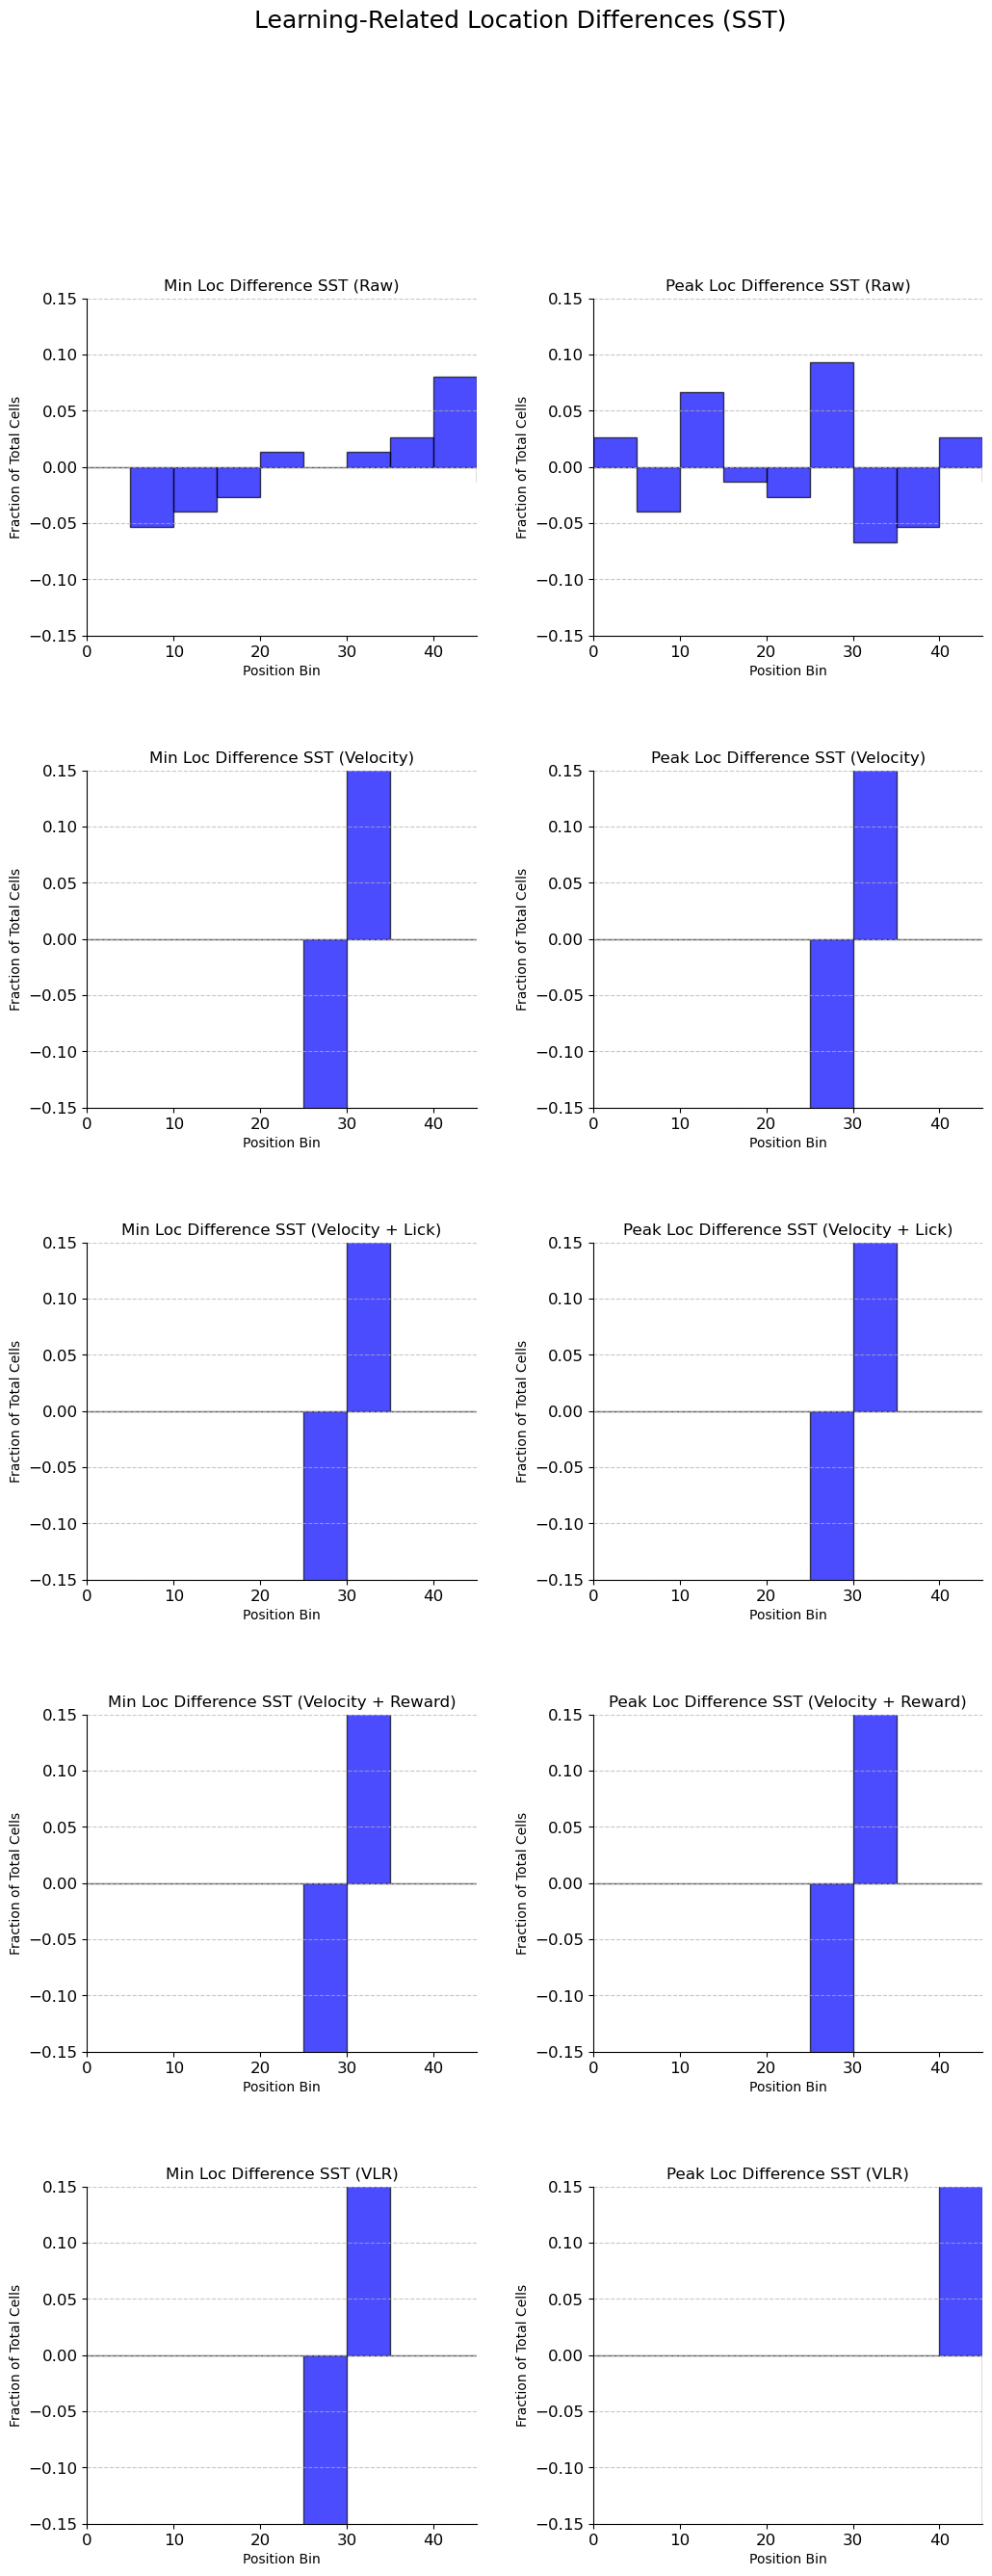

In [115]:
import matplotlib.pyplot as plt

# Define parameters
bin_edges = np.arange(0, 51, 5)
bin_centers = bin_edges[:-1] + 2.5

# Data and titles
datasets = [
    min_loc_difference_learning_list_SST_raw, peak_loc_difference_learning_list_SST_raw,
    min_loc_difference_learning_list_SST_velocity, peak_loc_difference_learning_list_SST_velocity,
    min_loc_difference_learning_list_SST_vl, peak_loc_difference_learning_list_SST_vl,
    min_loc_difference_learning_list_SST_vr, peak_loc_difference_learning_list_SST_vr,
    min_loc_difference_learning_list_SST_vrl, peak_loc_difference_learning_list_SST_vrl
]

titles = [
    "Min Loc Difference SST (Raw)", "Peak Loc Difference SST (Raw)",
    "Min Loc Difference SST (Velocity)", "Peak Loc Difference SST (Velocity)",
    "Min Loc Difference SST (Velocity + Lick)", "Peak Loc Difference SST (Velocity + Lick)",
    "Min Loc Difference SST (Velocity + Reward)", "Peak Loc Difference SST (Velocity + Reward)",
    "Min Loc Difference SST (VLR)", "Peak Loc Difference SST (VLR)"
]

# Create subplots
fig, axs = plt.subplots(5, 2, figsize=(12, 30))

# Adjust spacing
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot each dataset
for ax, data, title in zip(axs.flat, datasets, titles):
    ax.bar(bin_centers, data, width=5, align='center', edgecolor='k', color='blue', alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Position Bin", fontsize=10)
    ax.set_ylabel("Fraction of Total Cells", fontsize=10)
    ax.set_ylim(-0.15, 0.15)
    ax.set_xlim(0, 45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Global title
fig.suptitle("Learning-Related Location Differences (SST)", fontsize=18)

# Show plot
plt.show()


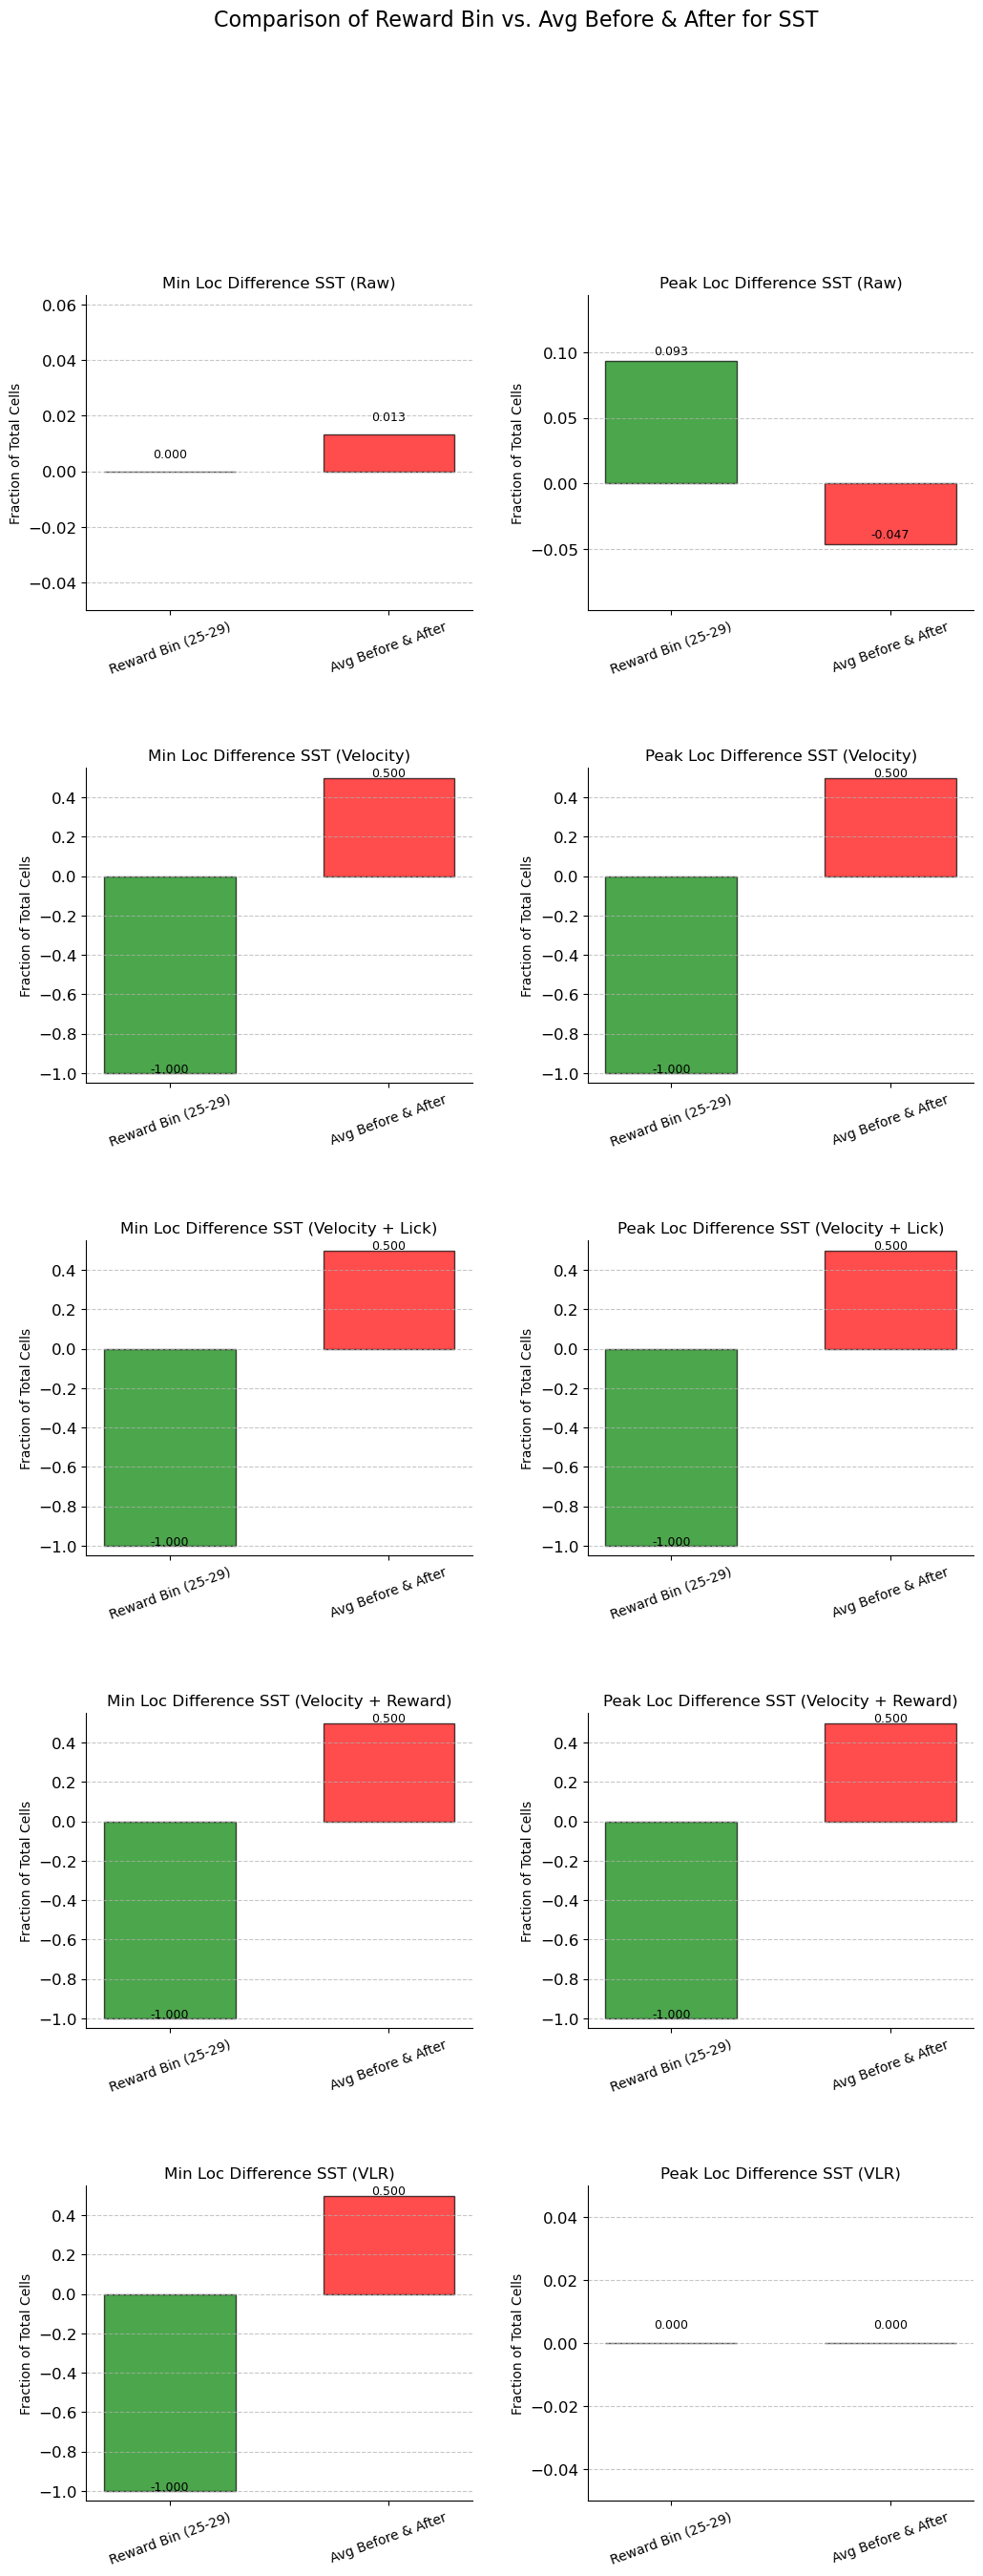

In [117]:
# Define specific bin indices for comparison
specific_bin_index = 5  # Bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34

# Titles and datasets
titles = [
    "Min Loc Difference SST (Raw)", "Peak Loc Difference SST (Raw)",
    "Min Loc Difference SST (Velocity)", "Peak Loc Difference SST (Velocity)",
    "Min Loc Difference SST (Velocity + Lick)", "Peak Loc Difference SST (Velocity + Lick)",
    "Min Loc Difference SST (Velocity + Reward)", "Peak Loc Difference SST (Velocity + Reward)",
    "Min Loc Difference SST (VLR)", "Peak Loc Difference SST (VLR)"
]

datasets = [
    min_loc_difference_learning_list_SST_raw, peak_loc_difference_learning_list_SST_raw,
    min_loc_difference_learning_list_SST_velocity, peak_loc_difference_learning_list_SST_velocity,
    min_loc_difference_learning_list_SST_vl, peak_loc_difference_learning_list_SST_vl,
    min_loc_difference_learning_list_SST_vr, peak_loc_difference_learning_list_SST_vr,
    min_loc_difference_learning_list_SST_vrl, peak_loc_difference_learning_list_SST_vrl
]

# Prepare for plotting
fig, axs = plt.subplots(5, 2, figsize=(12, 30))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Iterate over datasets to compute and plot the fractions
for ax, title, data in zip(axs.flat, titles, datasets):
    # Compute fractions
    specific_bin_fraction = data[specific_bin_index]
    before_after_bins_fraction = np.mean([data[before_bin_index], data[after_bin_index]])

    # Bar chart values
    x_positions = [0, 1]
    y_values = [specific_bin_fraction, before_after_bins_fraction]
    x_labels = ["Reward Bin (25-29)", "Avg Before & After"]

    # Plot bars
    ax.bar(x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7)
    
    # Add values on top of bars
    for i, val in enumerate(y_values):
        ax.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=9, color="black")

    # Customize plot
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Fraction of Total Cells", fontsize=10)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=10, rotation=20)
    ax.set_ylim(min(y_values) - 0.05, max(y_values) + 0.05)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

# Global title
fig.suptitle("Comparison of Reward Bin vs. Avg Before & After for SST", fontsize=16)

# Display plot
plt.show()


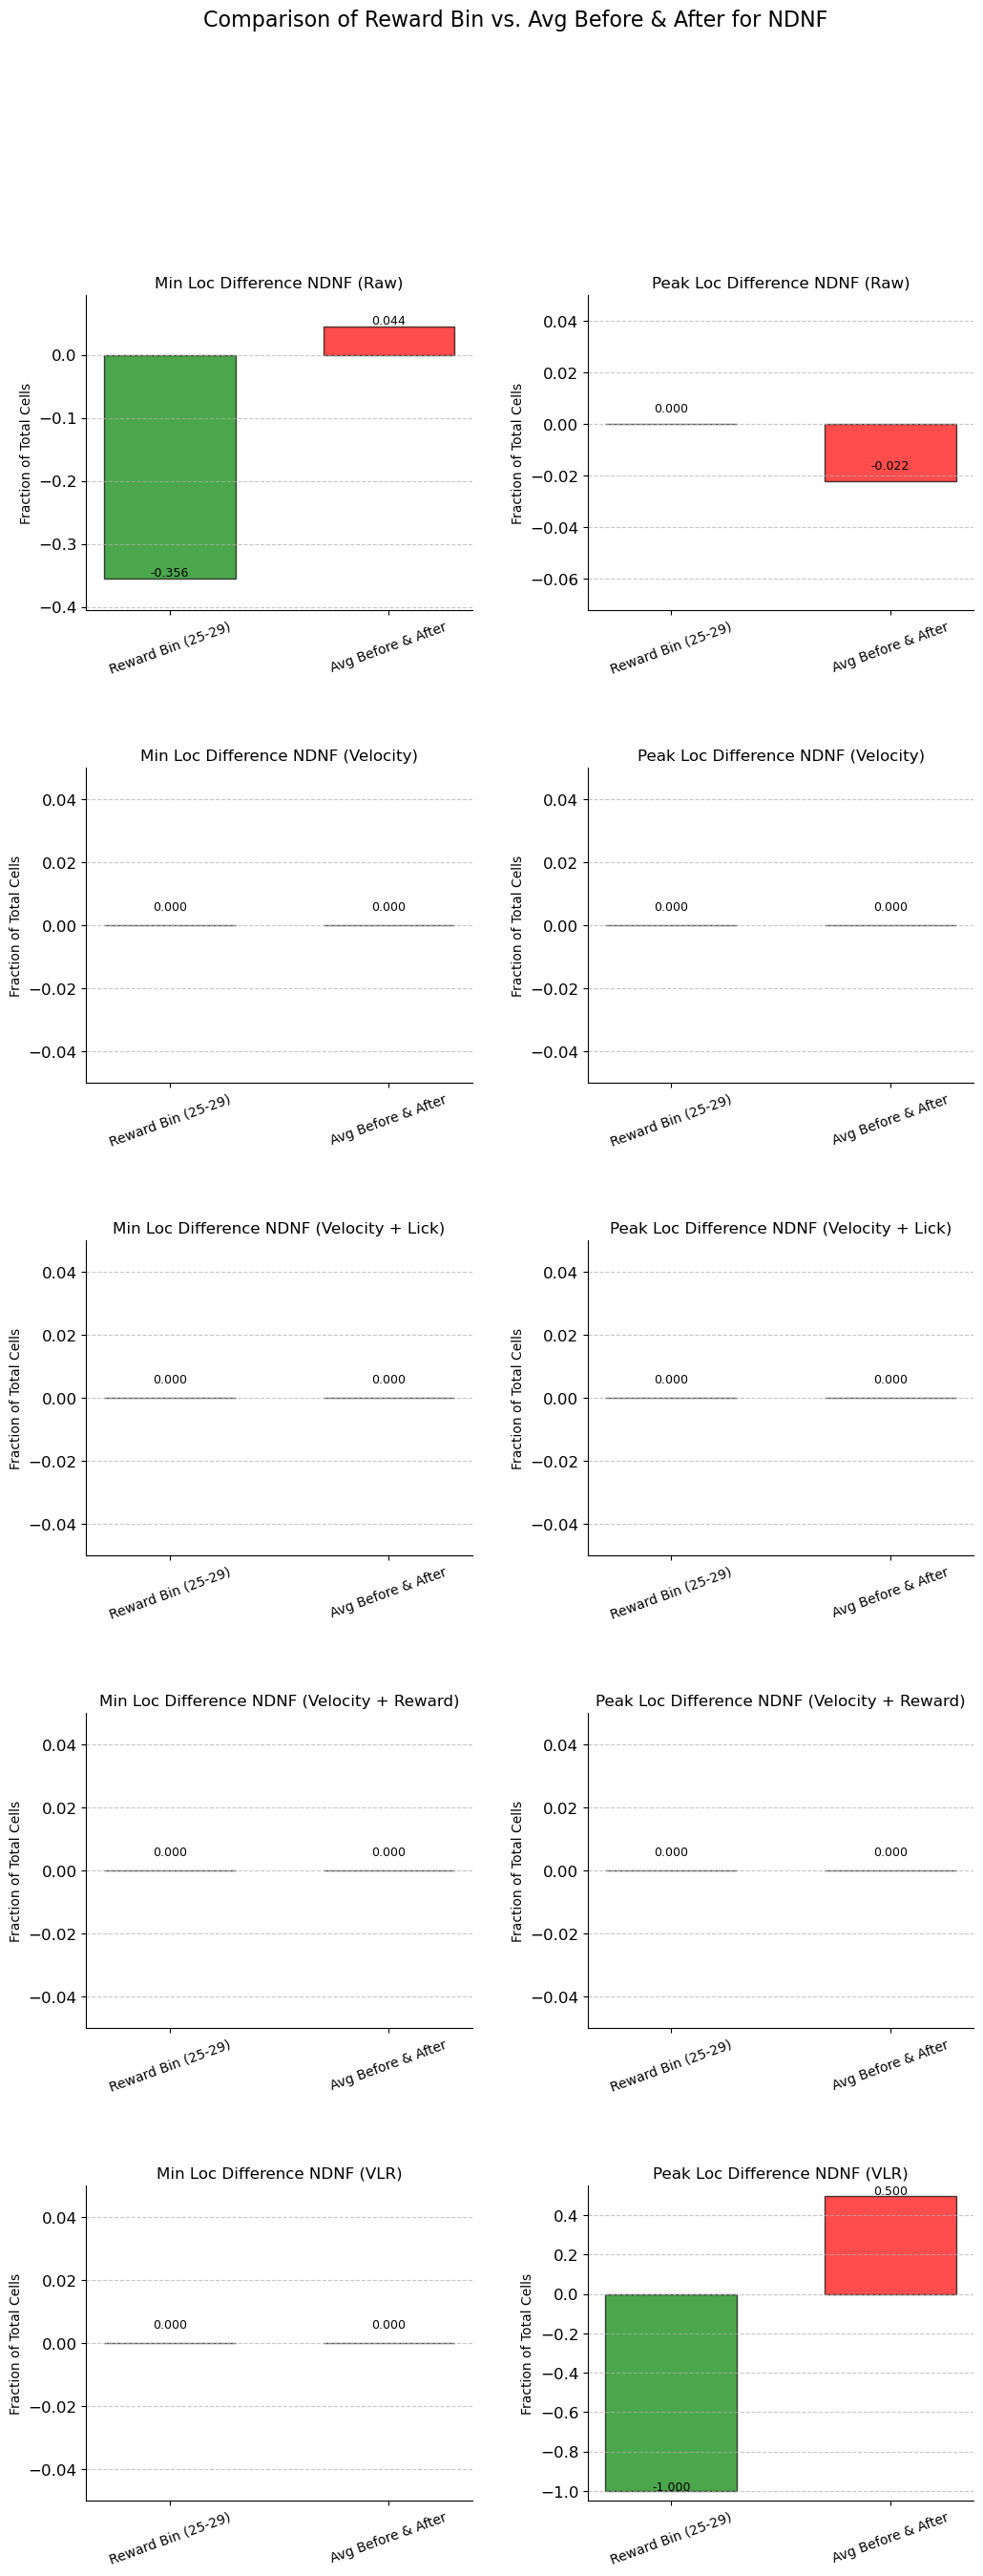

In [118]:
# Define specific bin indices for comparison
specific_bin_index = 5  # Bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34

# Titles and datasets
titles = [
    "Min Loc Difference NDNF (Raw)", "Peak Loc Difference NDNF (Raw)",
    "Min Loc Difference NDNF (Velocity)", "Peak Loc Difference NDNF (Velocity)",
    "Min Loc Difference NDNF (Velocity + Lick)", "Peak Loc Difference NDNF (Velocity + Lick)",
    "Min Loc Difference NDNF (Velocity + Reward)", "Peak Loc Difference NDNF (Velocity + Reward)",
    "Min Loc Difference NDNF (VLR)", "Peak Loc Difference NDNF (VLR)"
]

datasets = [
    min_loc_difference_learning_list_NDNF_raw, peak_loc_difference_learning_list_NDNF_raw,
    min_loc_difference_learning_list_NDNF_velocity, peak_loc_difference_learning_list_NDNF_velocity,
    min_loc_difference_learning_list_NDNF_vl, peak_loc_difference_learning_list_NDNF_vl,
    min_loc_difference_learning_list_NDNF_vr, peak_loc_difference_learning_list_NDNF_vr,
    min_loc_difference_learning_list_NDNF_vrl, peak_loc_difference_learning_list_NDNF_vrl
]

# Prepare for plotting
fig, axs = plt.subplots(5, 2, figsize=(12, 30))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Iterate over datasets to compute and plot the fractions
for ax, title, data in zip(axs.flat, titles, datasets):
    # Compute fractions
    specific_bin_fraction = data[specific_bin_index]
    before_after_bins_fraction = np.mean([data[before_bin_index], data[after_bin_index]])

    # Bar chart values
    x_positions = [0, 1]
    y_values = [specific_bin_fraction, before_after_bins_fraction]
    x_labels = ["Reward Bin (25-29)", "Avg Before & After"]

    # Plot bars
    ax.bar(x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7)
    
    # Add values on top of bars
    for i, val in enumerate(y_values):
        ax.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=9, color="black")

    # Customize plot
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Fraction of Total Cells", fontsize=10)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=10, rotation=20)
    ax.set_ylim(min(y_values) - 0.05, max(y_values) + 0.05)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

# Global title
fig.suptitle("Comparison of Reward Bin vs. Avg Before & After for NDNF", fontsize=16)

# Display plot
plt.show()


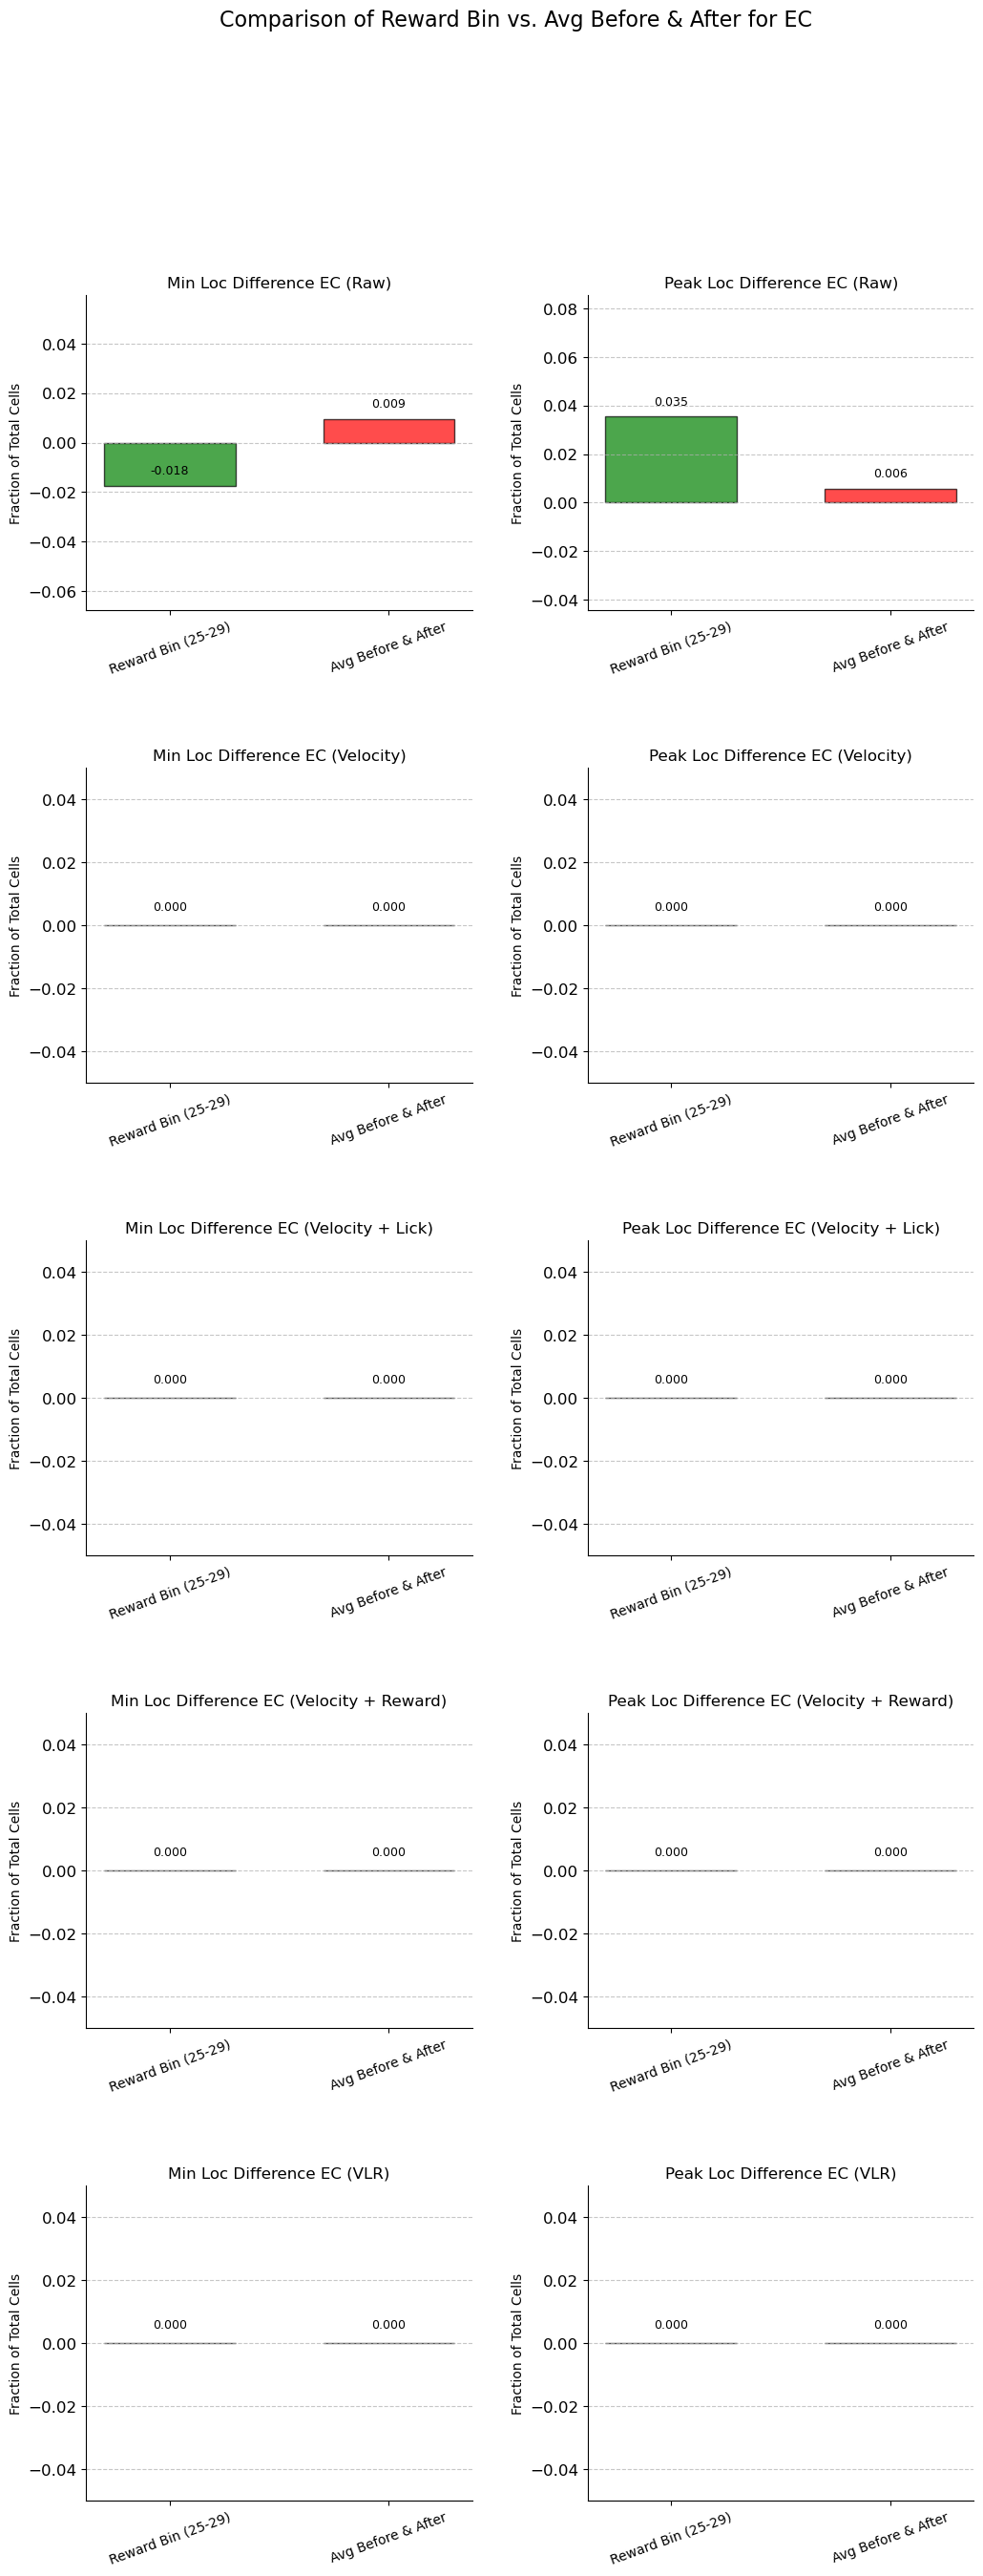

In [119]:
# Define specific bin indices for comparison
specific_bin_index = 5  # Bin 25-29
before_bin_index = specific_bin_index - 1  # Bin 20-24
after_bin_index = specific_bin_index + 1  # Bin 30-34

# Titles and datasets
titles = [
    "Min Loc Difference EC (Raw)", "Peak Loc Difference EC (Raw)",
    "Min Loc Difference EC (Velocity)", "Peak Loc Difference EC (Velocity)",
    "Min Loc Difference EC (Velocity + Lick)", "Peak Loc Difference EC (Velocity + Lick)",
    "Min Loc Difference EC (Velocity + Reward)", "Peak Loc Difference EC (Velocity + Reward)",
    "Min Loc Difference EC (VLR)", "Peak Loc Difference EC (VLR)"
]

datasets = [
    min_loc_difference_learning_list_EC_raw, peak_loc_difference_learning_list_EC_raw,
    min_loc_difference_learning_list_EC_velocity, peak_loc_difference_learning_list_EC_velocity,
    min_loc_difference_learning_list_EC_vl, peak_loc_difference_learning_list_EC_vl,
    min_loc_difference_learning_list_EC_vr, peak_loc_difference_learning_list_EC_vr,
    min_loc_difference_learning_list_EC_vrl, peak_loc_difference_learning_list_EC_vrl
]

# Prepare for plotting
fig, axs = plt.subplots(5, 2, figsize=(12, 30))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Iterate over datasets to compute and plot the fractions
for ax, title, data in zip(axs.flat, titles, datasets):
    # Compute fractions
    specific_bin_fraction = data[specific_bin_index]
    before_after_bins_fraction = np.mean([data[before_bin_index], data[after_bin_index]])

    # Bar chart values
    x_positions = [0, 1]
    y_values = [specific_bin_fraction, before_after_bins_fraction]
    x_labels = ["Reward Bin (25-29)", "Avg Before & After"]

    # Plot bars
    ax.bar(x_positions, y_values, width=0.6, color=["green", "red"], edgecolor="k", alpha=0.7)
    
    # Add values on top of bars
    for i, val in enumerate(y_values):
        ax.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=9, color="black")

    # Customize plot
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Fraction of Total Cells", fontsize=10)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=10, rotation=20)
    ax.set_ylim(min(y_values) - 0.05, max(y_values) + 0.05)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

# Global title
fig.suptitle("Comparison of Reward Bin vs. Avg Before & After for EC", fontsize=16)

# Display plot
plt.show()
